# Rate Design Distributional Impact Analysis
**Technology-specific bill changes across PG&E, SCE, and SDG&E**

This notebook computes how different rate reform scenarios affect household bills, broken down by:
- Technology profile (Base, PV+Storage, EV, PV+Stor+EV)
- CARE vs Non-CARE status
- Utility (IOU)
- Climate zone (PG&E only)

Minimum bill floors are applied consistently to both status quo and volumetric-only reform scenarios.

## Setup & Configuration

In [209]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# ── Font & style ──
matplotlib.rcParams.update({
    'font.family': 'Helvetica',  # falls back to Arial/sans-serif,
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
# Fallback if Helvetica not available
try:
    matplotlib.font_manager.findfont('Helvetica', fallback_to_default=False)
except:
    matplotlib.rcParams['font.family'] = 'Arial'
    print('Helvetica not found, using Arial')


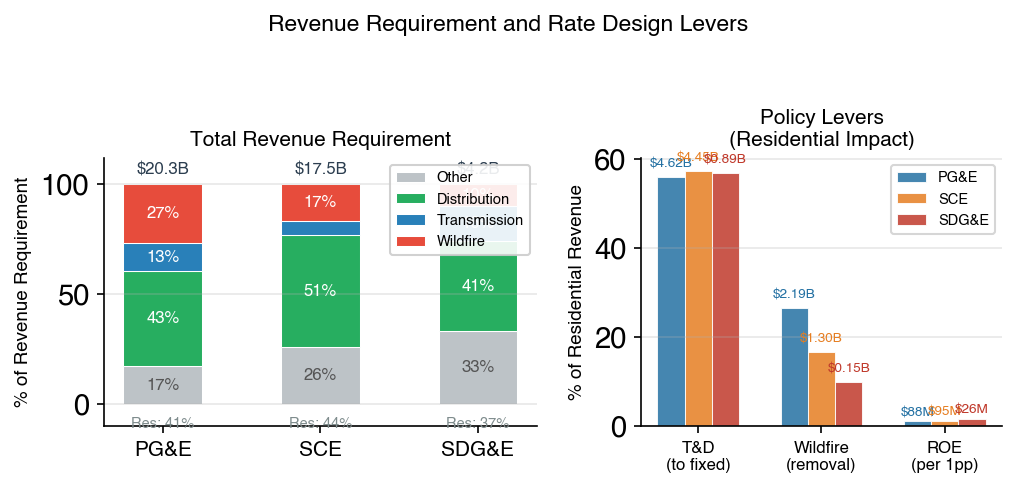

In [210]:
import numpy as np
import matplotlib.pyplot as plt

# Data from utility_data_inputs.tex
utils = ['PG&E', 'SCE', 'SDG&E']

total_rev_req = [20.34, 17.53, 4.23]  # $B
res_rev = [8.24, 7.75, 1.56]  # $B
res_share = [r/t for r, t in zip(res_rev, total_rev_req)]

dist_B = [8.74, 8.94, 1.72]
trans_B = [2.66, 1.12, 0.685]
wf_B = [5.40, 2.93, 0.414]
other_B = [t - d - tr - w for t, d, tr, w in zip(total_rev_req, dist_B, trans_B, wf_B)]

# As % of total rev req
dist_pct = [d/t*100 for d, t in zip(dist_B, total_rev_req)]
trans_pct = [tr/t*100 for tr, t in zip(trans_B, total_rev_req)]
wf_pct = [w/t*100 for w, t in zip(wf_B, total_rev_req)]
other_pct = [o/t*100 for o, t in zip(other_B, total_rev_req)]

# Residential lever impacts
td_res_B = [(d+tr)*rs for d, tr, rs in zip(dist_B, trans_B, res_share)]
wf_res_B = [w*rs for w, rs in zip(wf_B, res_share)]
roe_res_B = [41.99*0.52*0.01*res_share[0], 41.43*0.52*0.01*res_share[1], 13.59*0.52*0.01*res_share[2]]

td_res_pct = [v/r*100 for v, r in zip(td_res_B, res_rev)]
wf_res_pct = [v/r*100 for v, r in zip(wf_res_B, res_rev)]
roe_res_pct = [v/r*100 for v, r in zip(roe_res_B, res_rev)]

# Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.0, 3.2),
                                gridspec_kw={'width_ratios': [1.2, 1]})

colors = {'Other': '#bdc3c7', 'Distribution': '#27ae60',
          'Transmission': '#2980b9', 'Wildfire': '#e74c3c'}

x = np.arange(3)
w = 0.5
bottom = np.zeros(3)
for comp, vals in [('Other', other_pct), ('Distribution', dist_pct),
                   ('Transmission', trans_pct), ('Wildfire', wf_pct)]:
    bars = ax1.bar(x, vals, bottom=bottom, width=w, color=colors[comp],
                   label=comp, edgecolor='white', linewidth=0.5)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 7:
            ax1.text(j, b + v/2, f'{v:.0f}%', ha='center', va='center',
                     fontsize=8, fontweight='bold', color='white' if comp != 'Other' else '#555')
    bottom += vals

# Annotate total $ and residential share
for j in range(3):
    ax1.text(j, 103, f'${total_rev_req[j]:.1f}B', ha='center', va='bottom',
             fontsize=8, fontweight='bold', color='#2c3e50')
    ax1.text(j, -6, f'Res: {res_share[j]*100:.0f}%', ha='center', va='top',
             fontsize=7, color='#7f8c8d')

ax1.set_xticks(x)
ax1.set_xticklabels(utils, fontsize=10, fontweight='bold')
ax1.set_ylim(-10, 112)
ax1.set_ylabel('% of Revenue Requirement', fontsize=9)
ax1.legend(fontsize=7, loc='upper right', framealpha=0.9)
ax1.set_title('Total Revenue Requirement', fontsize=10, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.grid(axis='x', visible=False)

# Panel 2: Residential lever impacts
levers = ['T&D\n(to fixed)', 'Wildfire\n(removal)', 'ROE\n(per 1pp)']
lever_pcts = [td_res_pct, wf_res_pct, roe_res_pct]
lever_dollars = [td_res_B, wf_res_B, roe_res_B]

x2 = np.arange(3)
bw = 0.22
uc = ['#2471a3', '#e67e22', '#c0392b']

for i, (u, c) in enumerate(zip(utils, uc)):
    vals = [lp[i] for lp in lever_pcts]
    dollars = [ld[i] for ld in lever_dollars]
    bars = ax2.bar(x2 + (i-1)*bw, vals, width=bw, color=c, alpha=0.85,
                   label=u, edgecolor='white', linewidth=0.5)
    for j, (val, dol) in enumerate(zip(vals, dollars)):
        if val > 3:
            ax2.text(x2[j] + (i-1)*bw, val + 1.5, f'${dol:.2f}B',
                     ha='center', va='bottom', fontsize=6.5, fontweight='bold', color=c)
        else:
            ax2.text(x2[j] + (i-1)*bw, val + 0.5, f'${dol*1000:.0f}M',
                     ha='center', va='bottom', fontsize=6.5, fontweight='bold', color=c)

ax2.set_xticks(x2)
ax2.set_xticklabels(levers, fontsize=8)
ax2.set_ylabel('% of Residential Revenue', fontsize=9)
ax2.legend(fontsize=7, loc='upper right')
ax2.set_title('Policy Levers\n(Residential Impact)', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.grid(axis='x', visible=False)

fig.suptitle('Revenue Requirement and Rate Design Levers',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('fig1_rate_design_inputs.pdf', bbox_inches='tight', dpi=300)
plt.show()

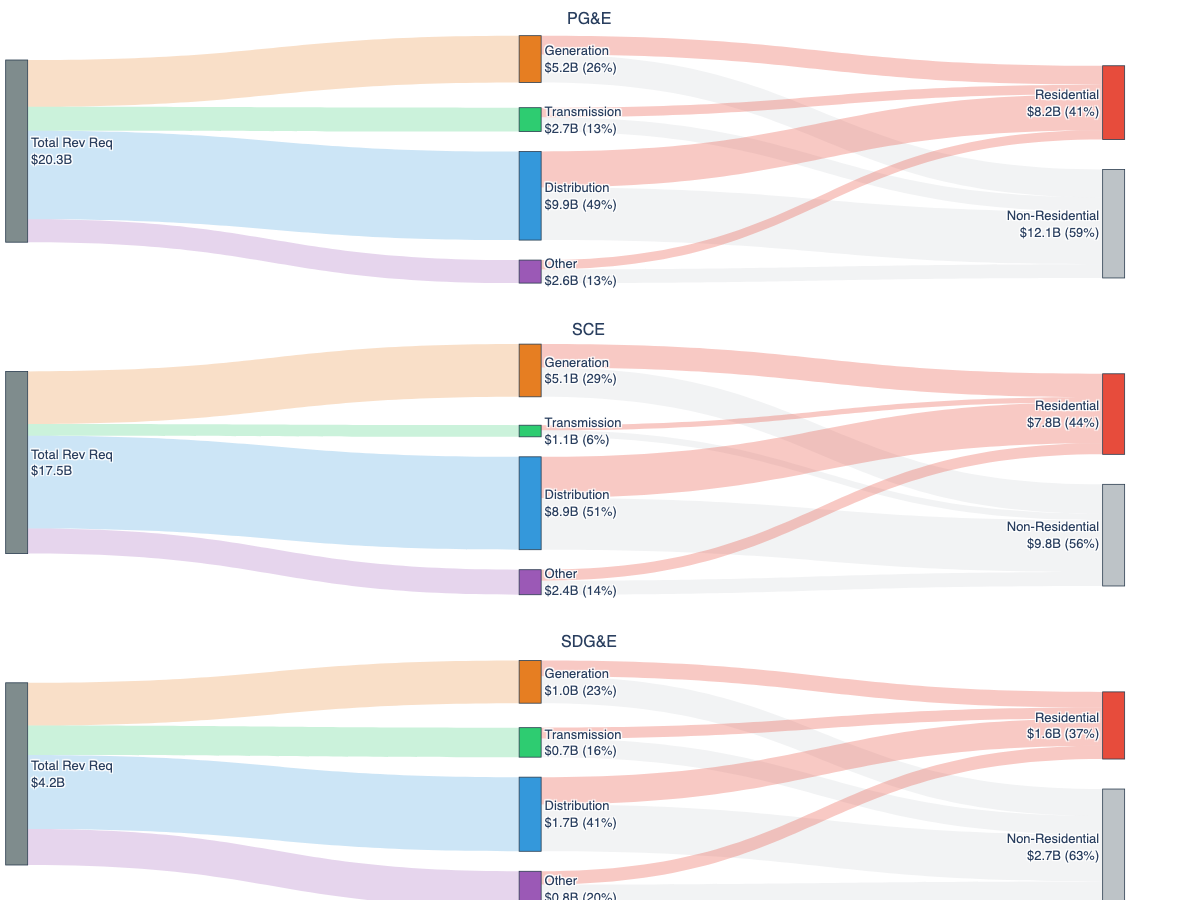

In [211]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Revenue requirements ($000) from your table
data = {
    'PG&E':  {'Gen': 5223556, 'Trans': 2663244, 'Dist': 9884656,
              'Other': 20341236 - 5223556 - 2663244 - 9884656,
              'Total': 20341236, 'Res': 8240000},  # ← update Res
    'SCE':   {'Gen': 5069512, 'Trans': 1116093, 'Dist': 8937477,
              'Other': 17530066 - 5069512 - 1116093 - 8937477,
              'Total': 17530066, 'Res': 7750000},   # ← update Res
    'SDG&E': {'Gen': 991446,  'Trans': 685245,  'Dist': 1722187,
              'Other': 4233072 - 991446 - 685245 - 1722187,
              'Total': 4233072,  'Res': 1560000},    # ← update Res
}

cats = ['Gen', 'Trans', 'Dist', 'Other']
cat_labels = ['Generation', 'Transmission', 'Distribution', 'Other']
cat_colors = ['#e67e22', '#2ecc71', '#3498db', '#9b59b6']
cat_link_alphas = ['0.25', '0.25', '0.25', '0.25']

fig = make_subplots(rows=3, cols=1, specs=[[{"type": "sankey"}]]*3,
                    subplot_titles=list(data.keys()), vertical_spacing=0.08)

for i, (name, d) in enumerate(data.items()):
    rs = d['Res'] / d['Total']
    nonres = d['Total'] - d['Res']

    labels = [f"Total Rev Req<br>${d['Total']/1e6:.1f}B"]
    labels += [f"{cl}<br>${d[c]/1e6:.1f}B ({d[c]/d['Total']*100:.0f}%)"
               for c, cl in zip(cats, cat_labels)]
    labels += [f"Residential<br>${d['Res']/1e6:.1f}B ({rs*100:.0f}%)",
               f"Non-Residential<br>${nonres/1e6:.1f}B ({(1-rs)*100:.0f}%)"]

    node_colors = ['#7f8c8d'] + cat_colors + ['#e74c3c', '#bdc3c7']

    # Links: Total→cats, then each cat→Res/NonRes
    source = [0,0,0,0] + [j for j in range(1,5) for _ in range(2)]
    target = [1,2,3,4] + [5,6]*4
    value = [d[c] for c in cats] + \
            [v for c in cats for v in (d[c]*rs, d[c]*(1-rs))]
    link_colors = [f'rgba({",".join(str(int(cat_colors[j].lstrip("#")[k:k+2],16)) for k in (0,2,4))},0.25)'
                   for j in range(4)] + \
                  [f'rgba(231,76,60,0.3)' if t==5 else 'rgba(189,195,199,0.2)'
                   for _ in range(4) for t in (5,6)]

    fig.add_trace(go.Sankey(
        arrangement='snap',
        node=dict(pad=20, thickness=22, line=dict(color='#2c3e50', width=0.8),
                  label=labels, color=node_colors,
                  x=[0.01, 0.45,0.45,0.45,0.45, 0.95,0.95],
                  y=[0.5,  0.12,0.37,0.62,0.87, 0.30,0.80]),
        link=dict(source=source, target=target, value=value, color=link_colors),
    ), row=i+1, col=1)

for ann in fig['layout']['annotations']:
    ann['font'] = dict(size=16, family='Helvetica')

fig.update_layout(font=dict(size=13, family='Helvetica'),
                  width=550, height=900,
                  margin=dict(l=5, r=5, t=30, b=5), paper_bgcolor='white')
fig.show()

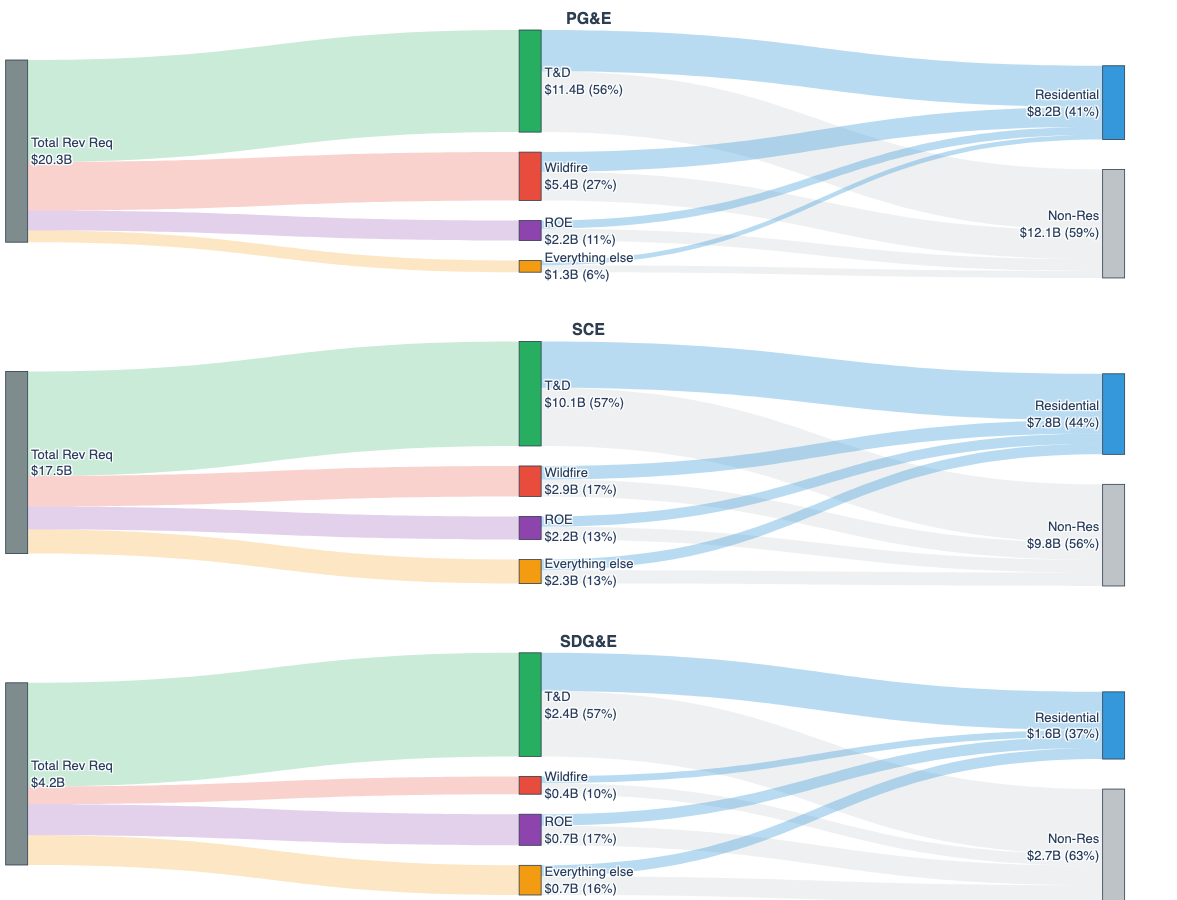

In [212]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

utils_list = [
    ('PG&E', 20.34, 8.24, 8.74, 2.66, 5.40, 41.99),
    ('SCE', 17.53, 7.75, 8.94, 1.12, 2.93, 41.43),
    ('SDG&E', 4.23, 1.56, 1.72, 0.685, 0.414, 13.59),
]

fig = make_subplots(
    rows=3, cols=1,
    specs=[[{"type": "sankey"}], [{"type": "sankey"}], [{"type": "sankey"}]],
    subplot_titles=[u[0] for u in utils_list],
    vertical_spacing=0.08,
)

for i, (name, total, res, dist, trans, wf, rb) in enumerate(utils_list):
    rs = res / total
    nonres = total - res
    td = dist + trans
    roe_equity = rb * 0.52 * (0.1028 if name == 'PG&E' else (0.1033 if name == 'SCE' else 0.1022))
    other = total - td - wf - roe_equity

    labels = [
        f"Total Rev Req<br>${total:.1f}B",
        f"T&D<br>${td:.1f}B ({td/total*100:.0f}%)",
        f"Wildfire<br>${wf:.1f}B ({wf/total*100:.0f}%)",
        f"ROE<br>${roe_equity:.1f}B ({roe_equity/total*100:.0f}%)",
        f"Everything else<br>${other:.1f}B ({other/total*100:.0f}%)",
        f"Residential<br>${res:.1f}B ({rs*100:.0f}%)",
        f"Non-Res<br>${nonres:.1f}B ({(1-rs)*100:.0f}%)",
    ]
    node_colors = ['#7f8c8d', '#27ae60', '#e74c3c', '#8e44ad', '#f39c12',
                   '#3498db', '#bdc3c7']
    source = [0, 0, 0, 0,  1, 1,  2, 2,  3, 3,  4, 4]
    target = [1, 2, 3, 4,  5, 6,  5, 6,  5, 6,  5, 6]
    value = [
        td, wf, roe_equity, other,
        td*rs, td*(1-rs),
        wf*rs, wf*(1-rs),
        roe_equity*rs, roe_equity*(1-rs),
        other*rs, other*(1-rs),
    ]
    link_colors = [
        'rgba(39,174,96,0.25)', 'rgba(231,76,60,0.25)',
        'rgba(142,68,173,0.25)', 'rgba(243,156,18,0.25)',
        'rgba(52,152,219,0.35)', 'rgba(189,195,199,0.25)',
        'rgba(52,152,219,0.35)', 'rgba(189,195,199,0.25)',
        'rgba(52,152,219,0.35)', 'rgba(189,195,199,0.25)',
        'rgba(52,152,219,0.35)', 'rgba(189,195,199,0.25)',
    ]

    fig.add_trace(
        go.Sankey(
            arrangement='snap',
            node=dict(
                pad=20,
                thickness=22,
                line=dict(color='#2c3e50', width=0.8),
                label=labels,
                color=node_colors,
                x=[0.01, 0.45, 0.45, 0.45, 0.45, 0.95, 0.95],
                y=[0.5,  0.15, 0.40, 0.65, 0.88, 0.30, 0.80],
            ),
            link=dict(
                source=source, target=target,
                value=value, color=link_colors,
            ),
        ),
        row=i+1, col=1,
    )

# Style subplot titles
for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=16, family='Helvetica', color='#2c3e50')
    annotation['font']['weight'] = 'bold' if hasattr(annotation['font'], 'weight') else None

fig.update_layout(
    font=dict(size=13, family='Helvetica'),
    width=550,
    height=900,
    margin=dict(l=5, r=5, t=30, b=5),
    paper_bgcolor='white',
)
fig.show()

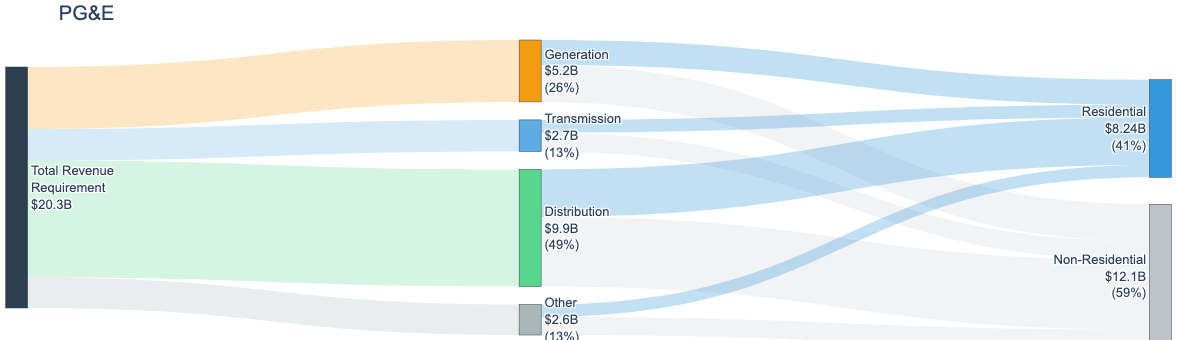

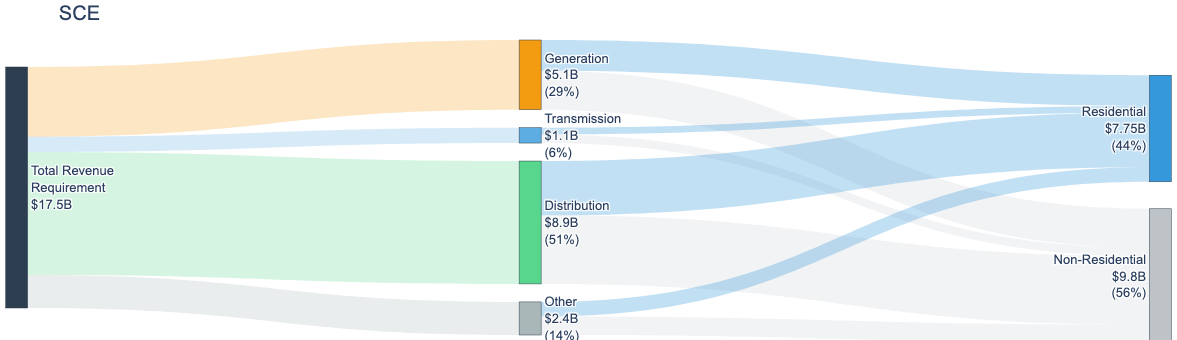

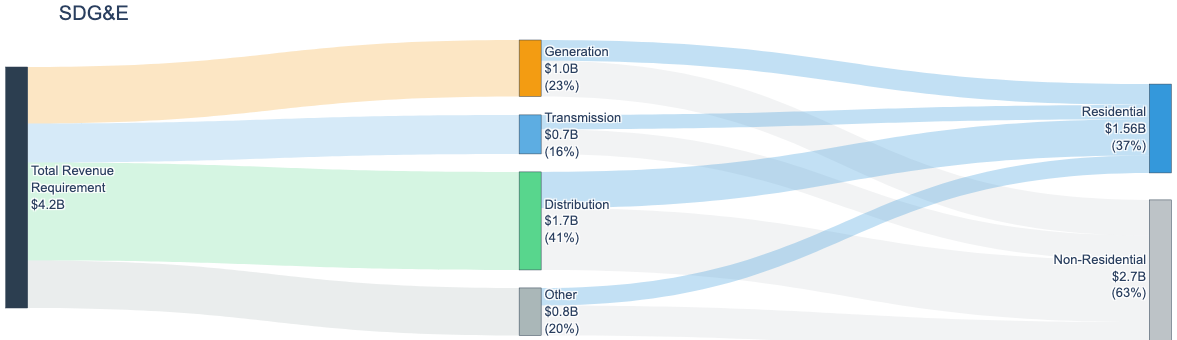

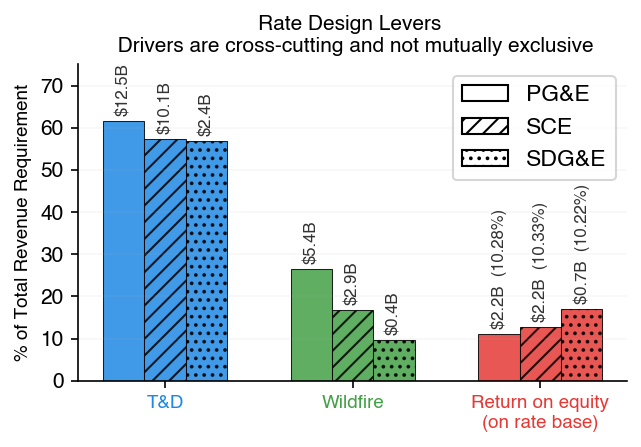

In [213]:
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt

# =============================================================
# Consistent color scheme
# =============================================================
COLORS = {
    # Rate scenarios
    'Reference TOU': '#333333',
    'Ref + Fixed': '#888888',
    'Baseline': '#AAAAAA',
    'ROE': '#E53935',
    'Wildfire': '#43A047',
    'Fixed Charge': '#1E88E5',
    # Revenue components
    'Generation': '#f39c12',
    'Transmission': '#1E88E5',     # blue (matches T&D/fixed charge driver)
    'Distribution': '#43A047',     # green (matches wildfire driver... hmm)
    'Other': '#95a5a6',
    # Customer classes
    'Residential': '#3498db',
    'Non-Residential': '#bdc3c7',
}

# Actually, the component colors shouldn't conflict with driver colors.
# Keep components neutral, use driver colors only in bar chart.
COLORS_COMP = {
    'Generation': '#f39c12',
    'Transmission': '#5dade2',
    'Distribution': '#58d68d',
    'Other': '#aab7b8',
}

COLORS_DRIVER = {
    'T&D': '#1E88E5',
    'Wildfire': '#43A047',
    'ROE': '#E53935',
}

COLORS_UTIL = {
    'PG&E': '#333333',
    'SCE': '#666666',
    'SDG&E': '#999999',
}

HATCHES_UTIL = {'PG&E': '', 'SCE': '///', 'SDG&E': '...'}

# =============================================================
# Data ($B)
# =============================================================

data = {
    'PG&E': {
        'Generation': 5.224, 'Transmission': 2.663, 'Distribution': 9.885,
        'Other': 20.341 - 5.224 - 2.663 - 9.885,
        'Total': 20.341, 'Res_Rev': 8.24,
    },
    'SCE': {
        'Generation': 5.070, 'Transmission': 1.116, 'Distribution': 8.937,
        'Other': 17.530 - 5.070 - 1.116 - 8.937,
        'Total': 17.530, 'Res_Rev': 7.75,
    },
    'SDG&E': {
        'Generation': 0.991, 'Transmission': 0.685, 'Distribution': 1.722,
        'Other': 4.233 - 0.991 - 0.685 - 1.722,
        'Total': 4.233, 'Res_Rev': 1.56,
    },
}

#Residential revenue (\$B)       & 8.24   & 7.75   & 1.56   \\

# =============================================================
# Three Sankey diagrams
# Total RR → Components → Residential / Non-Residential
# =============================================================

for util, d in data.items():
    total = d['Total']
    res = d['Res_Rev']
    nonres = total - res
    rs = res / total

    comps = ['Generation', 'Transmission', 'Distribution', 'Other']
    vals = [d[c] for c in comps]

    labels = [
        f"Total Revenue<br>Requirement<br>${total:.1f}B",
        f"Generation<br>${d['Generation']:.1f}B<br>({d['Generation']/total*100:.0f}%)",
        f"Transmission<br>${d['Transmission']:.1f}B<br>({d['Transmission']/total*100:.0f}%)",
        f"Distribution<br>${d['Distribution']:.1f}B<br>({d['Distribution']/total*100:.0f}%)",
        f"Other<br>${d['Other']:.1f}B<br>({d['Other']/total*100:.0f}%)",
        f"Residential<br>${res:.2f}B<br>({rs*100:.0f}%)",
        f"Non-Residential<br>${nonres:.1f}B<br>({(1-rs)*100:.0f}%)",
    ]

    node_colors = (['#2c3e50'] +
                   [COLORS_COMP[c] for c in comps] +
                   [COLORS['Residential'], COLORS['Non-Residential']])

    source, target, value, link_colors = [], [], [], []

    for i, (c, v) in enumerate(zip(comps, vals)):
        r, g, b = tuple(int(COLORS_COMP[c].lstrip('#')[j:j+2], 16) for j in (0, 2, 4))
        source.append(0); target.append(i + 1); value.append(v)
        link_colors.append(f'rgba({r},{g},{b},0.25)')

    for i, (c, v) in enumerate(zip(comps, vals)):
        source.append(i + 1); target.append(5); value.append(v * rs)
        link_colors.append('rgba(52,152,219,0.3)')
        source.append(i + 1); target.append(6); value.append(v * (1 - rs))
        link_colors.append('rgba(189,195,199,0.2)')

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=18, thickness=22,
            line=dict(color='#2c3e50', width=0.5),
            label=labels, color=node_colors,
            x=[0.01, 0.45, 0.45, 0.45, 0.45, 0.99, 0.99],
            y=[0.5,  0.08, 0.32, 0.58, 0.88, 0.30, 0.80],
        ),
        link=dict(source=source, target=target, value=value, color=link_colors),
    )])

    fig.update_layout(
        title=dict(text=f"{util}", font=dict(size=20, family='Arial')),
        font=dict(size=13, family='Arial'),
        width=600, height=340,
        margin=dict(l=5, r=5, t=40, b=5),
        paper_bgcolor='white',
    )
    fig.show()


# =============================================================
# Drivers bar chart with consistent driver + utility colors
# =============================================================

utils = ['PG&E', 'SCE', 'SDG&E']
totals = [data[u]['Total'] for u in utils]

td = [data[u]['Transmission'] + data[u]['Distribution'] for u in utils]
td_pct = [t/tot*100 for t, tot in zip(td, totals)]

wf = [5.404, 2.930, 0.4128]
wf_pct = [w/t*100 for w, t in zip(wf, totals)]

roe = [41.988*0.52*0.1028, 41.428*0.52*0.1033, 13.591*0.52*0.1022]
roe_pct = [r/t*100 for r, t in zip(roe, totals)]

fig_bar, ax = plt.subplots(figsize=(4.5, 3.2))

x = np.arange(3)
bw = 0.22
for i, u in enumerate(utils):
    vals = [td_pct[i], wf_pct[i], roe_pct[i]]
    dollars = [td[i], wf[i], roe[i]]
    bars = ax.bar(x + (i-1)*bw, vals, width=bw,
                  color=[COLORS_DRIVER['T&D'], COLORS_DRIVER['Wildfire'], COLORS_DRIVER['ROE']],
                  alpha=0.85,
                  edgecolor='black', linewidth=0.5,
                  hatch=HATCHES_UTIL[u])
    
    roe_pcts_auth = {'PG&E': 10.28, 'SCE': 10.33, 'SDG&E': 10.22}
    
    for j, (val, dol) in enumerate(zip(vals, dollars)):
        if j == 2:  # ROE bar: show dollar value + authorized ROE %
            label = f'${dol:.1f}B  ({roe_pcts_auth[u]}%)'
        else:
            label = f'${dol:.1f}B'
        ax.text(x[j] + (i-1)*bw, val + 1.2, label,
                ha='center', va='bottom', rotation = 90,fontsize=8, fontweight='bold', color='#333')


# Custom legend for utilities using hatches
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor='white', 
                        edgecolor='black', 
                        hatch=HATCHES_UTIL[u], 
                        label=u)
                  for u in utils]
ax.legend(handles=legend_handles, fontsize=11, loc='upper right')

driver_labels = ['T&D', 'Wildfire', 'Return on equity\n(on rate base)']
ax.set_xticks(x)
ax.set_xticklabels(driver_labels, fontsize=9)
for tick, driver in zip(ax.get_xticklabels(), ['T&D', 'Wildfire', 'ROE']):
    tick.set_color(COLORS_DRIVER[driver])
    tick.set_fontweight('bold')

ax.set_ylabel('% of Total Revenue Requirement', fontsize=9)
ax.set_title('Rate Design Levers \n Drivers are cross-cutting and not mutually exclusive', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.1)
ax.grid(axis='x', visible=False)
ax.set_ylim(0, 75)
ax.set_yticks(np.arange(0, 80, 10))
ax.set_yticklabels(np.arange(0, 80, 10), fontsize = 10)


# fig_bar.text(0.5, -0.04,
#              'Drivers are cross-cutting and not mutually exclusive.',
#              ha='center', fontsize=7, color='#7f8c8d', style='italic')

plt.tight_layout()
#plt.savefig('fig_drivers.pdf', bbox_inches='tight', dpi=300)
plt.show()


## 2. Load Data

In [116]:
# ── Utility configs ──
configs = {
    'PG&E':  {'file': 'post_adoption_bills_pge.csv',
              'sq': 'e_tou_c_bill', 'sqf': 'e_tou_c_f_bill',
              's3_sfx': '_s3_pv_stor_ev', 'min_bill': 147.0,
              'rates_file': 'rate_scenarios_pge_fresh.csv'},
    'SCE':   {'file': 'post_adoption_bills_sce.csv',
              'sq': 'tou_d_4_9_bill', 'sqf': 'tou_d_4_9_f_bill',
              's3_sfx': '_s3_pv_ev_stor', 'min_bill': 126.0,
              'rates_file': 'rate_scenarios_sce_fresh.csv'},
    'SDG&E': {'file': 'post_adoption_bills_sdge.csv',
              'sq': 'tou_dr_bill', 'sqf': 'tou_dr_f_bill',
              's3_sfx': '_s3_pv_stor_ev', 'min_bill': 147.0,
              'rates_file': 'rate_scenarios_sdge_fresh.csv'},
}

# Load bill data
dfs = {}
for iou, cfg in configs.items():
    df = pd.read_csv(cfg['file'])
    df['care_group'] = df['is_care'].map({True: 'CARE', False: 'Non-CARE'})
    df['utility'] = iou
    dfs[iou] = df
    print(f'{iou}: {len(df):,} households')

# Load rate scenario files
rate_scenarios = {}
for iou, cfg in configs.items():
    rate_scenarios[iou] = pd.read_csv(cfg['rates_file'])


PG&E: 22,722 households
SCE: 19,863 households
SDG&E: 4,317 households


## 3. Minimum Bill Floor Logic

| Scenario | Has fixed charges? | Apply min bill? | Rationale |
|---|---|---|---|
| F0_WF0_ROE0 (Baseline) | No | **Yes** | Matches actual volumetric tariff |
| F0_WF0_ROE1.0 (ROE) | No | **Yes** | Same structure, lower rates |
| F0_WF1_ROE0 (Wildfire) | No | **Yes** | Same structure, lower rates |
| F50_WF0_ROE0 (50% Fixed) | Yes | No | Fixed charge replaces min bill |
| F50_WF1_ROE1.0 (Combined) | Yes | No | Same |
| Current Fixed Charge (-F) | Yes | No | Same |

**Min bill values:** PG&E = \$147/yr, SCE = \$126/yr, SDG&E = \$147/yr

The floor is applied to **both** the status quo TOU bill and the new volumetric-only bills.

## Plotting the rates

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.legend_handler import HandlerTuple

# ── Load current rates from Excel (weekday rows) ──
def load_current_rates(xlsx_path):
    df = pd.read_excel(xlsx_path, sheet_name='retail_rates_oct32025')
    df = df[df.weekday == 'weekday'].dropna(subset=['rate_type'])
    return df.set_index('rate_type')

curr_pge  = load_current_rates('retail_rates_data_PGE.xlsx')
curr_sce  = load_current_rates('retail_rates_data_SCE.xlsx')
curr_sdge = load_current_rates('retail_rates_data_SDGE.xlsx')

# ── Load rate design scenarios ──
rates_pge  = pd.read_csv('rate_scenarios_pge_fresh.csv').set_index('Scenario')
rates_sce  = pd.read_csv('rate_scenarios_sce_fresh.csv').set_index('Scenario')
rates_sdge = pd.read_csv('rate_scenarios_sdge_fresh.csv').set_index('Scenario')

# ── Build unified rate table per IOU ──
# Columns: Fixed_CARE, Fixed_NonCARE, summer_peak, summer_offpeak,
#           winter_peak, winter_offpeak, care_discount
# care_discount from Excel; for rate design scenarios, use same as base TOU

design_scenarios = ['F0_WF0_ROE0', 'F0_WF0_ROE1.0', 'F0_WF1_ROE0',
                    'F50_WF0_ROE0', 'F50_WF1_ROE1.0']

def build_rate_table(curr_df, rates_df, tou_name, touf_name, vol_cols):
    tou  = curr_df.loc[tou_name]
    touf = curr_df.loc[touf_name]
    care_disc_tou  = abs(tou['care_discount'])
    care_disc_touf = abs(touf['care_discount'])

    rows = {}
    # Current TOU (no fixed charge)
    rows[tou_name] = {
        'Fixed_CARE': 0, 'Fixed_NonCARE': 0,
        'care_discount': care_disc_tou,
    }
    for vc in vol_cols:
        rows[tou_name][vc] = tou[f'{vc}1']  # peak_rate_summer1 -> summer_peak etc

    # Current TOU-F (with fixed charge)
    rows[touf_name] = {
        'Fixed_CARE': touf['fixedcharge_low'],
        'Fixed_NonCARE': touf['fixedcharge_med'],
        'care_discount': care_disc_touf,
    }
    for vc in vol_cols:
        rows[touf_name][vc] = touf[f'{vc}1']

    # Rate design scenarios (use base TOU care discount)
    for scen in design_scenarios:
        if scen not in rates_df.index:
            continue
        row = {'Fixed_CARE': rates_df.loc[scen, 'Fixed_CARE'],
               'Fixed_NonCARE': rates_df.loc[scen, 'Fixed_NonCARE'],
               'care_discount': care_disc_tou}
        for vc in vol_cols:
            # Map vol_cols name to rates_df column name
            rc = vc.replace('peak_rate_summer', 'summer_peak') \
                   .replace('peak_rate_winter', 'winter_peak') \
                   .replace('midpeak_rate_summer', 'summer_midpeak') \
                   .replace('midpeak_rate_winter', 'winter_midpeak') \
                   .replace('offpeak_rate_summer', 'summer_offpeak') \
                   .replace('offpeak_rate_winter', 'winter_offpeak')
            if rc in rates_df.columns:
                row[vc] = rates_df.loc[scen, rc]
            else:
                row[vc] = np.nan
        rows[scen] = row

    return pd.DataFrame(rows).T

# Column mapping: Excel uses peak_rate_summer1, rates CSV uses summer_peak
# Let's standardize to the rates CSV naming

def build_table_simple(curr_df, rates_df, tou_name, touf_name, rate_cols):
    """rate_cols: list of rates CSV column names like 'summer_peak' """
    tou  = curr_df.loc[tou_name]
    touf = curr_df.loc[touf_name]
    care_disc_tou  = abs(tou['care_discount'])
    care_disc_touf = abs(touf['care_discount'])

    # Map rates CSV names to Excel column names
    col_map = {
        'summer_peak': 'peak_rate_summer1',
        'summer_offpeak': 'offpeak_rate_summer1',
        'summer_midpeak': 'midpeak_rate_summer1',
        'winter_peak': 'peak_rate_winter1',
        'winter_offpeak': 'offpeak_rate_winter1',
        'winter_midpeak': 'midpeak_rate_winter1',
    }

    rows = {}
    # Current TOU
    r = {'Fixed_CARE': 0, 'Fixed_NonCARE': 0, 'care_discount': care_disc_tou}
    for rc in rate_cols:
        r[rc] = tou[col_map[rc]] if col_map[rc] in tou.index else np.nan
    rows[tou_name] = r

    # Current TOU-F
    r = {'Fixed_CARE': touf['fixedcharge_low'], 'Fixed_NonCARE': touf['fixedcharge_med'],
         'care_discount': care_disc_touf}
    for rc in rate_cols:
        r[rc] = touf[col_map[rc]] if col_map[rc] in touf.index else np.nan
    rows[touf_name] = r

    # Rate design scenarios
    for scen in design_scenarios:
        if scen not in rates_df.index: continue
        r = {'Fixed_CARE': rates_df.loc[scen, 'Fixed_CARE'],
             'Fixed_NonCARE': rates_df.loc[scen, 'Fixed_NonCARE'],
             'care_discount': care_disc_tou}
        for rc in rate_cols:
            r[rc] = rates_df.loc[scen, rc] if rc in rates_df.columns else np.nan
        rows[scen] = r

    return pd.DataFrame(rows).T

pge_cols  = ['summer_peak', 'summer_offpeak', 'winter_peak', 'winter_offpeak']
sce_cols  = ['summer_peak', 'summer_offpeak', 'winter_peak', 'winter_midpeak', 'winter_offpeak']
sdge_cols = ['summer_peak', 'summer_midpeak', 'summer_offpeak', 'winter_peak', 'winter_midpeak', 'winter_offpeak']

rt_pge  = build_table_simple(curr_pge,  rates_pge,  'E-TOU-C',   'E-TOU-C-F',   pge_cols)
rt_sce  = build_table_simple(curr_sce,  rates_sce,  'TOU-D-4-9', 'TOU-D-4-9-F', sce_cols)
rt_sdge = build_table_simple(curr_sdge, rates_sdge, 'TOU-DR',    'TOU-DR-F',     sdge_cols)

print('PGE:'); print(rt_pge.to_string())
print('\nSCE:'); print(rt_sce.to_string())
print('\nSDGE:'); print(rt_sdge.to_string())

PGE:
                Fixed_CARE  Fixed_NonCARE  care_discount  summer_peak  summer_offpeak  winter_peak  winter_offpeak
E-TOU-C            0.00000        0.00000           0.35      0.58943         0.46643      0.46460         0.43460
E-TOU-C-F          6.11072       24.59633           0.35      0.52240         0.39940      0.39757         0.36757
F0_WF0_ROE0        0.00000        0.00000           0.35      0.58940         0.46640      0.46460         0.43460
F0_WF0_ROE1.0      0.00000        0.00000           0.35      0.58360         0.46180      0.46000         0.43030
F0_WF1_ROE0        0.00000        0.00000           0.35      0.44610         0.35300      0.35170         0.32900
F50_WF0_ROE0      21.95440       88.52570           0.35      0.43820         0.34680      0.34540         0.32310
F50_WF1_ROE1.0     8.84300       35.65730           0.35      0.37950         0.30030      0.29910         0.27980

SCE:
                Fixed_CARE  Fixed_NonCARE  care_discount  summer_peak

IndexError: index 3 is out of bounds for axis 1 with size 3

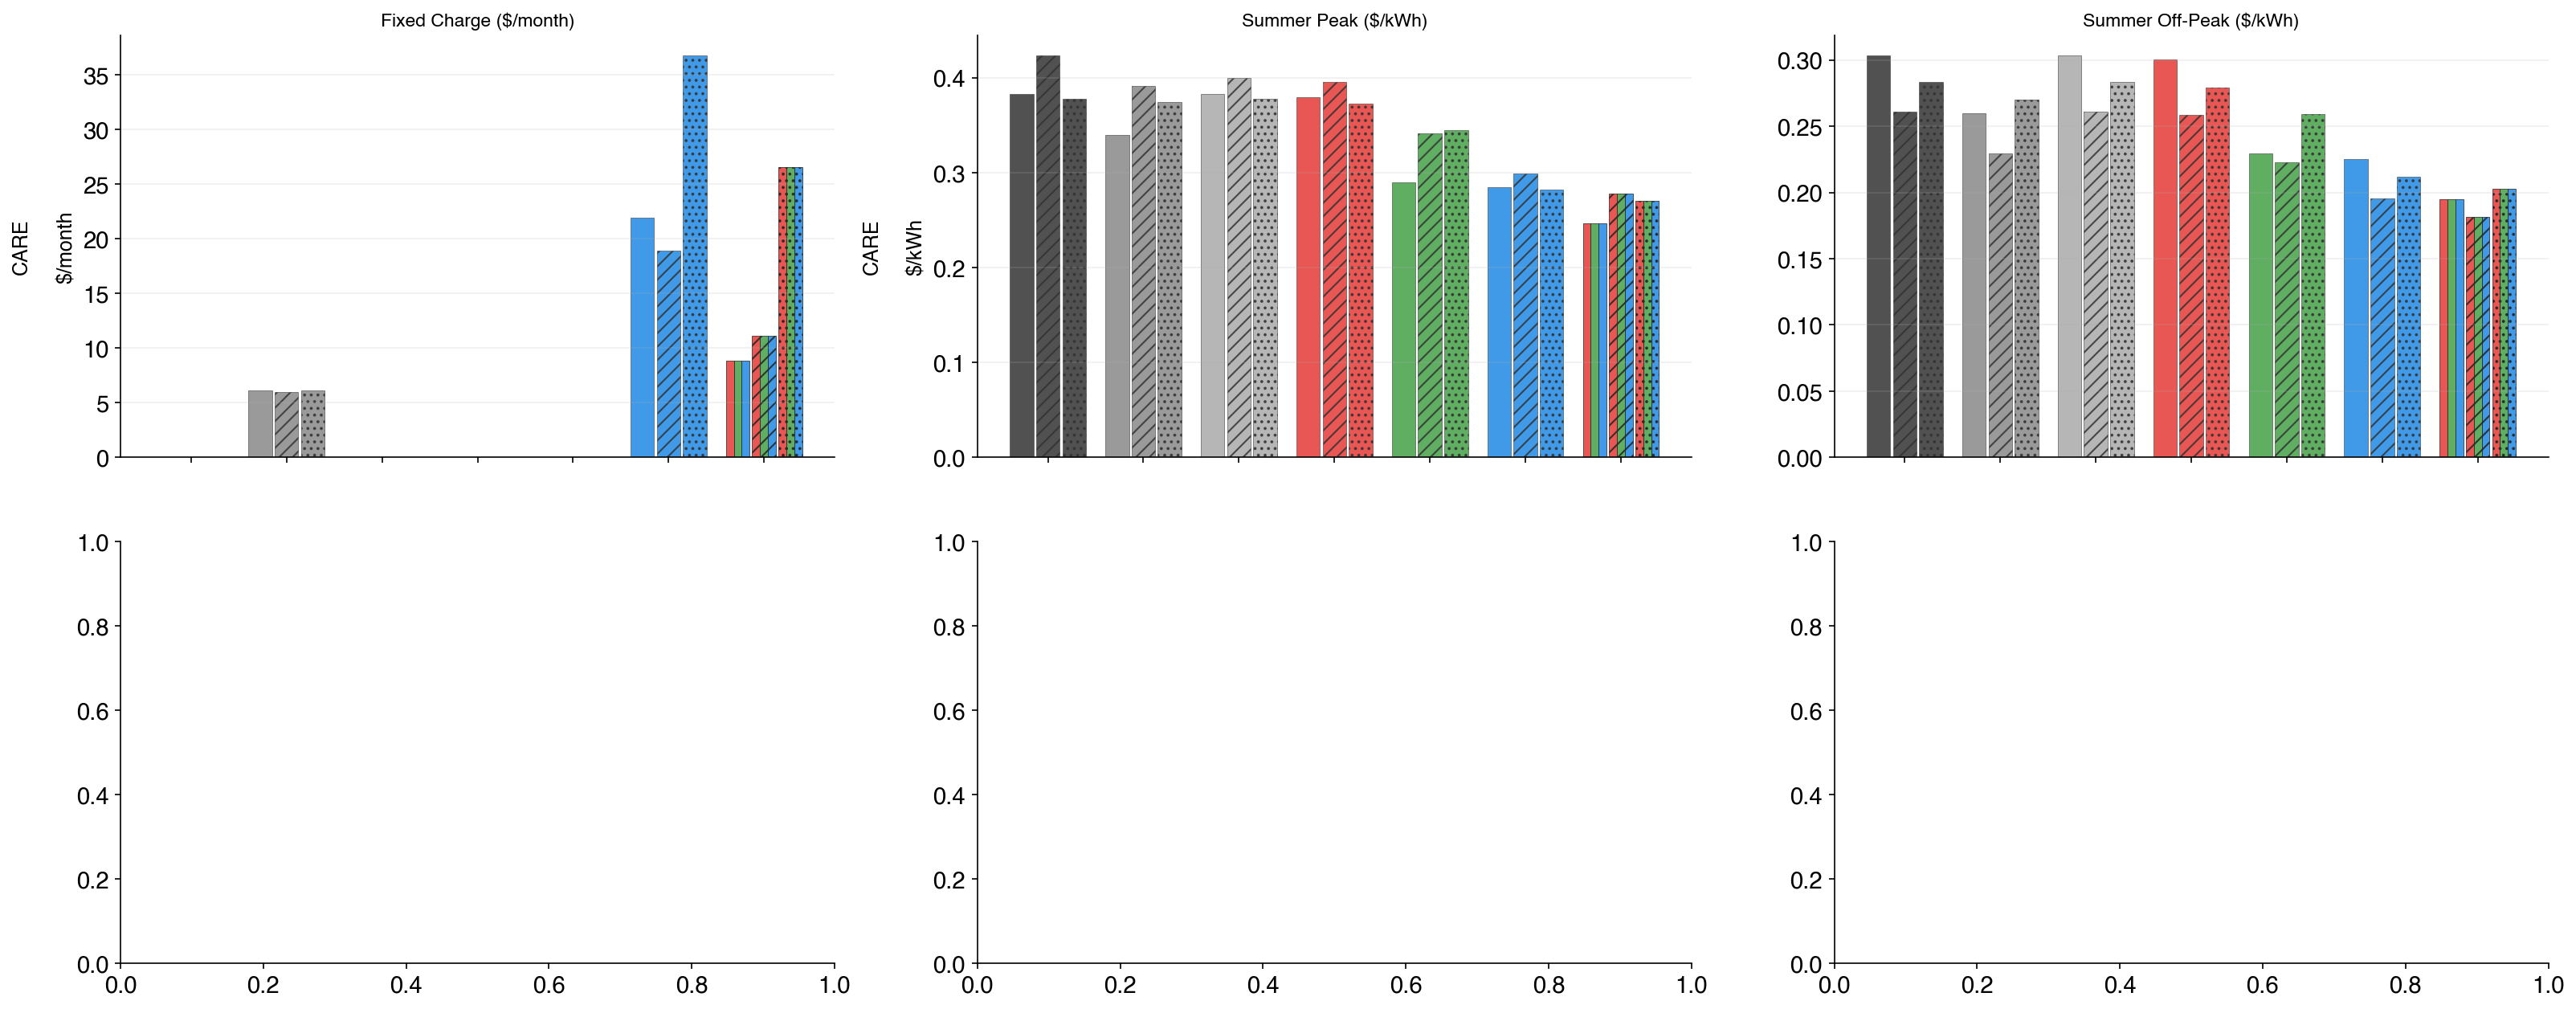

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.legend_handler import HandlerTuple

rates_pge  = pd.read_csv('rate_scenarios_pge_fresh.csv').set_index('Scenario')
rates_sce  = pd.read_csv('rate_scenarios_sce_fresh.csv').set_index('Scenario')
rates_sdge = pd.read_csv('rate_scenarios_sdge_fresh.csv').set_index('Scenario')

def load_current_rates(xlsx_path):
    df = pd.read_excel(xlsx_path, sheet_name='retail_rates_oct32025')
    df = df[df.weekday == 'weekday'].dropna(subset=['rate_type'])
    return df.set_index('rate_type')

curr_pge  = load_current_rates('retail_rates_data_PGE.xlsx')
curr_sce  = load_current_rates('retail_rates_data_SCE.xlsx')
curr_sdge = load_current_rates('retail_rates_data_SDGE.xlsx')

design_scenarios = ['F0_WF0_ROE0', 'F0_WF0_ROE1.0', 'F0_WF1_ROE0',
                    'F50_WF0_ROE0', 'F50_WF1_ROE1.0']

def build_table_simple(curr_df, rates_df, tou_name, touf_name, vol_cols):
    tou  = curr_df.loc[tou_name]
    touf = curr_df.loc[touf_name]
    care_disc_tou  = abs(tou['care_discount'])
    care_disc_touf = abs(touf['care_discount'])
    col_map = {
        'summer_peak': 'peak_rate_summer1', 'summer_offpeak': 'offpeak_rate_summer1',
        'summer_midpeak': 'midpeak_rate_summer1', 'winter_peak': 'peak_rate_winter1',
        'winter_offpeak': 'offpeak_rate_winter1', 'winter_midpeak': 'midpeak_rate_winter1',
    }
    rows = {}
    r = {'Fixed_CARE': 0, 'Fixed_NonCARE': 0, 'care_discount': care_disc_tou}
    for rc in vol_cols:
        r[rc] = tou[col_map[rc]] if col_map[rc] in tou.index else np.nan
    rows[tou_name] = r
    r = {'Fixed_CARE': touf['fixedcharge_low'], 'Fixed_NonCARE': touf['fixedcharge_med'],
         'care_discount': care_disc_touf}
    for rc in vol_cols:
        r[rc] = touf[col_map[rc]] if col_map[rc] in touf.index else np.nan
    rows[touf_name] = r
    for scen in design_scenarios:
        if scen not in rates_df.index: continue
        r = {'Fixed_CARE': rates_df.loc[scen, 'Fixed_CARE'],
             'Fixed_NonCARE': rates_df.loc[scen, 'Fixed_NonCARE'],
             'care_discount': care_disc_tou}
        for rc in vol_cols:
            r[rc] = rates_df.loc[scen, rc] if rc in rates_df.columns else np.nan
        rows[scen] = r
    return pd.DataFrame(rows).T

pge_cols  = ['summer_peak', 'summer_offpeak', 'winter_peak', 'winter_offpeak']
sce_cols  = ['summer_peak', 'summer_offpeak', 'winter_peak', 'winter_midpeak', 'winter_offpeak']
sdge_cols = ['summer_peak', 'summer_midpeak', 'summer_offpeak', 'winter_peak', 'winter_midpeak', 'winter_offpeak']

rt_pge  = build_table_simple(curr_pge,  rates_pge,  'E-TOU-C',   'E-TOU-C-F',   pge_cols)
rt_sce  = build_table_simple(curr_sce,  rates_sce,  'TOU-D-4-9', 'TOU-D-4-9-F', sce_cols)
rt_sdge = build_table_simple(curr_sdge, rates_sdge, 'TOU-DR',    'TOU-DR-F',     sdge_cols)

iou_tables = {'PG&E': rt_pge, 'SCE': rt_sce, 'SDG&E': rt_sdge}
iou_list = list(iou_tables.keys())
iou_hatches = ['', '///', '...']

generic_labels = ['Reference\nTOU', 'Ref\n+Fixed', 'Baseline',
                  'ROE\nReduction', 'Wildfire\nRemoval', '50% Fixed\nCharge',
                  'All Three\nCombined']
scen_colors = ['#333333', '#888888', '#AAAAAA', '#E53935', '#43A047', '#1E88E5', None]
combo_colors = ['#E53935', '#43A047', '#1E88E5']

components = [
    ('Fixed Charge ($/month)', 'fixed'),
    ('Summer Peak ($/kWh)',    'summer_peak'),
    ('Summer Off-Peak ($/kWh)','summer_offpeak'),
    ('Winter Peak ($/kWh)',    'winter_peak'),
    ('Winter Off-Peak ($/kWh)','winter_offpeak'),
]

n_scens = len(generic_labels)
x = np.arange(n_scens) * 0.8
bar_w = 0.22
stripe_w = bar_w * 0.9 / 3

fig, axes = plt.subplots(2, 3, figsize=(26, 10))

for row, (cg_label, is_care) in enumerate([('CARE', True), ('Non-CARE', False)]):
    for pi, (panel_title, col_key) in enumerate(components):
        ax = axes[row, pi]
        for ii, iou in enumerate(iou_list):
            rt = iou_tables[iou]
            offset = (ii - 1) * bar_w
            for si in range(n_scens):
                scen = rt.index[si]
                if col_key == 'fixed':
                    val = rt.loc[scen, 'Fixed_CARE' if is_care else 'Fixed_NonCARE']
                else:
                    if col_key not in rt.columns or pd.isna(rt.loc[scen, col_key]):
                        continue
                    val = rt.loc[scen, col_key]
                    if is_care:
                        val = val * (1 - rt.loc[scen, 'care_discount'])
                xpos = x[si] + offset
                if scen_colors[si] is not None:
                    ax.bar(xpos, val, bar_w * 0.9, color=scen_colors[si], alpha=0.85,
                           edgecolor='#333', linewidth=0.3, hatch=iou_hatches[ii])
                else:
                    for sti, sc in enumerate(combo_colors):
                        sx = xpos - bar_w*0.9/2 + stripe_w*sti + stripe_w/2
                        ax.bar(sx, val, stripe_w, color=sc, alpha=0.85,
                               edgecolor='#222', linewidth=0.4, hatch=iou_hatches[ii])
        ax.set_xticks(x)
        ax.set_xticklabels(generic_labels if row == 1 else [], fontsize=8, rotation=35, ha='right')
        ax.grid(axis='y', alpha=0.2)
        if row == 0:
            ax.set_title(panel_title, fontweight='bold', fontsize=11)
        if pi == 0:
            ax.set_ylabel(f'{cg_label}\n\n$/month', fontsize=12, fontweight='bold')
        elif pi == 1:
            ax.set_ylabel(f'{cg_label}\n\n$/kWh', fontsize=12, fontweight='bold')

# ── Sync y-axes: fixed charge (col 0) and volumetric (cols 1-4) ──
ymin_fc = min(axes[r, 0].get_ylim()[0] for r in range(2))
ymax_fc = max(axes[r, 0].get_ylim()[1] for r in range(2))
for r in range(2):
    axes[r, 0].set_ylim(ymin_fc, ymax_fc)

ymin_vol = min(axes[r, c].get_ylim()[0] for r in range(2) for c in range(1, 5))
ymax_vol = max(axes[r, c].get_ylim()[1] for r in range(2) for c in range(1, 5))
for r in range(2):
    for c in range(1, 5):
        axes[r, c].set_ylim(ymin_vol, ymax_vol)

# ── Legends ──
rate_patches = [mpatches.Patch(facecolor=c, label=l, alpha=0.85, ec='#333', lw=0.3)
                for c, l in zip(scen_colors[:-1], generic_labels[:-1])]
combo_leg = tuple([mpatches.Patch(facecolor=c, alpha=0.85, ec='#333', lw=0.3) for c in combo_colors])
iou_patches = [mpatches.Patch(facecolor='white', hatch=h, label=n, ec='#333', lw=0.5)
               for n, h in zip(iou_list, iou_hatches)]

leg1 = fig.legend(handles=rate_patches + [combo_leg],
                  labels=[l.replace('\n', ' ') for l in generic_labels[:-1]] + ['All Three Combined'],
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
                  loc='lower center', ncol=len(rate_patches)+1,
                  fontsize=14, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.legend(handles=iou_patches, loc='lower center', ncol=3,
           fontsize=14, frameon=True, bbox_to_anchor=(0.5, -0.06))
fig.add_artist(leg1)

fig.suptitle('Rate Component Comparison — All IOUs\n(CARE discounts from tariff schedules)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

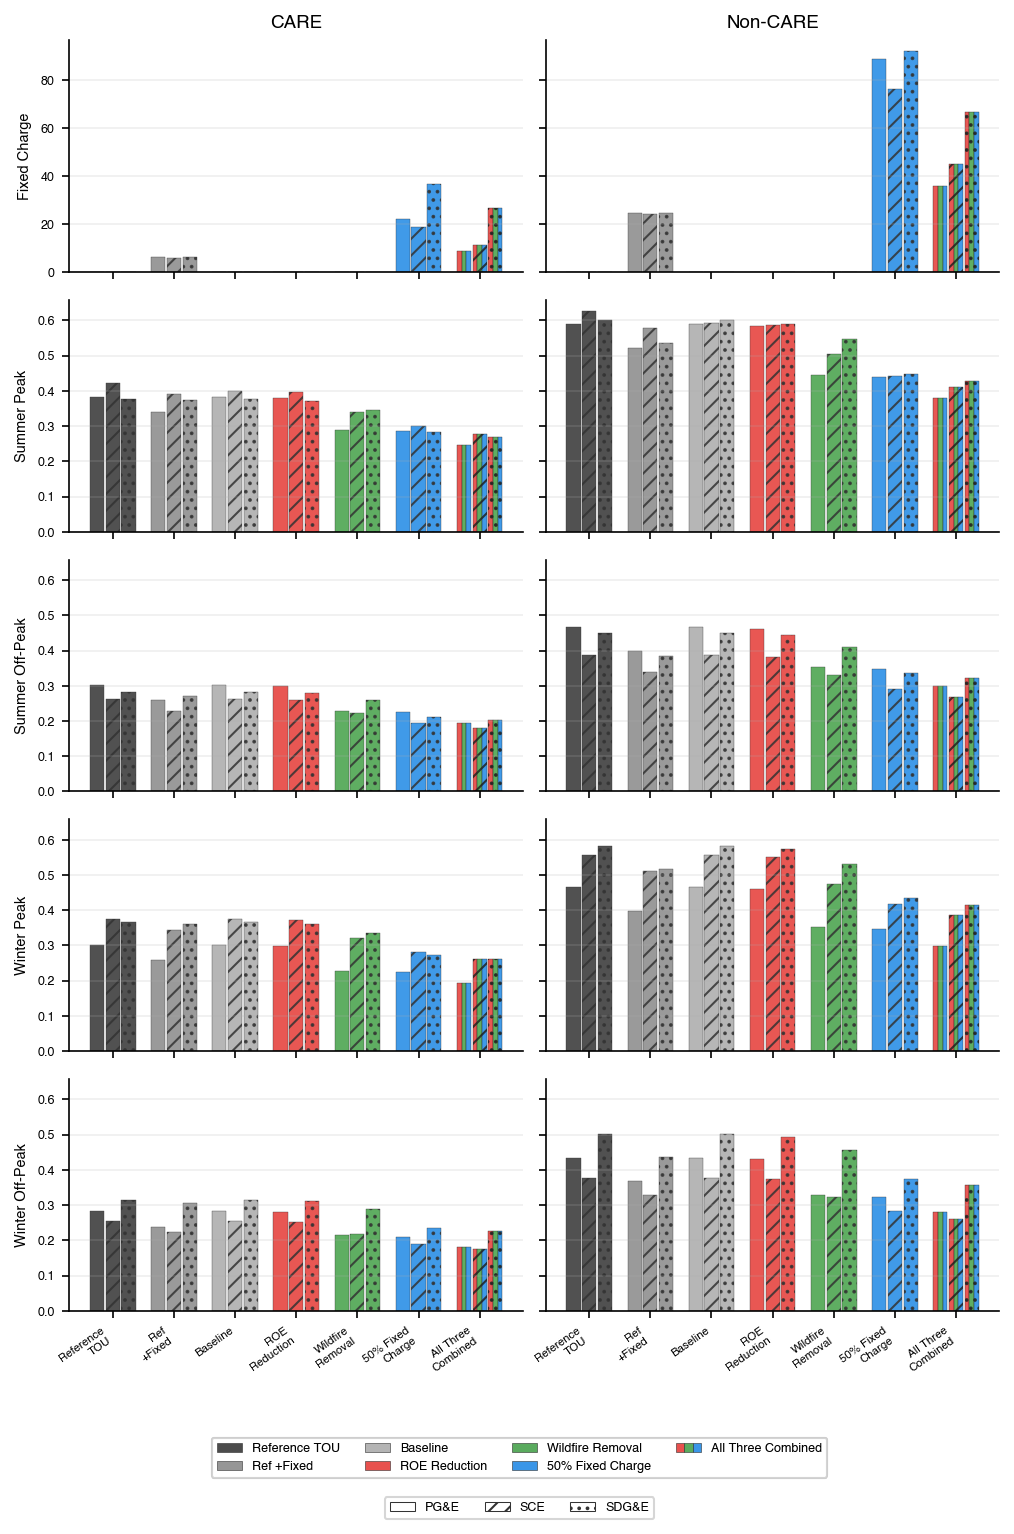

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.legend_handler import HandlerTuple

rates_pge  = pd.read_csv('rate_scenarios_pge_fresh.csv').set_index('Scenario')
rates_sce  = pd.read_csv('rate_scenarios_sce_fresh.csv').set_index('Scenario')
rates_sdge = pd.read_csv('rate_scenarios_sdge_fresh.csv').set_index('Scenario')

def load_current_rates(xlsx_path):
    df = pd.read_excel(xlsx_path, sheet_name='retail_rates_oct32025')
    df = df[df.weekday == 'weekday'].dropna(subset=['rate_type'])
    return df.set_index('rate_type')

curr_pge  = load_current_rates('retail_rates_data_PGE.xlsx')
curr_sce  = load_current_rates('retail_rates_data_SCE.xlsx')
curr_sdge = load_current_rates('retail_rates_data_SDGE.xlsx')

design_scenarios = ['F0_WF0_ROE0', 'F0_WF0_ROE1.0', 'F0_WF1_ROE0',
                    'F50_WF0_ROE0', 'F50_WF1_ROE1.0']

def build_table_simple(curr_df, rates_df, tou_name, touf_name, vol_cols):
    tou  = curr_df.loc[tou_name]
    touf = curr_df.loc[touf_name]
    care_disc_tou  = abs(tou['care_discount'])
    care_disc_touf = abs(touf['care_discount'])
    col_map = {
        'summer_peak': 'peak_rate_summer1', 'summer_offpeak': 'offpeak_rate_summer1',
        'summer_midpeak': 'midpeak_rate_summer1', 'winter_peak': 'peak_rate_winter1',
        'winter_offpeak': 'offpeak_rate_winter1', 'winter_midpeak': 'midpeak_rate_winter1',
    }
    rows = {}
    r = {'Fixed_CARE': 0, 'Fixed_NonCARE': 0, 'care_discount': care_disc_tou}
    for rc in vol_cols:
        r[rc] = tou[col_map[rc]] if col_map[rc] in tou.index else np.nan
    rows[tou_name] = r
    r = {'Fixed_CARE': touf['fixedcharge_low'], 'Fixed_NonCARE': touf['fixedcharge_med'],
         'care_discount': care_disc_touf}
    for rc in vol_cols:
        r[rc] = touf[col_map[rc]] if col_map[rc] in touf.index else np.nan
    rows[touf_name] = r
    for scen in design_scenarios:
        if scen not in rates_df.index: continue
        r = {'Fixed_CARE': rates_df.loc[scen, 'Fixed_CARE'],
             'Fixed_NonCARE': rates_df.loc[scen, 'Fixed_NonCARE'],
             'care_discount': care_disc_tou}
        for rc in vol_cols:
            r[rc] = rates_df.loc[scen, rc] if rc in rates_df.columns else np.nan
        rows[scen] = r
    return pd.DataFrame(rows).T

pge_cols  = ['summer_peak', 'summer_offpeak', 'winter_peak', 'winter_offpeak']
sce_cols  = ['summer_peak', 'summer_offpeak', 'winter_peak', 'winter_midpeak', 'winter_offpeak']
sdge_cols = ['summer_peak', 'summer_midpeak', 'summer_offpeak', 'winter_peak', 'winter_midpeak', 'winter_offpeak']

rt_pge  = build_table_simple(curr_pge,  rates_pge,  'E-TOU-C',   'E-TOU-C-F',   pge_cols)
rt_sce  = build_table_simple(curr_sce,  rates_sce,  'TOU-D-4-9', 'TOU-D-4-9-F', sce_cols)
rt_sdge = build_table_simple(curr_sdge, rates_sdge, 'TOU-DR',    'TOU-DR-F',     sdge_cols)

iou_tables = {'PG&E': rt_pge, 'SCE': rt_sce, 'SDG&E': rt_sdge}
iou_list = list(iou_tables.keys())
iou_hatches = ['', '///', '...']

generic_labels = ['Reference\nTOU', 'Ref\n+Fixed', 'Baseline',
                  'ROE\nReduction', 'Wildfire\nRemoval', '50% Fixed\nCharge',
                  'All Three\nCombined']
scen_colors = ['#333333', '#888888', '#AAAAAA', '#E53935', '#43A047', '#1E88E5', None]
combo_colors = ['#E53935', '#43A047', '#1E88E5']

# 5x2: rows = fixed, summer peak, summer offpeak, winter peak, winter offpeak
# cols = CARE, Non-CARE
components = [
    ('Fixed Charge',    'fixed'),
    ('Summer Peak',     'summer_peak'),
    ('Summer Off-Peak', 'summer_offpeak'),
    ('Winter Peak',     'winter_peak'),
    ('Winter Off-Peak', 'winter_offpeak'),
]

n_scens = len(generic_labels)
x = np.arange(n_scens) * 0.7
bar_w = 0.18
stripe_w = bar_w * 0.9 / 3

fig, axes = plt.subplots(5, 2, figsize=(8, 11), gridspec_kw={'wspace': 0.05, 'hspace': 0.12})

for ri, (row_title, col_key) in enumerate(components):
    for ci, (cg_label, is_care) in enumerate([('CARE', True), ('Non-CARE', False)]):
        ax = axes[ri, ci]
        for ii, iou in enumerate(iou_list):
            rt = iou_tables[iou]
            offset = (ii - 1) * bar_w
            for si in range(n_scens):
                scen = rt.index[si]
                if col_key == 'fixed':
                    val = rt.loc[scen, 'Fixed_CARE' if is_care else 'Fixed_NonCARE']
                else:
                    if col_key not in rt.columns or pd.isna(rt.loc[scen, col_key]):
                        continue
                    val = rt.loc[scen, col_key]
                    if is_care:
                        val = val * (1 - rt.loc[scen, 'care_discount'])
                xpos = x[si] + offset
                if scen_colors[si] is not None:
                    ax.bar(xpos, val, bar_w * 0.9, color=scen_colors[si], alpha=0.85,
                           edgecolor='#333', linewidth=0.2, hatch=iou_hatches[ii])
                else:
                    for sti, sc in enumerate(combo_colors):
                        sx = xpos - bar_w*0.9/2 + stripe_w*sti + stripe_w/2
                        ax.bar(sx, val, stripe_w, color=sc, alpha=0.85,
                               edgecolor='#222', linewidth=0.2, hatch=iou_hatches[ii])

        ax.grid(axis='y', alpha=0.2)
        ax.tick_params(labelsize=6)
        if ri == 0:
            ax.set_title(cg_label, fontsize=9, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(row_title, fontsize=7, fontweight='bold')
        else:
            ax.tick_params(labelleft=False)
        if ri == 4:
            ax.set_xticks(x)
            ax.set_xticklabels(generic_labels, fontsize=5.5, rotation=35, ha='right')
        else:
            ax.set_xticks(x); ax.set_xticklabels([])

# Sync y-axes: fixed charge row alone, all volumetric rows together
ymin_fc = min(axes[0, c].get_ylim()[0] for c in range(2))
ymax_fc = max(axes[0, c].get_ylim()[1] for c in range(2))
for c in range(2):
    axes[0, c].set_ylim(ymin_fc, ymax_fc)

ymin_vol = min(axes[r, c].get_ylim()[0] for r in range(1, 5) for c in range(2))
ymax_vol = max(axes[r, c].get_ylim()[1] for r in range(1, 5) for c in range(2))
for r in range(1, 5):
    for c in range(2):
        axes[r, c].set_ylim(ymin_vol, ymax_vol)

# Legends
rate_patches = [mpatches.Patch(facecolor=c, label=l.replace('\n', ' '), alpha=0.85, ec='#333', lw=0.3)
                for c, l in zip(scen_colors[:-1], generic_labels[:-1])]
combo_leg = tuple([mpatches.Patch(facecolor=c, alpha=0.85, ec='#333', lw=0.3) for c in combo_colors])
iou_patches = [mpatches.Patch(facecolor='white', hatch=h, label=n, ec='#333', lw=0.5)
               for n, h in zip(iou_list, iou_hatches)]

leg1 = fig.legend(handles=rate_patches + [combo_leg],
                  labels=[p.get_label() for p in rate_patches] + ['All Three Combined'],
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
                  loc='lower center', ncol=4,
                  fontsize=6, frameon=True, bbox_to_anchor=(0.5, 0.005))
fig.legend(handles=iou_patches, loc='lower center', ncol=3,
           fontsize=6, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.add_artist(leg1)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

## 4. Compute Bill Changes

In [216]:
tech_scenarios = [
    ('No DER',  ''),
        ('EV Only',        '_s1_ev'),
    ('PV + Storage',   '_s2_pv_stor'),
    ('PV + Stor + EV',     's3_placeholder'),
]

# (label, key, color, apply_min_bill)
rate_defs = [
    ('Current Fixed Chg',  'sqf',           '#888888', False),
    #('Baseline',           'F0_WF0_ROE0',   '#AAAAAA', True)
    ('50% Fixed Charge',   'F50_WF0_ROE0',  '#1E88E5', False),

    ('ROE Reduction',      'F0_WF0_ROE1.0', '#E53935', True),
    ('Wildfire Removal',   'F0_WF1_ROE0',   '#43A047', True),
    ('All Three Combined', 'F50_WF1_ROE1.0', None,     False),
]

combo_colors = ['#E53935', '#43A047', '#1E88E5']
iou_names = list(configs.keys())
iou_hatches = ['', '///', '...']
MIN_N = 30

def get_sfx(tname, ucfg):
    if tname == 'PV + Stor + EV': return ucfg['s3_sfx']
    for t, s in tech_scenarios:
        if t == tname: return s
    return ''

# ── Compute stats ──
stats_dollar = {}
stats_pct = {}

for iou, ucfg in configs.items():
    df = dfs[iou]
    min_bill = ucfg['min_bill']

    for tname, _ in tech_scenarios:
        sfx = get_sfx(tname, ucfg)
        sq_col = f'{ucfg["sq"]}{sfx}'
        sqf_col = f'{ucfg["sqf"]}{sfx}'
        if sq_col not in df.columns:
            continue
        sub = df[df[sq_col].notna()]
        if len(sub) < MIN_N:
            continue

        # Floor the status quo (volumetric TOU has min bill)
        sq_floored = sub[sq_col].clip(lower=min_bill)

        for care_grp in ['CARE', 'Non-CARE']:
            cmask = sub['care_group'] == care_grp
            sq_vals = sq_floored[cmask]

            for ri, (_, rkey, _, apply_floor) in enumerate(rate_defs):
                bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill{sfx}'
                if bill_col not in sub.columns:
                    continue

                new_bills = sub.loc[cmask, bill_col].copy()
                if apply_floor and min_bill > 0:
                    new_bills = new_bills.clip(lower=min_bill)

                d_chg = (new_bills - sq_vals).dropna()
                valid = sq_vals.abs() > 10
                p_chg = ((new_bills[valid] - sq_vals[valid]) / sq_vals[valid].abs() * 100).dropna()

                key = (tname, care_grp, iou, ri)
                if len(d_chg) >= 5:
                    stats_dollar[key] = (d_chg.median(), d_chg.mean(), d_chg.std(), len(d_chg))
                if len(p_chg) >= 5:
                    stats_pct[key] = (p_chg.median(), p_chg.mean(), p_chg.std(), len(p_chg))

print(f'Computed {len(stats_dollar)} stat entries (dollar), {len(stats_pct)} (pct)')


Computed 120 stat entries (dollar), 120 (pct)


## 5. Plot Configuration & Stats

In [217]:
# ── Rate definitions ──
# Comment out any row to remove it from plots
rate_defs = [
    ('CPUC Fixed Charge',  'sqf',           'lightgray', False),
    # ('Baseline',           'F0_WF0_ROE0',   '#AAAAAA', True),    # ← uncomment to include
    ('50% Fixed Charge',   'F50_WF0_ROE0',  '#1E88E5', False),

    ('1% ROE Reduction',      'F0_WF0_ROE1.0', '#E53935', True),
    ('Wildfire Removal',   'F0_WF1_ROE0',   '#43A047', True),
    ('All Three Combined', 'F50_WF1_ROE1.0', None,     False),
]

combo_colors = ['#E53935', '#43A047', '#1E88E5']
iou_names = list(configs.keys())
iou_hatches = ['', '///', '...']

tech_names = [t[0] for t in tech_scenarios]
n_tech = len(tech_names)
n_rates = len(rate_defs)
bar_w = 0.1
stripe_w = bar_w * 0.9 / 3

# ── Recompute stats with current rate_defs ──
stats_dollar = {}
stats_pct = {}

for iou, ucfg in configs.items():
    df = dfs[iou]
    min_bill = ucfg['min_bill']
    for tname, _ in tech_scenarios:
        sfx = get_sfx(tname, ucfg)
        sq_col = f'{ucfg["sq"]}{sfx}'
        sqf_col = f'{ucfg["sqf"]}{sfx}'
        if sq_col not in df.columns: continue
        sub = df[df[sq_col].notna()]
        if len(sub) < 30: continue
        sq_floored = sub[sq_col].clip(lower=min_bill)
        for care_grp in ['CARE', 'Non-CARE']:
            cmask = sub['care_group'] == care_grp
            sq_vals = sq_floored[cmask]
            for ri, (_, rkey, _, apply_floor) in enumerate(rate_defs):
                bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill{sfx}'
                if bill_col not in sub.columns: continue
                new_bills = sub.loc[cmask, bill_col].copy()
                if apply_floor and min_bill > 0:
                    new_bills = new_bills.clip(lower=min_bill)
                d_chg = (new_bills - sq_vals).dropna()
                valid = sq_vals.abs() > 10
                p_chg = ((new_bills[valid] - sq_vals[valid]) / sq_vals[valid].abs() * 100).dropna()
                key = (tname, care_grp, iou, ri)
                if len(d_chg) >= 5:
                    stats_dollar[key] = (d_chg.median(), d_chg.mean(), d_chg.std(), len(d_chg))
                if len(p_chg) >= 5:
                    stats_pct[key] = (p_chg.median(), p_chg.mean(), p_chg.std(), len(p_chg))

print(f'Stats: {len(stats_dollar)} dollar, {len(stats_pct)} pct')


Stats: 120 dollar, 120 pct


In [ ]:
stats_pct

## 5a. Mean Dollar Change

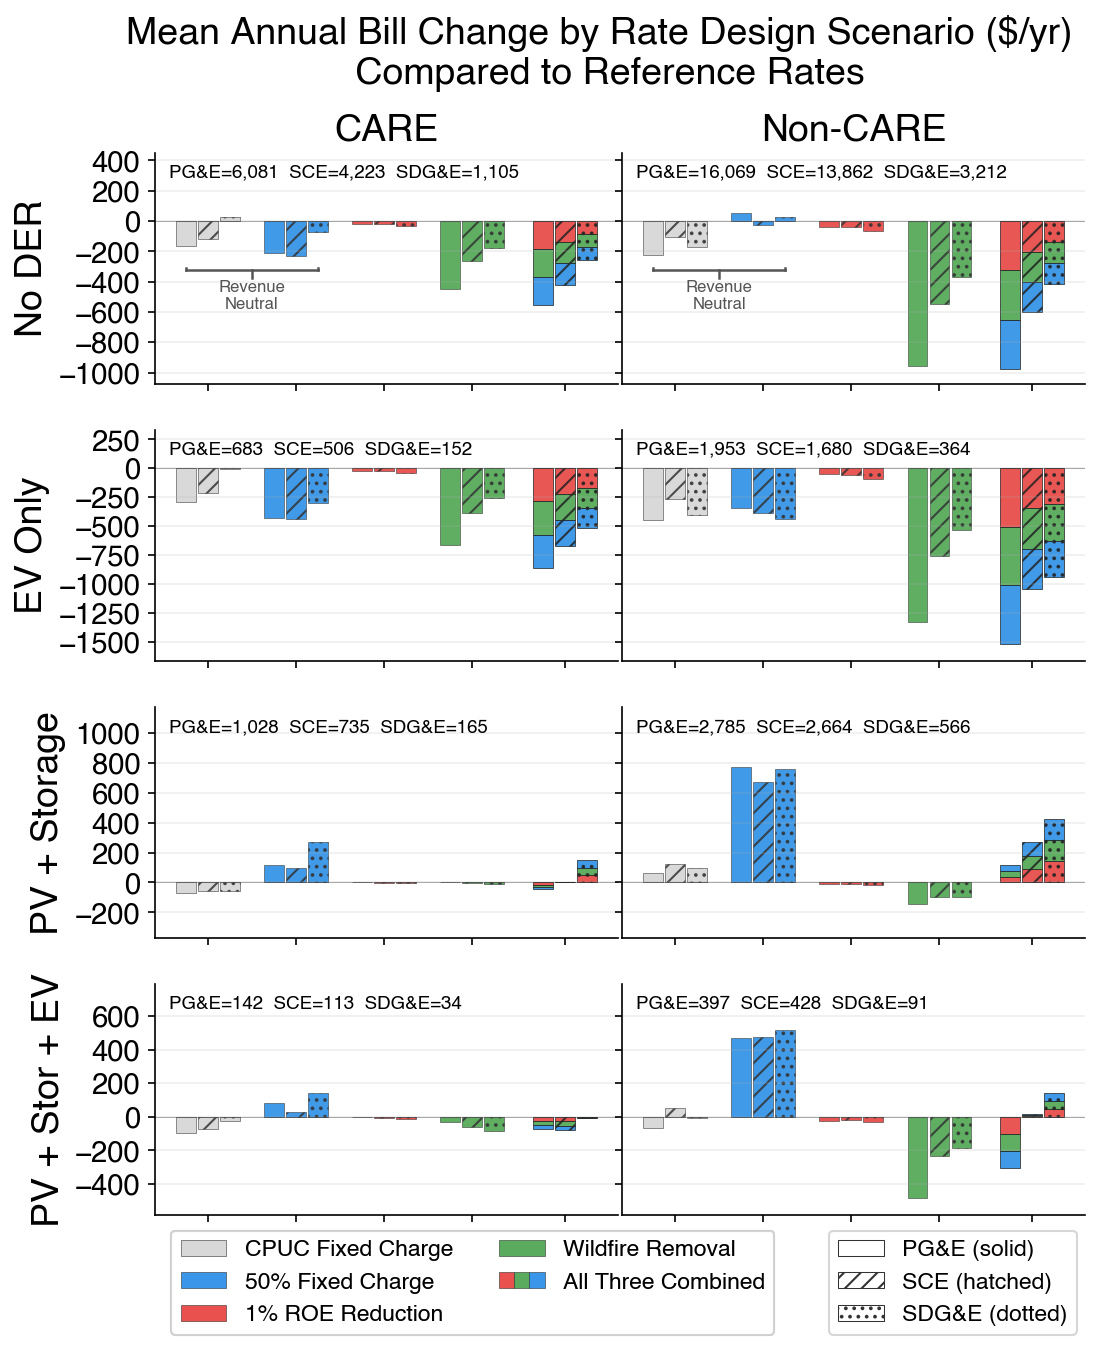

In [219]:
from matplotlib.legend_handler import HandlerTuple
import matplotlib.patches as mpatches
import numpy as np

stats = stats_dollar
fig, axes = plt.subplots(n_tech, 2, figsize=(8, 2.3 * n_tech), gridspec_kw={'wspace': 0.01})

for ti, tname in enumerate(tech_names):
    row_vals = [stats[(tname, cg, iou, ri)][0]
                for cg in ['CARE', 'Non-CARE'] for iou in iou_names
                for ri in range(n_rates) if (tname, cg, iou, ri) in stats]
    if row_vals:
        ymin, ymax = min(row_vals), max(row_vals)
        ymax = max(ymax, abs(ymin) * 0.5, 10)
        ymin, ymax = min(row_vals), max(row_vals)
        pad = max((ymax - ymin) * 0.25, 5)
        ylims = (ymin - pad, ymax + pad)
    else:
        ylims = None

    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ti, ci]
        if ylims: ax.set_ylim(ylims)
        from matplotlib.ticker import MaxNLocator
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))

        x_base = np.arange(n_rates).astype(float) * 0.4
        x_base[-1] += 0.02

        for ii, iou in enumerate(iou_names):
            offset = (ii - 1) * bar_w
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key not in stats: continue
                med, mean_v, sd_v, _ = stats[key]
                val = mean_v
                xpos = x_base[ri] + offset

                if ri < n_rates - 1:
                    kw = dict(color=rate_defs[ri][2], alpha=0.85,
                              edgecolor='#333333', linewidth=0.3,
                              hatch=iou_hatches[ii])
                    ax.bar(xpos, val, bar_w * 0.9, **kw)
                else:
                    # Combo: stack three colors vertically (each 1/3 of value)
                    third = val / 3
                    for si, sc in enumerate(combo_colors):
                        ax.bar(xpos, third, bar_w * 0.9, bottom=si * third,
                               color=sc, alpha=0.85,
                               edgecolor='#222222', linewidth=0.4,
                               hatch=iou_hatches[ii])

        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(axis='y', alpha=0.2)
        if ci == 0: ax.set_ylabel(tname, fontsize=18)
        else: ax.tick_params(labelleft=False)
        if ti == 0: ax.set_title(cg, fontsize=18, fontweight='bold')

        ns = [f'{iou}={stats[(tname, cg, iou, 0)][3]:,}' for iou in iou_names if (tname, cg, iou, 0) in stats]
        ax.text(0.03, 0.95, '  '.join(ns), transform=ax.transAxes,
                ha='left', va='top', fontsize=9, color='black')
        ax.set_xticks(x_base)
        ax.set_xticklabels([])

# Revenue neutral bracket on first row only
for ci in range(2):
    ax = axes[0, ci]
    ymin_ax = -500

    x_left = x_base[0] -0.1
    x_right = x_base[1] + 0.1
    x_mid = (x_base[0] + x_base[1]) / 2

    bracket_top = ymin_ax * 0.65
    bracket_bottom = ymin_ax * 0.75

    ax.plot([x_left, x_right], [bracket_top, bracket_top],
            color='#555', lw=1.2, clip_on=False)
    ax.plot([x_left, x_left], [bracket_top, bracket_top + abs(ymin_ax) * 0.03],
            color='#555', lw=1.2, clip_on=False)
    ax.plot([x_right, x_right], [bracket_top, bracket_top + abs(ymin_ax) * 0.03],
            color='#555', lw=1.2, clip_on=False)
    ax.plot([x_mid, x_mid], [bracket_top, bracket_bottom],
            color='#555', lw=1.2, clip_on=False)
    ax.text(x_mid, bracket_bottom - abs(ymin_ax) * 0.02, 'Revenue\nNeutral',
            ha='center', va='top', fontsize=8, fontweight='bold',
            color='#555', style='italic')

# Legends
rate_patches = [mpatches.Patch(facecolor=rd[2] if rd[2] else '#7B1FA2',
                                label=rd[0] + ('' if rd[3] else ''),
                                alpha=0.85, ec='#333', lw=0.3) for rd in rate_defs[:-1]]
combo_legend = tuple([mpatches.Patch(facecolor=c, alpha=0.85, ec='#333', lw=0.3) for c in combo_colors])
iou_patches = [
    mpatches.Patch(facecolor='white', hatch='', label='PG&E (solid)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='///', label='SCE (hatched)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='...', label='SDG&E (dotted)', ec='#333', lw=0.5),
]

leg1 = fig.legend(handles=rate_patches + [combo_legend],
                  labels=[p.get_label() for p in rate_patches] + ['All Three Combined'],
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
                  loc='lower center', ncol=len(rate_patches) + 1,
                  fontsize=11, frameon=True, bbox_to_anchor=(0.39, 0.015), ncols=2)
fig.legend(handles=iou_patches, loc='lower center', ncol=1,
           fontsize=11, frameon=True, bbox_to_anchor=(0.79, 0.015))

fig.suptitle('Mean Annual Bill Change by Rate Design Scenario ($/yr) \n Compared to Reference Rates',
             fontsize=18, fontweight='bold')
fig.add_artist(leg1)
fig.savefig('fig_bill_change_dollar.pdf', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()


## 5b. Mean % Change

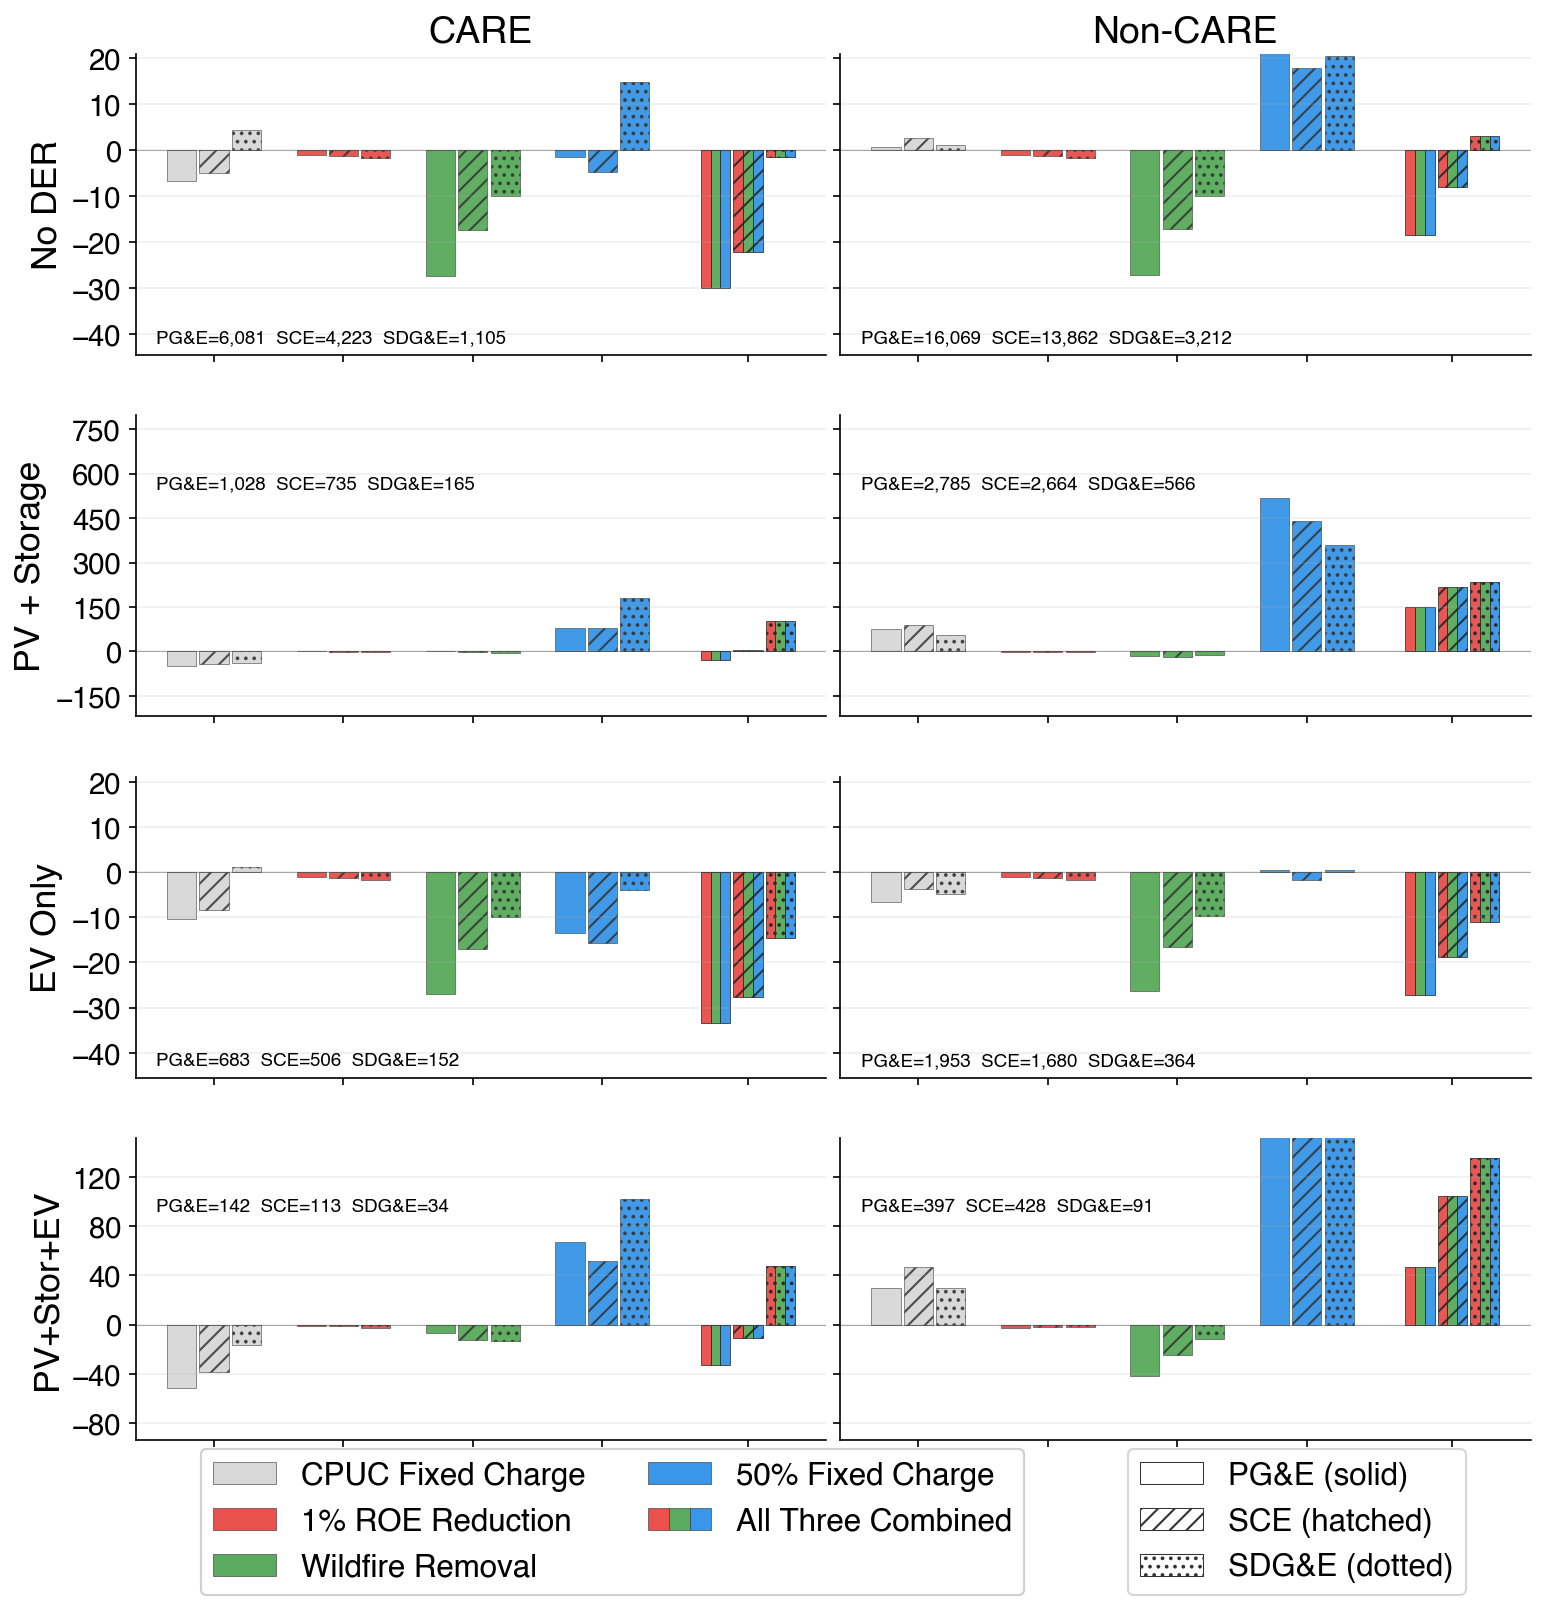

In [126]:
# ── Median bill change (%) ──
stats = stats_pct
from matplotlib.legend_handler import HandlerTuple
fig, axes = plt.subplots(n_tech, 2, figsize=(12, 3 * n_tech), gridspec_kw={'wspace': 0.02})
for ti, tname in enumerate(tech_names):
    # Shared y-limits across CARE and Non-CARE for this row
    row_vals = [stats[(tname, cg, iou, ri)][0]
                for cg in ['CARE', 'Non-CARE'] for iou in iou_names
                for ri in range(n_rates) if (tname, cg, iou, ri) in stats]
    if row_vals:
        ymin, ymax = min(row_vals), max(row_vals)
        ymax = max(ymax, abs(ymin) * 0.25, 10)
        pad = max((ymax - ymin) * 0.25, 5)
        ylims = (ymin - pad, ymax + pad)
    else:
        ylims = None
    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ti, ci]
        if ylims: ax.set_ylim(ylims)
        from matplotlib.ticker import MaxNLocator
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))

        x_base = np.arange(n_rates).astype(float)*0.4
        x_base[-1] += 0.05
        for ii, iou in enumerate(iou_names):
            offset = (ii - 1) * bar_w
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key not in stats: continue
                med, mean_v, sd_v, _ = stats[key]
                val = mean_v
                xpos = x_base[ri] + offset
                if ri < n_rates - 1:
                    kw = dict(color=rate_defs[ri][2], alpha=0.85,
                              edgecolor='#333333', linewidth=0.3,
                              hatch=iou_hatches[ii])
                    ax.bar(xpos, val, bar_w * 0.9, **kw)
                else:
                    for si, sc in enumerate(combo_colors):
                        sx = xpos - bar_w*0.9/2 + stripe_w*si + stripe_w/2
                        ax.bar(sx, val, stripe_w, color=sc, alpha=0.85,
                               edgecolor='#222222', linewidth=0.4, hatch=iou_hatches[ii])
        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(axis='y', alpha=0.2)
        if ci == 0: ax.set_ylabel(tname, fontsize=17)
        else: ax.tick_params(labelleft=False)
        if ti == 0: ax.set_title(cg, fontsize=18, fontweight='bold')
        ns = [f'{iou}={stats[(tname, cg, iou, 0)][3]:,}' for iou in iou_names if (tname, cg, iou, 0) in stats]
        if tname in ['PV + Storage', 'PV+Stor+EV']:
            ax.text(0.03, 0.8, '  '.join(ns), transform=ax.transAxes,
                    ha='left', va='top', fontsize=9, color='black')
        else:
            ax.text(0.03, 0.03, '  '.join(ns), transform=ax.transAxes,
                    ha='left', va='bottom', fontsize=9, color='black')
        ax.set_xticks(x_base); ax.set_xticklabels([])
# Legends
rate_patches = [mpatches.Patch(facecolor=rd[2] if rd[2] else '#7B1FA2', label=rd[0] + ('' if rd[3] else ''),
                               alpha=0.85, ec='#333', lw=0.3) for rd in rate_defs[:-1]]
combo_legend = tuple([mpatches.Patch(facecolor=c, alpha=0.85, ec='#333', lw=0.3) for c in combo_colors])
iou_patches = [
    mpatches.Patch(facecolor='white', hatch='', label='PG&E (solid)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='///', label='SCE (hatched)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='...', label='SDG&E (dotted)', ec='#333', lw=0.5),
]
leg1 = fig.legend(handles=rate_patches + [combo_legend],
                  labels=[p.get_label() for p in rate_patches] + ['All Three Combined'],
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
                  loc='lower center', ncol=len(rate_patches)+1,
                  fontsize=15, frameon=True, bbox_to_anchor=(0.39, 0.015), ncols = 2)
fig.legend(handles=iou_patches, loc='lower center', ncol=1,
           fontsize=15, frameon=True, bbox_to_anchor=(0.77, 0.015))
fig.add_artist(leg1)

## 8. Climate Zone Analysis — PG&E

Households are assigned to climate zones based on PUMA county codes:
- **Coastal/Mild**: San Francisco, San Mateo, Santa Cruz, Monterey, Marin, Sonoma, etc.
- **Inland/Hot**: Sacramento, Kern, Fresno, Kings, Madera, etc.
- **Inland/Moderate**: Contra Costa, Solano, Placer, El Dorado, etc.

In [128]:
# ── Climate zone mapping ──
coastal = [
    'San Francisco', 'San Mateo', 'Santa Cruz', 'Monterey', 'Marin',
    'Sonoma', 'Humboldt', 'Santa Clara', 'Alameda', 'San Luis Obispo', 'Napa',
]
inland_hot = [
    'Sacramento', 'Kern', 'Fresno', 'Kings', 'Madera', 'Merced',
    'Stanislaus', 'San Joaquin', 'Tulare', 'Colusa', 'Sutter',
]
inland_mild = [
    'Contra Costa', 'Solano', 'Placer', 'El Dorado', 'Nevada',
    'Butte', 'Shasta', 'Lake', 'Yolo',
]
fips = {
    1: 'Alameda', 7: 'Butte', 11: 'Colusa', 13: 'Contra Costa',
    17: 'El Dorado', 19: 'Fresno', 23: 'Humboldt', 29: 'Kern',
    31: 'Kings', 33: 'Lake', 39: 'Madera', 41: 'Marin',
    47: 'Merced', 53: 'Monterey', 55: 'Napa', 57: 'Nevada',
    61: 'Placer', 67: 'Sacramento', 75: 'San Francisco',
    77: 'San Joaquin', 79: 'San Luis Obispo', 81: 'San Mateo',
    85: 'Santa Clara', 87: 'Santa Cruz', 89: 'Shasta', 95: 'Solano',
    97: 'Sonoma', 99: 'Stanislaus', 101: 'Sutter', 107: 'Tulare',
    113: 'Yolo',
}

p = dfs['PG&E'].copy()
p['county'] = p['puma'].str[4:7].astype(int).map(fips)
p['zone'] = p['county'].apply(
    lambda c: 'Coastal/Mild' if c in coastal
    else ('Inland/Hot' if c in inland_hot
          else ('Inland/Moderate' if c in inland_mild else None)))
p = p[p.zone.notna()]

print(f'PG&E households with zone assignment: {len(p):,}')
print(p.zone.value_counts())


PG&E households with zone assignment: 22,107
zone
Coastal/Mild       11071
Inland/Hot          6116
Inland/Moderate     4920
Name: count, dtype: int64


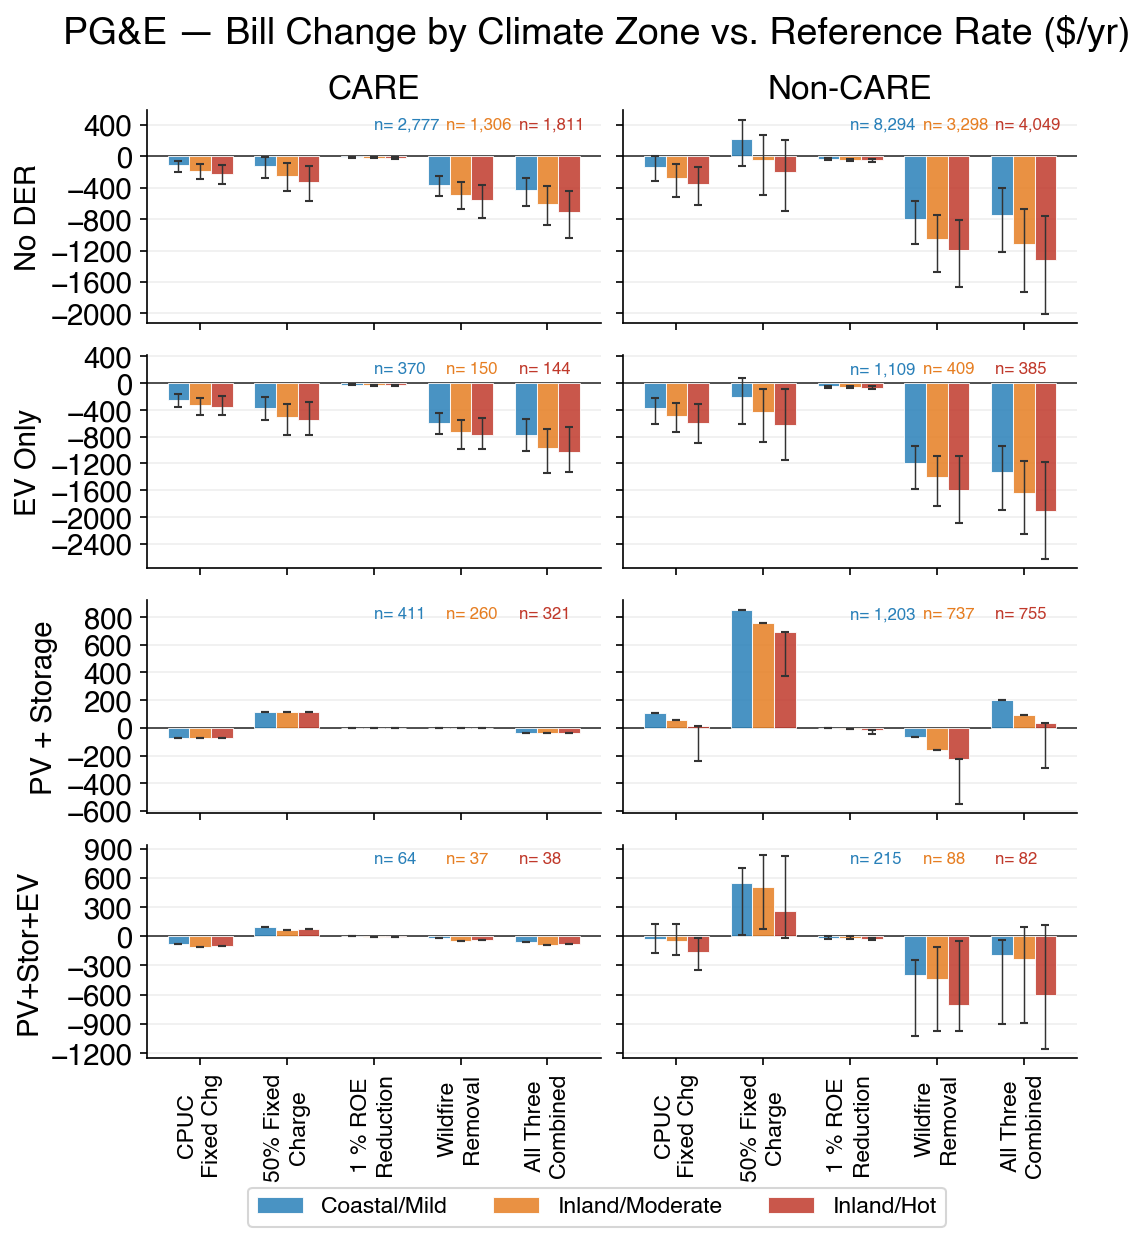

In [172]:
# ── PG&E: Bill change ($/yr) by climate zone — 4x2 (CARE vs Non-CARE) ──
df = p
mb = 147
sq_base = 'e_tou_c_bill'
sqf_base = 'e_tou_c_f_bill'

rate_defs_cz = [
    ('CPUC\nFixed Chg', 'sqf',           False),
        ('50% Fixed\nCharge',  'F50_WF0_ROE0',  False),
    ('1 % ROE\nReduction',     'F0_WF0_ROE1.0', True),
    ('Wildfire\nRemoval',  'F0_WF1_ROE0',   True),
    ('All Three\nCombined','F50_WF1_ROE1.0', False),
]

zc = {'Coastal/Mild': '#2980b9', 'Inland/Moderate': '#e67e22', 'Inland/Hot': '#c0392b'}
available_zones = [z for z in zc if z in df.zone.unique()]

panels = [
    ('No DER',       ''),
    ('EV Only',      '_s1_ev'),
    ('PV + Storage', '_s2_pv_stor'),
    ('PV+Stor+EV',   '_s3_pv_stor_ev'),
]

n_rates = len(rate_defs_cz)
n_zones = len(available_zones)
x = np.arange(n_rates)
w = 0.25

fig, axes = plt.subplots(4, 2, figsize=(8, 2.*4), gridspec_kw={'wspace': 0.05, 'hspace': 0.15})

for ti, (ttl, sfx) in enumerate(panels):
    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ti, ci]
        sq_col = f'{sq_base}{sfx}'
        sqf_col = f'{sqf_base}{sfx}'

        if sq_col not in df.columns:
            ax.set_visible(False); continue

        sub = df[df[sq_col].notna()]
        sq_floored = sub[sq_col].clip(lower=mb)

        for zi, z in enumerate(available_zones):
            mask = (sub.zone == z) & (sub.care_group == cg)
            sq_z = sq_floored[mask]
            nv = mask.sum()
            offset = (zi - (n_zones - 1) / 2) * w

            vs, elo, ehi = [], [], []
            for rlabel, rkey, apply_floor in rate_defs_cz:
                bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill{sfx}'
                if bill_col not in sub.columns:
                    vs.append(0); elo.append(0); ehi.append(0); continue
                new_bills = sub.loc[mask, bill_col].copy()
                if apply_floor:
                    new_bills = new_bills.clip(lower=mb)
                d = (new_bills - sq_z).dropna()
                vs.append(d.mean())
                elo.append(d.median() - d.quantile(0.25))
                ehi.append(d.quantile(0.75) - d.median())

            bars = ax.bar(x + offset, vs, width=w, color=zc[z], alpha=0.85,
                          edgecolor='white', linewidth=0.5, zorder=3)
            ax.errorbar(x + offset, vs, yerr=[elo, ehi],
                        fmt='none', color='#333', capsize=2, linewidth=0.7, zorder=4)

        ax.axhline(0, color='#333', lw=0.8, zorder=2)
        ax.grid(axis='x', visible=False); ax.grid(axis='y', alpha=0.2)

        if ci == 0:
            ax.set_ylabel(ttl, fontsize=14, fontweight='bold')
        else:
            ax.tick_params(labelleft=False)

        if ti == 0:
            ax.set_title(cg, fontsize=16, fontweight='bold')

        # Color-coded adoption % by climate zone
        x_pos = 0.5
        for z in available_zones:
            n = ((sub.zone == z) & (sub.care_group == cg)).sum()
            ax.text(x_pos, 0.97, f'n={n: ,}', transform=ax.transAxes,
                    ha='left', va='top', fontsize=8, color=zc[z], fontweight='bold')
            x_pos += 0.16
        if ti == len(panels) - 1:
            ax.set_xticks(x)
            ax.set_xticklabels([r[0] for r in rate_defs_cz], fontsize=11, rotation=90)
        else:
            ax.set_xticks(x); ax.set_xticklabels([])

        from matplotlib.ticker import MaxNLocator
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))

# Shared y-limits per row
for ti in range(len(panels)):
    ymin = min(axes[ti, 0].get_ylim()[0], axes[ti, 1].get_ylim()[0])
    ymax = max(axes[ti, 0].get_ylim()[1], axes[ti, 1].get_ylim()[1])
    ymax = max(ymax, abs(ymin) * 0.15, 20)
    for ci in range(2):
        axes[ti, ci].set_ylim(ymin, ymax)

# Shared legend at bottom
import matplotlib.patches as mpatches
zone_patches = [mpatches.Patch(facecolor=zc[z], label=z, alpha=0.85,
                                edgecolor='white', linewidth=0.5)
                for z in available_zones]
fig.legend(handles=zone_patches, loc='lower center', ncol=3,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.04))
fig.subplots_adjust(top=0.9)
fig.suptitle('PG&E — Bill Change by Climate Zone vs. Reference Rate ($/yr)',
             fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('pge_cz.pdf', dpi=600, bbox_inches='tight')
plt.show()

SCE households with zone assignment: 19,863
zone
Coastal/Mild       8834
Inland/Moderate    8133
Inland/Hot         2896
Name: count, dtype: int64


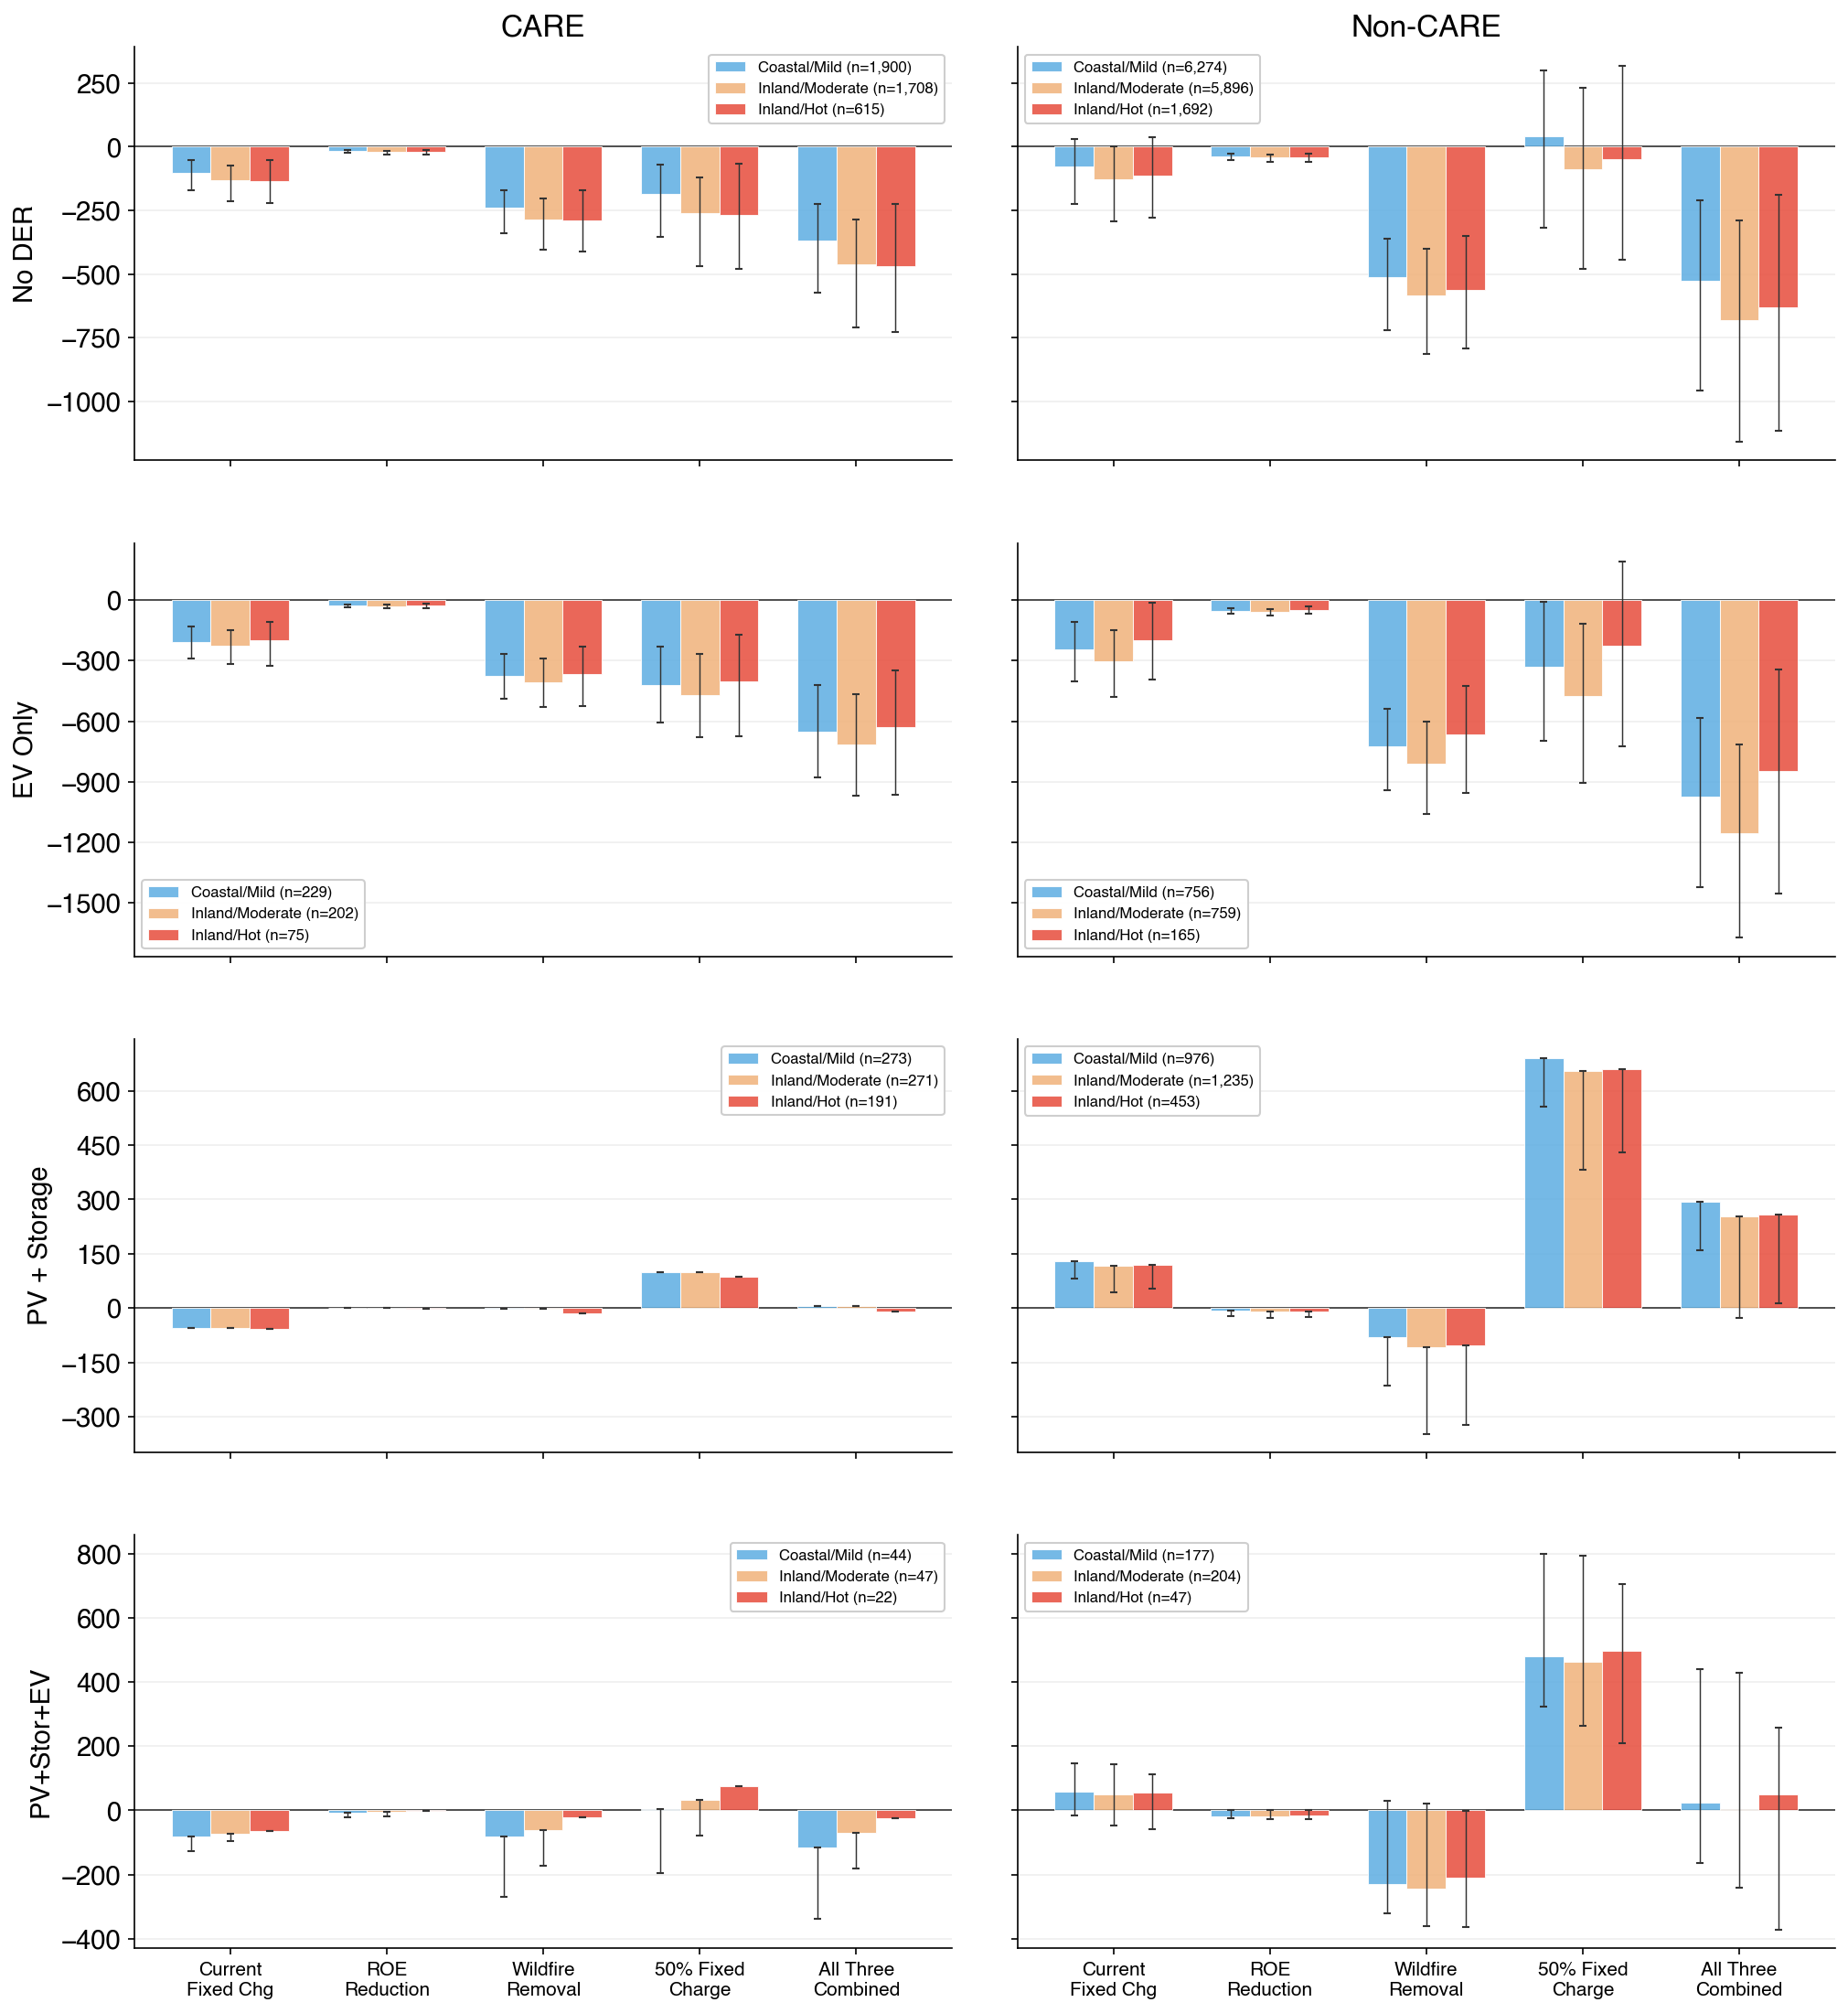

In [130]:
# ── SCE Climate Zone Mapping (CEC climate zones) ──
sce_coastal = [5, 6, 8, 16] #5 is santa maria, 6 is LA, 8 is Laguna Beach
sce_inland_hot = [13, 14, 15] #13 Fresno, 14 Palmdale, 15 Brawley
sce_inland_mild = [9, 10] # 9 Pasadena, 10 Riverside, 16 mount shashta

s = dfs['SCE'].copy()
s['zone'] = s['cec_cz'].apply(
    lambda z: 'Coastal/Mild' if z in sce_coastal
    else ('Inland/Hot' if z in sce_inland_hot
          else ('Inland/Moderate' if z in sce_inland_mild else None)))
s = s[s.zone.notna()]
print(f'SCE households with zone assignment: {len(s):,}')
print(s.zone.value_counts())

# ── SCE: Bill change ($/yr) by climate zone — 4x2 (CARE vs Non-CARE) ──
df = s
mb = 126
sq_base = 'tou_d_4_9_bill'
sqf_base = 'tou_d_4_9_f_bill'
rate_defs_cz = [
    ('Current\nFixed Chg', 'sqf',           False),
    ('ROE\nReduction',     'F0_WF0_ROE1.0', True),
    ('Wildfire\nRemoval',  'F0_WF1_ROE0',   True),
    ('50% Fixed\nCharge',  'F50_WF0_ROE0',  False),
    ('All Three\nCombined','F50_WF1_ROE1.0', False),
]
zc = {'Coastal/Mild': '#5dade2', 'Inland/Moderate': '#f0b27a', 'Inland/Hot': '#e74c3c'}
available_zones = [z for z in zc if z in df.zone.unique()]
panels = [
    ('No DER',       ''),
    ('EV Only',      '_s1_ev'),
    ('PV + Storage', '_s2_pv_stor'),
    ('PV+Stor+EV',   '_s3_pv_ev_stor'),  # SCE uses different suffix
]
n_rates = len(rate_defs_cz)
n_zones = len(available_zones)
x = np.arange(n_rates)
w = 0.25
fig, axes = plt.subplots(4, 2, figsize=(16, 18), gridspec_kw={'wspace': 0.08})
for ti, (ttl, sfx) in enumerate(panels):
    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ti, ci]
        sq_col = f'{sq_base}{sfx}'
        sqf_col = f'{sqf_base}{sfx}'
        if sq_col not in df.columns:
            ax.set_visible(False); continue
        sub = df[df[sq_col].notna()]
        sq_floored = sub[sq_col].clip(lower=mb)
        for zi, z in enumerate(available_zones):
            mask = (sub.zone == z) & (sub.care_group == cg)
            sq_z = sq_floored[mask]
            nv = mask.sum()
            offset = (zi - (n_zones - 1) / 2) * w
            vs, elo, ehi = [], [], []
            for rlabel, rkey, apply_floor in rate_defs_cz:
                bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill{sfx}'
                if bill_col not in sub.columns:
                    vs.append(0); elo.append(0); ehi.append(0); continue
                new_bills = sub.loc[mask, bill_col].copy()
                if apply_floor:
                    new_bills = new_bills.clip(lower=mb)
                d = (new_bills - sq_z).dropna()
                vs.append(d.mean())
                elo.append(d.median() - d.quantile(0.25))
                ehi.append(d.quantile(0.75) - d.median())
            bars = ax.bar(x + offset, vs, width=w, color=zc[z], alpha=0.85,
                          label=f'{z} (n={nv:,})',
                          edgecolor='white', linewidth=0.5, zorder=3)
            ax.errorbar(x + offset, vs, yerr=[elo, ehi],
                        fmt='none', color='#333', capsize=2, linewidth=0.7, zorder=4)
        ax.axhline(0, color='#333', lw=0.8, zorder=2)
        ax.grid(axis='x', visible=False); ax.grid(axis='y', alpha=0.2)
        if ci == 0:
            ax.set_ylabel(ttl, fontsize=14, fontweight='bold')
        else:
            ax.tick_params(labelleft=False)
        if ti == 0:
            ax.set_title(cg, fontsize=16, fontweight='bold')
        ax.legend(fontsize=8, framealpha=0.95, loc='best')
        if ti == len(panels) - 1:
            ax.set_xticks(x)
            ax.set_xticklabels([r[0] for r in rate_defs_cz], fontsize=10)
        else:
            ax.set_xticks(x); ax.set_xticklabels([])
        from matplotlib.ticker import MaxNLocator
        ax.yaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
# Shared y-limits per row
for ti in range(len(panels)):
    ylims = [axes[ti, c].get_ylim() for c in range(2) if axes[ti, c].get_visible()]
    if not ylims: continue
    ymin = min(y[0] for y in ylims)
    ymax = max(y[1] for y in ylims)
    ymax = max(ymax, abs(ymin) * 0.15, 20)
    for ci in range(2):
        if axes[ti, ci].get_visible():
            axes[ti, ci].set_ylim(ymin, ymax)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

         county county_fips care_group     n  50% Fixed Charge  All Three Combined
0       Alameda       06001       CARE   613       -121.831921         -428.260003
1       Alameda       06001   Non-CARE  1830        243.727524         -708.609917
2         Butte       06007       CARE    98       -258.259918         -618.246776
3         Butte       06007   Non-CARE   305        -69.629537        -1143.659748
4        Colusa       06011       CARE    69       -277.048274         -644.333735
5        Colusa       06011   Non-CARE   157        -86.202658        -1166.732311
6  Contra Costa       06013       CARE   479       -256.926330         -616.264037
7  Contra Costa       06013   Non-CARE  1200         -0.790540        -1048.012772
8     El Dorado       06017       CARE   103       -197.920140         -534.464191
9     El Dorado       06017   Non-CARE   263       -209.728990        -1338.223614


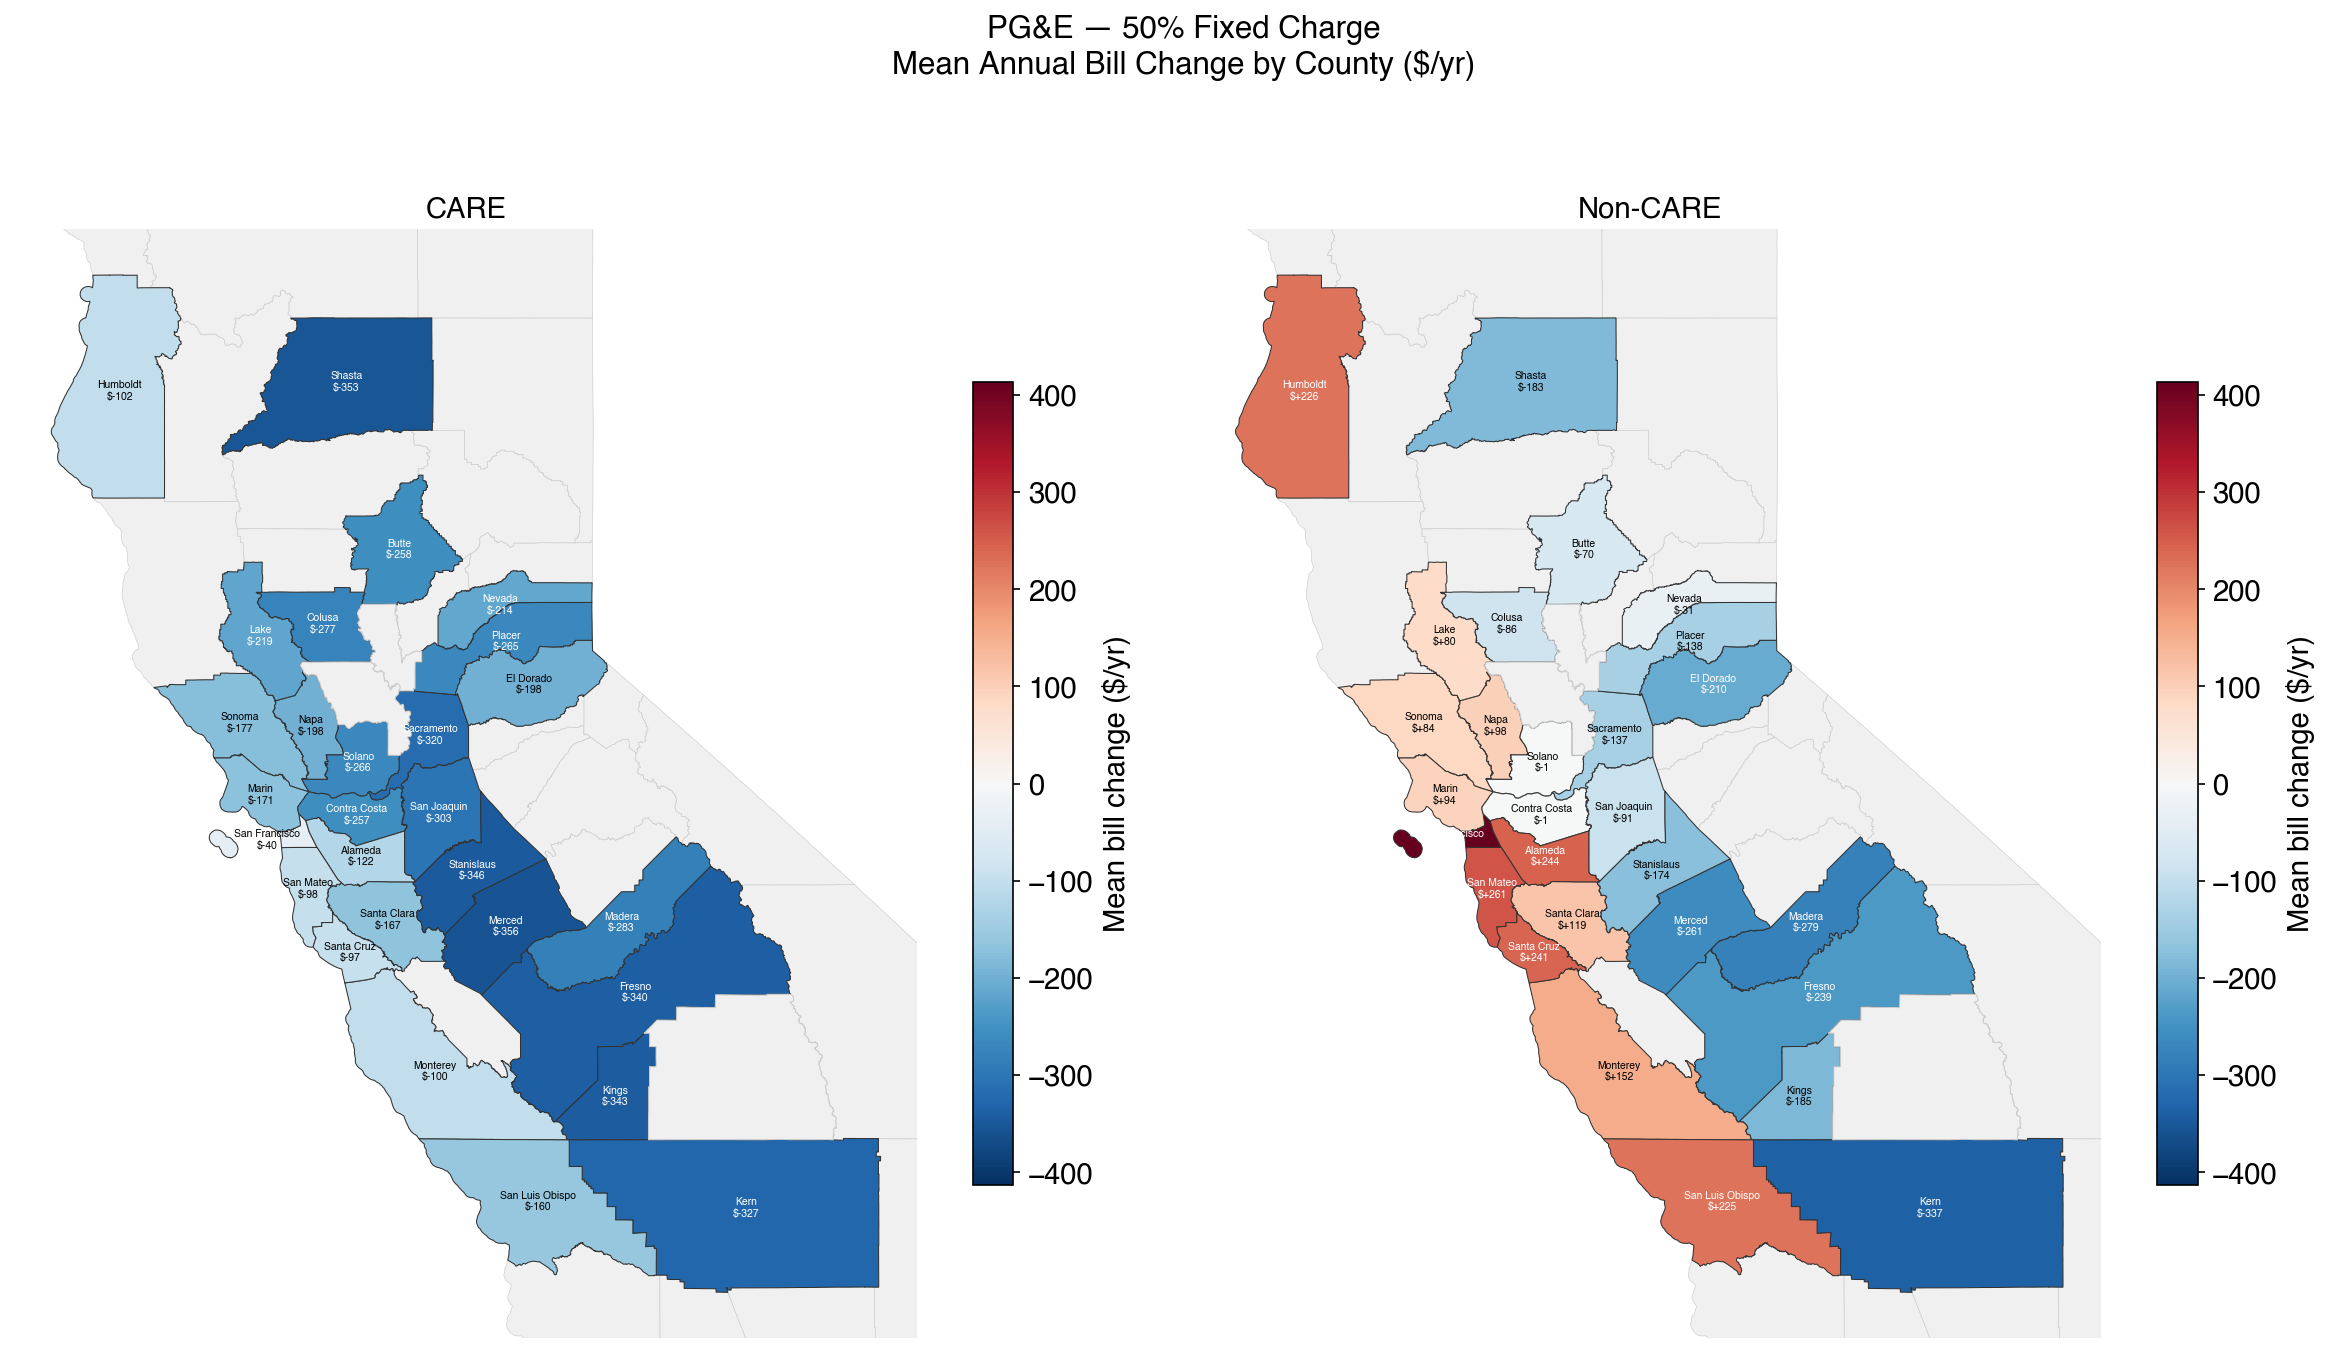

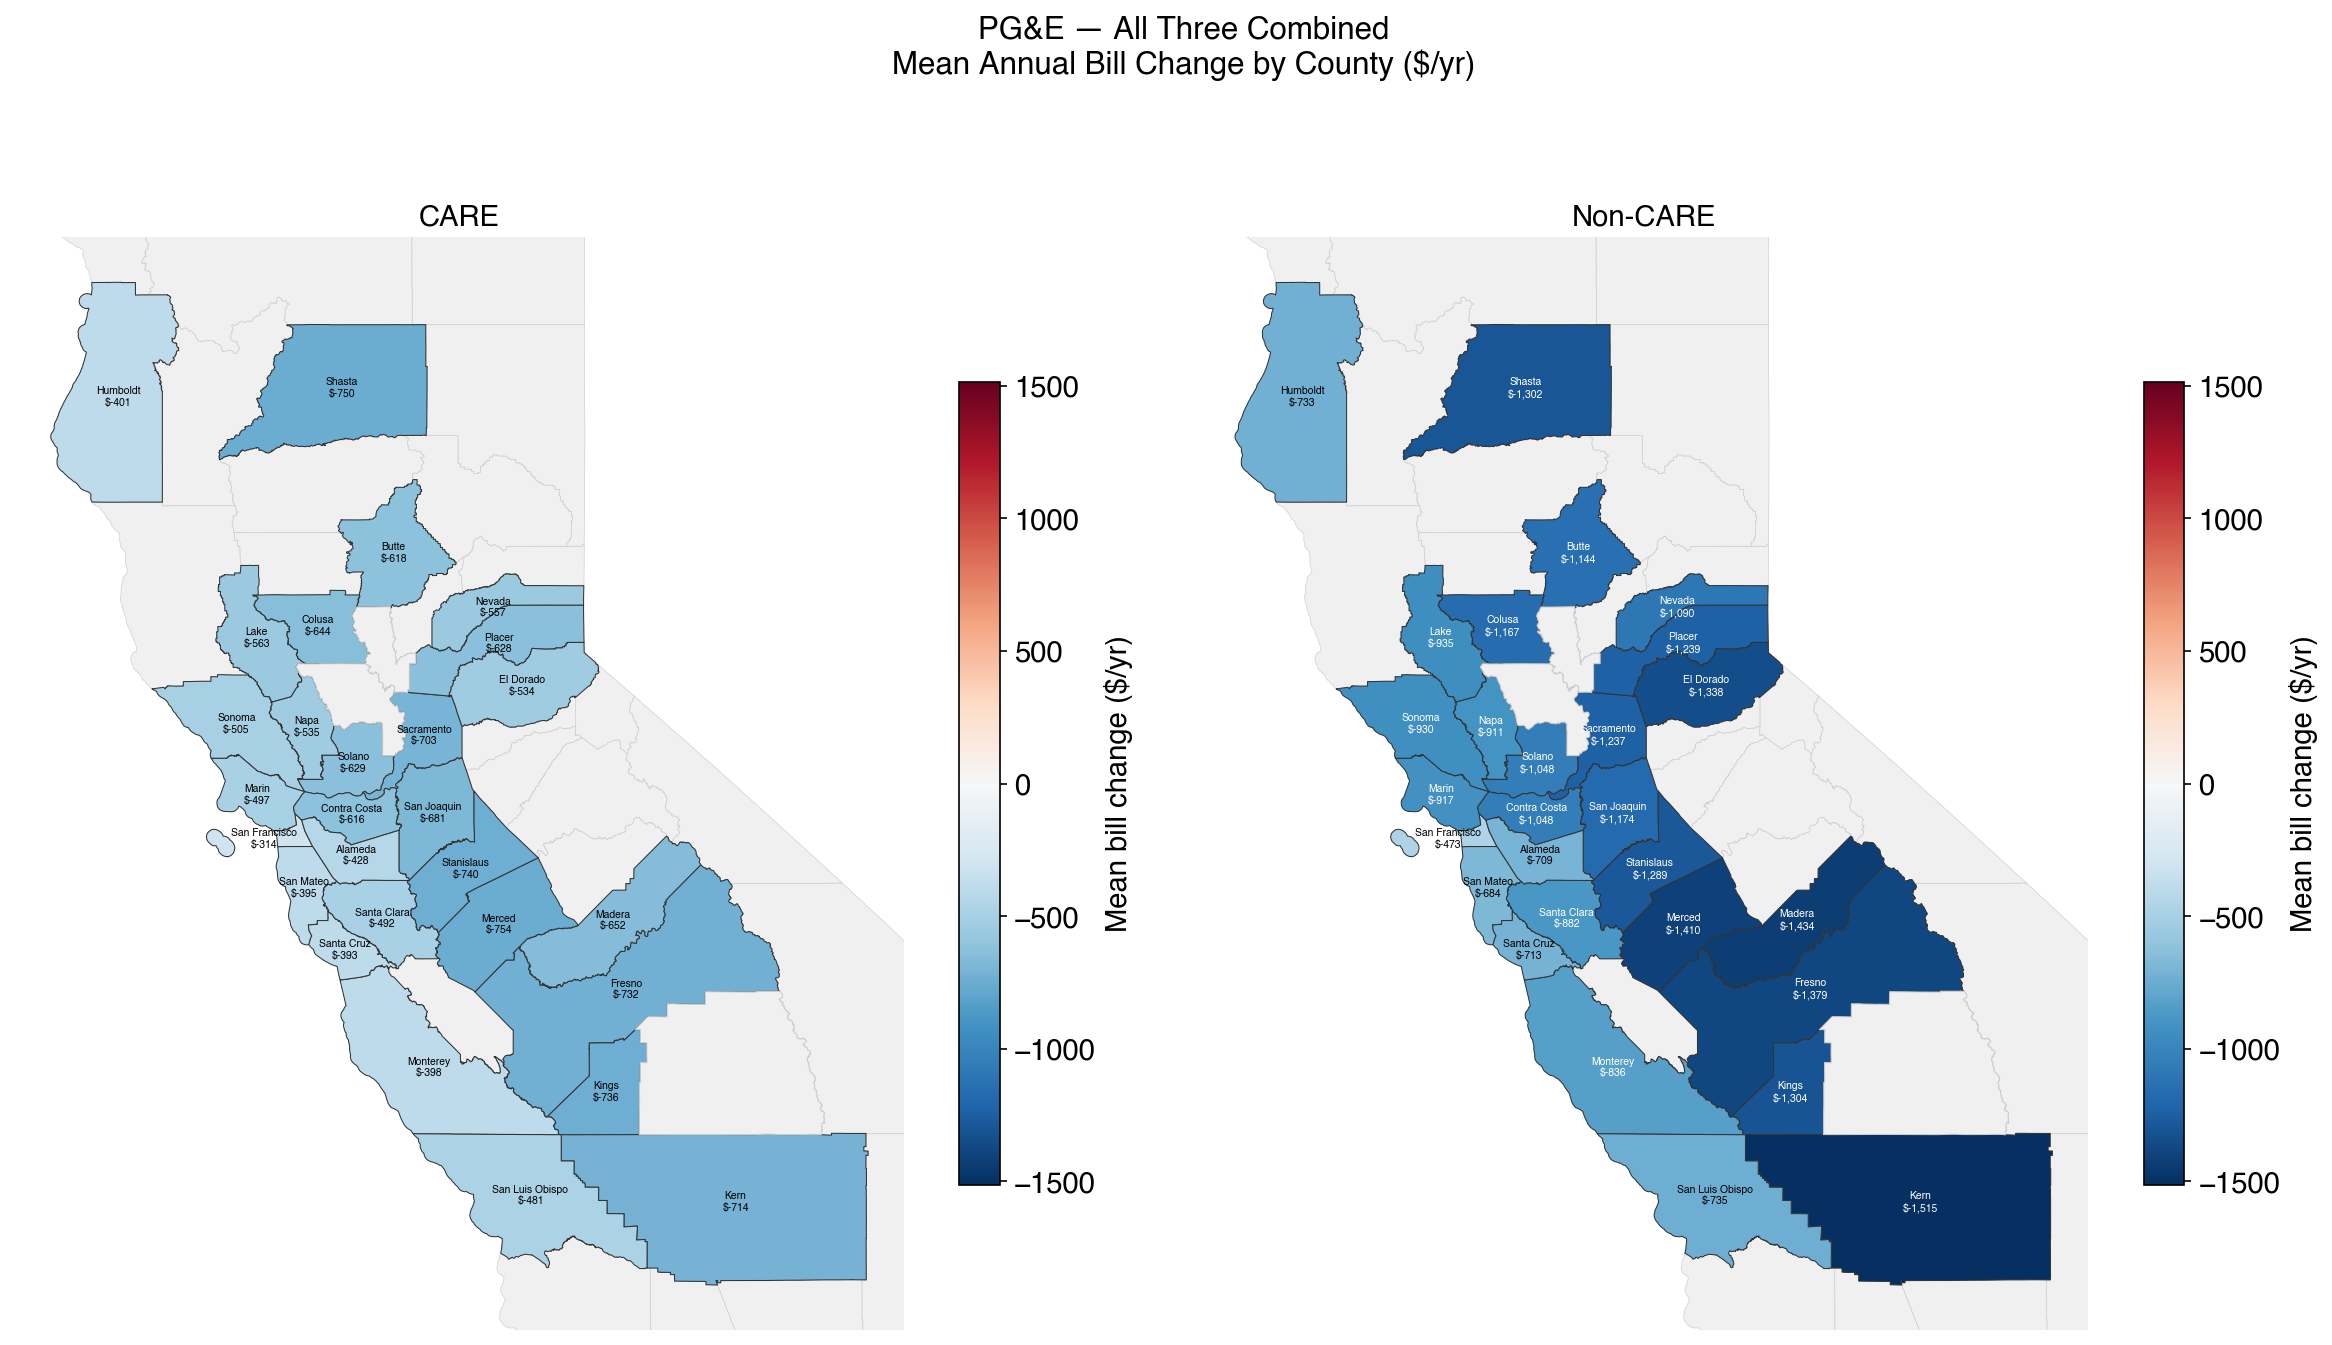

Choropleth maps created successfully


In [131]:
# =============================================
# PG&E County-Level Bill Change Maps
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm

# ── Load and prep data ──
df = pd.read_csv('post_adoption_bills_pge.csv')
df['care_group'] = df['is_care'].map({True: 'CARE', False: 'Non-CARE'})

fips = {
    1: 'Alameda', 7: 'Butte', 11: 'Colusa', 13: 'Contra Costa',
    17: 'El Dorado', 19: 'Fresno', 23: 'Humboldt', 29: 'Kern',
    31: 'Kings', 33: 'Lake', 39: 'Madera', 41: 'Marin',
    47: 'Merced', 53: 'Monterey', 55: 'Napa', 57: 'Nevada',
    61: 'Placer', 67: 'Sacramento', 75: 'San Francisco',
    77: 'San Joaquin', 79: 'San Luis Obispo', 81: 'San Mateo',
    85: 'Santa Clara', 87: 'Santa Cruz', 89: 'Shasta', 95: 'Solano',
    97: 'Sonoma', 99: 'Stanislaus', 101: 'Sutter', 107: 'Tulare',
    113: 'Yolo',
}
# FIPS code for geopandas merge (California = 06, then 3-digit county)
fips_full = {k: f'06{k:03d}' for k in fips}

df['county'] = df['puma'].str[4:7].astype(int).map(fips)
df['county_fips'] = df['puma'].str[4:7].astype(int).map(fips_full)
df = df[df.county.notna()]

mb = 147
sq_floored = df['e_tou_c_bill'].clip(lower=mb)

scenarios = [
    ('50% Fixed Charge',   'F50_WF0_ROE0_bill',  False),
    ('All Three Combined', 'F50_WF1_ROE1.0_bill', False),
]

# ── Compute county-level mean bill change ──
results = []
for county, cfips in zip(fips.values(), fips_full.values()):
    for cg in ['CARE', 'Non-CARE']:
        mask = (df.county == county) & (df.care_group == cg)
        n = mask.sum()
        if n < 10: continue
        row = {'county': county, 'county_fips': cfips, 'care_group': cg, 'n': n}
        for slabel, scol, apply_floor in scenarios:
            if scol not in df.columns: continue
            new_bills = df.loc[mask, scol].copy()
            chg = (new_bills - sq_floored[mask]).dropna()
            row[slabel] = chg.mean()
        results.append(row)

county_stats = pd.DataFrame(results)
print(county_stats.head(10).to_string())


# =============================================
# VERSION 1: Choropleth map (needs geopandas + internet)
# =============================================
try:
    import geopandas as gpd

    # Download CA counties (only needed once)
    ca_counties = gpd.read_file(
        'https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip'
    )
    ca_counties = ca_counties[ca_counties.STATEFP == '06']
    ca_counties = ca_counties.rename(columns={'GEOID': 'county_fips'})

    for slabel, _, _ in scenarios:
        fig, axes = plt.subplots(1, 2, figsize=(16, 10))
        for ci, cg in enumerate(['CARE', 'Non-CARE']):
            ax = axes[ci]
            sub = county_stats[county_stats.care_group == cg]
            merged = ca_counties.merge(sub[['county_fips', slabel, 'n']],
                                        on='county_fips', how='left')

            # Only plot PG&E counties
            pge_fips = list(fips_full.values())
            pge_counties = merged[merged.county_fips.isin(pge_fips)]
            other = merged[~merged.county_fips.isin(pge_fips)]

            # Background (non-PGE counties in light gray)
            other.plot(ax=ax, color='#f0f0f0', edgecolor='#ccc', linewidth=0.3)

            # PG&E counties colored by bill change
            vmax = max(county_stats[slabel].abs().max(), 1)
            norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

            pge_counties.plot(ax=ax, column=slabel, cmap='RdBu_r', norm=norm,
                              edgecolor='#333', linewidth=0.5, legend=False,
                              missing_kwds={'color': '#f0f0f0', 'edgecolor': '#ccc'})

            # County labels
            for _, row in pge_counties.iterrows():
                if pd.notna(row[slabel]):
                    centroid = row.geometry.centroid
                    ax.annotate(f'{row["NAME"]}\n${row[slabel]:+,.0f}',
                                xy=(centroid.x, centroid.y), ha='center', va='center',
                                fontsize=5, fontweight='bold',
                                color='white' if abs(row[slabel]) > vmax*0.5 else 'black')

            # Zoom to PG&E territory
            bounds = pge_counties.total_bounds
            ax.set_xlim(bounds[0]-0.3, bounds[2]+0.3)
            ax.set_ylim(bounds[1]-0.3, bounds[3]+0.3)
            ax.set_title(cg, fontsize=14, fontweight='bold')
            ax.axis('off')

            # Colorbar
            sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
            sm.set_array([])
            plt.colorbar(sm, ax=ax, label='Mean bill change ($/yr)', shrink=0.6)

        fig.suptitle(f'PG&E — {slabel}\nMean Annual Bill Change by County ($/yr)',
                     fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

    print('Choropleth maps created successfully')

except Exception as e:
    print(f'Choropleth failed ({e}), falling back to bubble map')


    # =============================================
    # VERSION 2: Bubble map fallback (no shapefiles needed)
    # =============================================
    county_coords = {
        'Alameda': (37.65, -121.89), 'Butte': (39.67, -121.60),
        'Colusa': (39.18, -122.24), 'Contra Costa': (37.92, -121.95),
        'El Dorado': (38.78, -120.52), 'Fresno': (36.76, -119.65),
        'Humboldt': (40.70, -123.87), 'Kern': (35.35, -118.73),
        'Kings': (36.07, -119.82), 'Lake': (39.10, -122.75),
        'Madera': (37.22, -119.76), 'Marin': (38.05, -122.74),
        'Merced': (37.19, -120.72), 'Monterey': (36.24, -121.31),
        'Napa': (38.50, -122.33), 'Nevada': (39.30, -120.77),
        'Placer': (39.06, -120.72), 'Sacramento': (38.45, -121.35),
        'San Francisco': (37.76, -122.44), 'San Joaquin': (37.93, -121.27),
        'San Luis Obispo': (35.38, -120.45), 'San Mateo': (37.43, -122.35),
        'Santa Clara': (37.23, -121.70), 'Santa Cruz': (37.03, -122.01),
        'Shasta': (40.76, -122.04), 'Solano': (38.27, -121.94),
        'Sonoma': (38.52, -122.94), 'Stanislaus': (37.56, -120.99),
        'Sutter': (39.03, -121.69), 'Tulare': (36.23, -118.78),
        'Yolo': (38.69, -121.90),
    }

    for slabel, _, _ in scenarios:
        fig, axes = plt.subplots(1, 2, figsize=(14, 12))
        for ci, cg in enumerate(['CARE', 'Non-CARE']):
            ax = axes[ci]
            sub = county_stats[(county_stats.care_group == cg) & county_stats[slabel].notna()]

            vmax = max(county_stats[slabel].abs().max(), 1)
            norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
            cmap = cm.RdBu_r

            for _, row in sub.iterrows():
                if row['county'] not in county_coords: continue
                lat, lon = county_coords[row['county']]
                val = row[slabel]
                color = cmap(norm(val))
                size = max(row['n'] / 10, 30)

                ax.scatter(lon, lat, s=size, c=[color], edgecolors='#333',
                           linewidth=0.5, zorder=3)
                ax.annotate(f'{row["county"]}\n${val:+,.0f}',
                            xy=(lon, lat), ha='center', va='top',
                            fontsize=7, fontweight='bold', color='#333',
                            xytext=(0, -8), textcoords='offset points', zorder=4)

            ax.set_title(cg, fontsize=14, fontweight='bold')
            ax.set_xlabel('Longitude')
            ax.set_ylabel('Latitude')
            ax.grid(alpha=0.2)
            ax.set_aspect('equal')

            # Colorbar
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            plt.colorbar(sm, ax=ax, label='Mean bill change ($/yr)', shrink=0.6)

        fig.suptitle(f'PG&E — {slabel}\nMean Annual Bill Change by County ($/yr)\n'
                     f'(Bubble size = sample count)',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

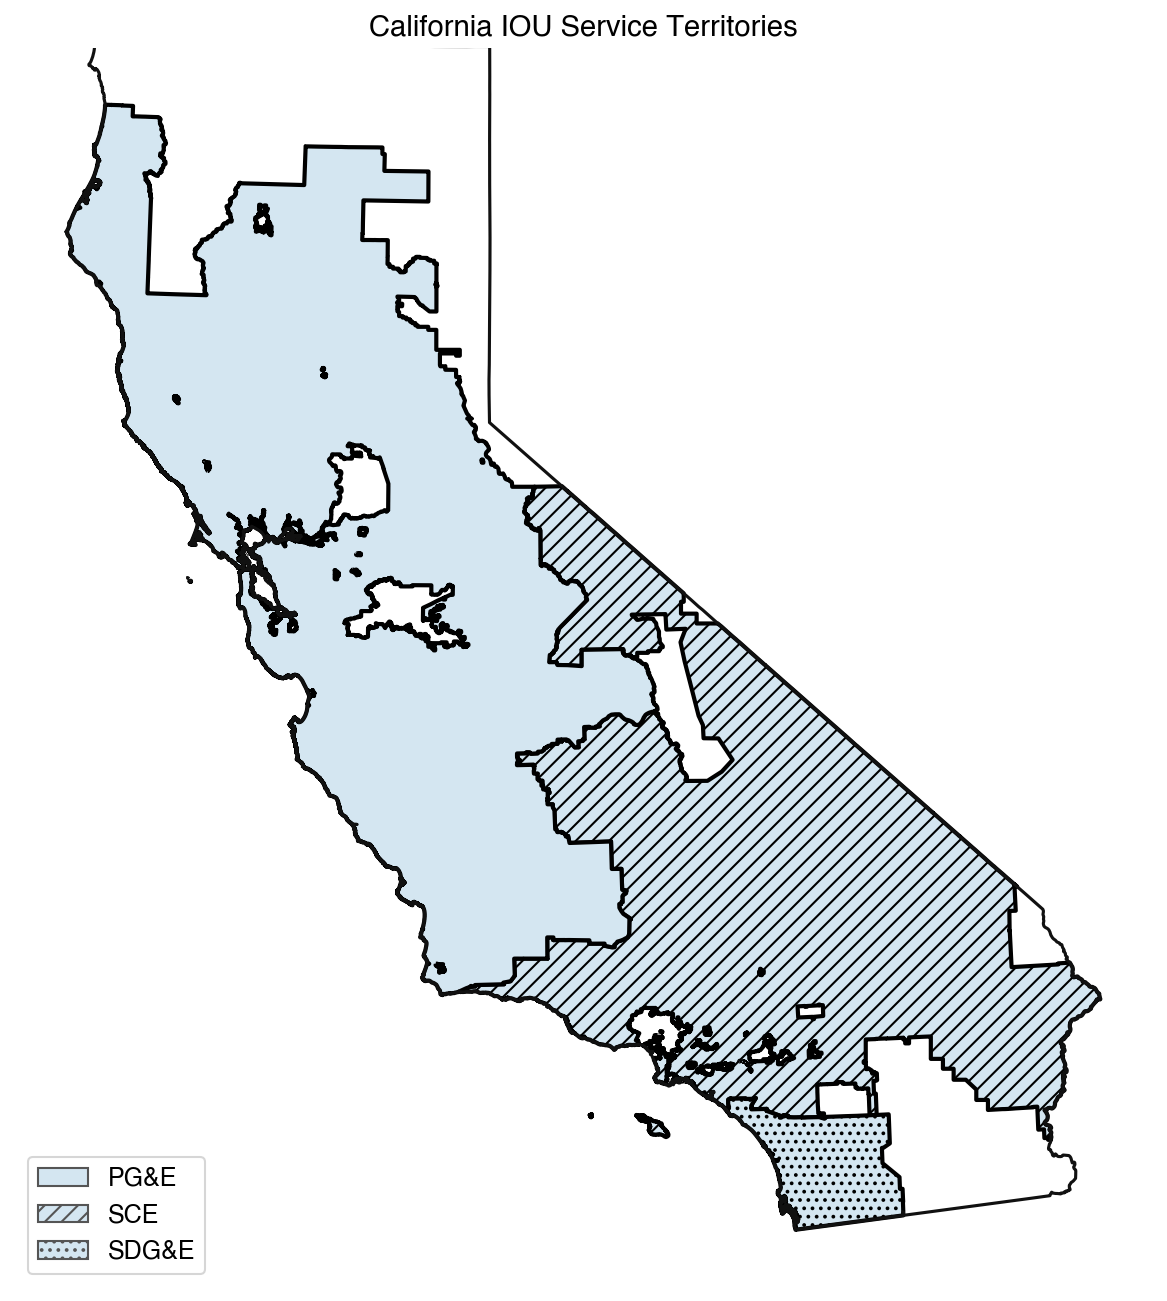

In [24]:
# ── IOU Territory Reference Map ──
fig, ax = plt.subplots(figsize=(8, 10))

iou_styles = {
    'PG&E':  {'color': '#d4e6f1', 'hatch': '',    'label': 'PG&E'},
    'SCE':   {'color': '#d4e6f1', 'hatch': '///',  'label': 'SCE'},
    'SDG&E': {'color': '#d4e6f1', 'hatch': '...',  'label': 'SDG&E'},
}

for _, row in iou3.iterrows():
    style = iou_styles[row.iou]
    gpd.GeoSeries([row.geometry], crs=iou3.crs).plot(
        ax=ax, color=style['color'], edgecolor='black',
        linewidth=2, hatch=style['hatch'], zorder=2)

# CA border
draw_border(fig)

# Legend
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(facecolor=s['color'], hatch=s['hatch'],
                                  edgecolor='#555', label=s['label'])
                  for s in iou_styles.values()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=12, frameon=True)

ax.set_title('California IOU Service Territories', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# CZ × IOU Maps — COMPLETE FINAL CODE
# =============================================
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize
from shapely.ops import unary_union

# ── 1. Load and intersect shapefiles ──
cz = gpd.read_file('BuildingClimateZones_CEC_2015/Building_Climate_Zones.shp')
iou = gpd.read_file('ElectricLoadServingEntities_IOU_POU/ElectricLoadServingEntities_IOU_POU.shp')

iou3 = iou[iou.Acronym.isin(['PG&E', 'SCE', 'SDG&E'])][['Acronym', 'geometry']].copy()
iou3 = iou3.rename(columns={'Acronym': 'iou'})
iou3 = iou3.to_crs(cz.crs)

cz_iou = gpd.overlay(cz[['BZone', 'geometry']], iou3, how='intersection')
cz_iou = cz_iou.rename(columns={'BZone': 'cec_cz'})
cz_iou['cec_cz'] = cz_iou['cec_cz'].astype(str)
cz_iou['area_sqm'] = cz_iou.geometry.area

ca_poly = unary_union(cz.geometry)

def draw_border(fig):
    for ax in fig.axes:
        try:
            xlim, ylim = ax.get_xlim(), ax.get_ylim()
            for geom in ca_poly.geoms:
                xs, ys = geom.exterior.coords.xy
                ax.plot(xs, ys, color='#111', linewidth=1.5, zorder=10)
            ax.set_xlim(xlim); ax.set_ylim(ylim)
        except:
            pass


# California state outline (clean outer boundary only)
ca_outline = gpd.GeoSeries([unary_union(cz.geometry)], crs=cz.crs)

print(f'CZ × IOU intersection: {len(cz_iou)} polygons')

# ── 2. Load bill data + assign CZ from parquet ──
pge = pd.read_csv('post_adoption_bills_pge.csv')
sce = pd.read_csv('post_adoption_bills_sce.csv')
sdge = pd.read_csv('post_adoption_bills_sdge.csv')

for d in [pge, sce, sdge]:
    d['care_group'] = d['is_care'].map({True: 'CARE', False: 'Non-CARE'})
    if 'cec_cz' in d.columns:
        d.drop(columns='cec_cz', inplace=True)

meta = pd.read_parquet('CA_baseline_tmy_metadata_and_annual_results.parquet',
                        columns=['in.cec_climate_zone'])
meta = meta.reset_index().rename(columns={'bldg_id': 'building_id',
                                           'in.cec_climate_zone': 'cec_cz'})

pge  = pge.merge(meta[['building_id', 'cec_cz']], on='building_id', how='left')
sce  = sce.merge(meta[['building_id', 'cec_cz']], on='building_id', how='left')
sdge = sdge.merge(meta[['building_id', 'cec_cz']], on='building_id', how='left')

pge['iou'] = 'PG&E'
sce['iou'] = 'SCE'
sdge['iou'] = 'SDG&E'

print(f'PGE matched: {pge.cec_cz.notna().sum()}/{len(pge)}, CZs: {sorted(pge.cec_cz.dropna().unique())}')
print(f'SCE matched: {sce.cec_cz.notna().sum()}/{len(sce)}, CZs: {sorted(sce.cec_cz.dropna().unique())}')
print(f'SDGE matched: {sdge.cec_cz.notna().sum()}/{len(sdge)}, CZs: {sorted(sdge.cec_cz.dropna().unique())}')

# ── 3. Config ──
iou_configs = {
    'PG&E':  {'df': pge, 'sq': 'e_tou_c_bill', 'sqf': 'e_tou_c_f_bill',
              'mb': 147, 's3': '_s3_pv_stor_ev'},
    'SCE':   {'df': sce, 'sq': 'tou_d_4_9_bill', 'sqf': 'tou_d_4_9_f_bill',
              'mb': 126, 's3': '_s3_pv_ev_stor'},
    'SDG&E': {'df': sdge, 'sq': 'tou_dr_bill', 'sqf': 'tou_dr_f_bill',
              'mb': 147, 's3': '_s3_pv_stor_ev'},
}

tech_scenarios = [
    ('No DER',       ''),
    ('EV Only',      '_s1_ev'),
    ('PV + Storage', '_s2_pv_stor'),
    ('PV+Stor+EV',   's3_placeholder'),
]

reform_defs = [
    ('Current Fixed Chg', 'sqf',           False),
    ('50% Fixed Charge',  'F50_WF0_ROE0',  False),
    ('Wildfire Removal',  'F0_WF1_ROE0',   True),
    ('ROE Reduction',     'F0_WF0_ROE1.0', True),
    ('All Three Combined','F50_WF1_ROE1.0', False),
]

# ── 4. Compute CZ-level stats ──
def compute_cz_stats(cfg, sfx, iou_name):
    df = cfg['df']; mb = cfg['mb']
    sq_col = f'{cfg["sq"]}{sfx}'
    sqf_col = f'{cfg["sqf"]}{sfx}'
    if sq_col not in df.columns: return pd.DataFrame()
    sub = df[df[sq_col].notna() & df['cec_cz'].notna()].copy()
    sq_f = sub[sq_col].clip(lower=mb)
    rows = []
    for cz_val in sub.cec_cz.unique():
        for cg in ['CARE', 'Non-CARE']:
            mask = (sub.cec_cz == cz_val) & (sub.care_group == cg)
            n = mask.sum()
            if n < 5: continue
            row = {'cec_cz': str(cz_val), 'care_group': cg, 'n': n, 'iou': iou_name,
                   'ref_bill': sq_f[mask].mean()}
            for rlabel, rkey, apply_floor in reform_defs:
                bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill{sfx}'
                if bill_col not in sub.columns: row[rlabel] = np.nan; continue
                nb = sub.loc[mask, bill_col].copy()
                if apply_floor: nb = nb.clip(lower=mb)
                row[rlabel] = (nb - sq_f[mask]).dropna().mean()
            rows.append(row)
    return pd.DataFrame(rows)

# ── 5. Plot function ──
def plot_cz_map(ax, cz_iou, stats, col, cmap, norm, title, ca_outline, is_diff=True):
    merged = cz_iou.merge(stats[['cec_cz', 'iou', col]],
                           on=['cec_cz', 'iou'], how='left')
    merged.plot(ax=ax, column=col, cmap=cmap, norm=norm, edgecolor='#555',
                linewidth=0.5, legend=False, zorder=2,
                missing_kwds={'color': '#e8e8e8', 'edgecolor': '#ccc'})
    # CA state outline on top
    ca_outline.boundary.plot(ax=ax, color='none', edgecolor='#111', linewidth=1.5, zorder=10)
    # # Annotations (uncomment to show CZ labels)
    # for _, row in merged.iterrows():
    #     if pd.notna(row.get(col)):
    #         c = row.geometry.centroid
    #         fmt = f'${row[col]:+,.0f}' if is_diff else f'${row[col]:,.0f}'
    #         ax.annotate(f'CZ{row["cec_cz"]}\n{fmt}', xy=(c.x, c.y),
    #                     ha='center', va='center', fontsize=6, fontweight='bold',
    #                     color='white' if abs(row[col]) > norm.vmax * 0.5 else 'black',
    #                     bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.6),
    #                     zorder=11)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')

# ── 6. Generate all maps ──
for ti, (tech_name, sfx_base) in enumerate(tech_scenarios):
    all_stats = []
    for iou_name, cfg in iou_configs.items():
        sfx = cfg['s3'] if tech_name == 'PV+Stor+EV' else sfx_base
        st = compute_cz_stats(cfg, sfx, iou_name)
        if not st.empty: all_stats.append(st)
    if not all_stats:
        print(f'No data for {tech_name}'); continue
    stats = pd.concat(all_stats, ignore_index=True)
    stats['cec_cz'] = stats['cec_cz'].astype(str)

    # ── MAP 1: Reference bills (absolute) ──
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ci]
        sub = stats[stats.care_group == cg]
        vmin, vmax = sub.ref_bill.min(), sub.ref_bill.max()
        norm = Normalize(vmin=vmin, vmax=vmax)
        plot_cz_map(ax, cz_iou, sub, 'ref_bill', 'YlOrRd', norm, cg, ca_outline, is_diff=False)
        sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
        sm.set_array([]); plt.colorbar(sm, ax=ax, label='$/yr', shrink=0.5)
    fig.suptitle(f'{tech_name} — Mean Reference TOU Bill by CZ ($/yr)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(); 
    # Draw CA border on every axis
    draw_border(fig)
    plt.show()

    # ── MAP 2: Reform differences ──
    n_reforms = len(reform_defs)
    fig, axes = plt.subplots(2, n_reforms, figsize=(4 * n_reforms, 10))
    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        sub = stats[stats.care_group == cg]
        for ri, (rlabel, _, _) in enumerate(reform_defs):
            ax = axes[ci, ri]
            if rlabel not in sub.columns or sub[rlabel].isna().all():
                ax.set_visible(False); continue
            vmax_abs = max(sub[rlabel].abs().max(), 1)
            norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0, vmax=vmax_abs)
            plot_cz_map(ax, cz_iou, sub, rlabel, 'RdBu_r', norm,
                        f'{cg}\n{rlabel}', ca_outline, is_diff=True)
            sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
            sm.set_array([]); plt.colorbar(sm, ax=ax, label='$/yr', shrink=0.4)
    fig.suptitle(f'{tech_name} — Mean Bill Change vs Reference TOU by CZ ($/yr)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); 
    draw_border(fig)
    plt.show()

print('All maps generated')

In [ ]:
# ── Compact maps: Reference + 3 reforms, shared colorbars ──
reform_subset = [
    ('CPUC Fixed Charge',   'sqf',           False),
    ('50% Fixed Charge',    'F50_WF0_ROE0',  False),
    ('All Three Combined',  'F50_WF1_ROE1.0', False),
]

for ti, (tech_name, sfx_base) in enumerate(tech_scenarios):
    all_stats = []
    for iou_name, cfg in iou_configs.items():
        sfx = cfg['s3'] if tech_name == 'PV+Stor+EV' else sfx_base
        st = compute_cz_stats(cfg, sfx, iou_name)
        if not st.empty: all_stats.append(st)
    if not all_stats:
        print(f'No data for {tech_name}'); continue
    stats = pd.concat(all_stats, ignore_index=True)
    stats['cec_cz'] = stats['cec_cz'].astype(str)

    # Shared color ranges across CARE + Non-CARE
    ref_vmin = stats['ref_bill'].min()
    ref_vmax = stats['ref_bill'].max()

    all_reform_vals = []
    for rlabel, _, _ in reform_subset:
        if rlabel in stats.columns:
            all_reform_vals.extend(stats[rlabel].dropna().values)
    vmax_shared = max(np.abs(all_reform_vals).max(), 1)

    # 2 rows × 4 columns
    fig, axes = plt.subplots(2, 4, figsize=(16, 7),
                              gridspec_kw={'wspace': 0.02, 'hspace': 0.05})

    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        sub = stats[stats.care_group == cg]

        # Col 0: Reference bills
        ax = axes[ci, 0]
        norm = Normalize(vmin=ref_vmin, vmax=ref_vmax)
        plot_cz_map(ax, cz_iou, sub, 'ref_bill', 'YlOrRd', norm,
                    f'{cg} — Reference Bill' if ci == 0 else cg,
                    ca_outline, is_diff=False)

        # Cols 1-3: Reforms
        for ri, (rlabel, rkey, apply_floor) in enumerate(reform_subset):
            ax = axes[ci, ri + 1]
            if rlabel not in sub.columns or sub[rlabel].isna().all():
                ax.set_visible(False); continue
            norm = TwoSlopeNorm(vmin=-vmax_shared, vcenter=0, vmax=vmax_shared)
            plot_cz_map(ax, cz_iou, sub, rlabel, 'RdBu_r', norm,
                        rlabel if ci == 0 else '',
                        ca_outline, is_diff=True)

    # Column titles on top row only
    axes[0, 0].set_title('Reference Bill', fontsize=10, fontweight='bold', pad=5)
    for ri, (rlabel, _, _) in enumerate(reform_subset):
        axes[0, ri + 1].set_title(rlabel, fontsize=10, fontweight='bold', pad=5)

    # Row labels
    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        axes[ci, 0].text(-0.05, 0.5, cg, transform=axes[ci, 0].transAxes,
                          fontsize=12, fontweight='bold', rotation=90,
                          ha='right', va='center')

    # Colorbars — horizontal, below the figure
    # Reference colorbar under column 0
    cax_ref = fig.add_axes([0.06, 0.04, 0.18, 0.02])
    sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=ref_vmin, vmax=ref_vmax))
    sm.set_array([])
    fig.colorbar(sm, cax=cax_ref, orientation='horizontal', label='Annual bill ($/yr)')
    cax_ref.tick_params(labelsize=8)

    # Reform colorbar under columns 1-3
    cax_reform = fig.add_axes([0.32, 0.04, 0.55, 0.02])
    norm = TwoSlopeNorm(vmin=-vmax_shared, vcenter=0, vmax=vmax_shared)
    sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax_reform, orientation='horizontal', label='Bill change ($/yr)')
    cax_reform.tick_params(labelsize=8)

    fig.suptitle(f'{tech_name} — Reference Bills and Reform Impacts by Climate Zone',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.1)
    draw_border(fig)
    plt.savefig(f'map_{tech_name.replace(" ","_").replace("+","_").lower()}.pdf',
                dpi=600, bbox_inches='tight')
    plt.show()

print('All maps generated')

In [ ]:
# ── Non-adopters: Reference bills + all 5 reforms, CARE vs Non-CARE ──
reform_all = [
    ('Current Fixed Chg',   'sqf',           False),
    ('50% Fixed Charge',    'F50_WF0_ROE0',  False),
    ('Wildfire Removal',    'F0_WF1_ROE0',   True),
    ('ROE Reduction',       'F0_WF0_ROE1.0', True),
    ('All Three Combined',  'F50_WF1_ROE1.0', False),
]
display_labels = ['CPUC\nFixed Chg', '50% Fixed\nCharge', 'Wildfire\nRemoval',
                  'ROE\nReduction', 'All Three\nCombined']

# Compute stats for No DER only
all_stats = []
for iou_name, cfg in iou_configs.items():
    st = compute_cz_stats(cfg, '', iou_name)
    if not st.empty: all_stats.append(st)
stats = pd.concat(all_stats, ignore_index=True)
stats['cec_cz'] = stats['cec_cz'].astype(str)

ref_vmin = stats['ref_bill'].min()
ref_vmax = stats['ref_bill'].max()

all_reform_vals = []
for rlabel, _, _ in reform_all:
    if rlabel in stats.columns:
        all_reform_vals.extend(stats[rlabel].dropna().values)
all_reform_vals = np.array(all_reform_vals)
vmax_neg = np.abs(all_reform_vals.min())
vmax_pos = all_reform_vals.max() if all_reform_vals.max() > 0 else 100
pos_cap = max(vmax_pos * 1.1, 50)  # tight cap around actual positive max

# ── Modified plot function: hatch bill increases ──
def plot_cz_map_stark(ax, cz_iou, stats, col, cmap, norm, title, ca_outline, is_diff=True):
    merged = cz_iou.merge(stats[['cec_cz', 'iou', col]],
                           on=['cec_cz', 'iou'], how='left')
    merged.plot(ax=ax, column=col, cmap=cmap, norm=norm, edgecolor='#555',
                linewidth=0.5, legend=False, zorder=2,
                missing_kwds={'color': '#e8e8e8', 'edgecolor': '#ccc'})
    # Hatch zones with bill INCREASES (red crosshatch)
    if is_diff:
        increases = merged[merged[col] > 0]
        if not increases.empty:
            increases.plot(ax=ax, facecolor='none', edgecolor='#c0392b',
                          hatch='xxx', linewidth=0, zorder=3, alpha=0.4)
    ca_outline.boundary.plot(ax=ax, color='none', edgecolor='#111',
                              linewidth=1.5, zorder=10)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=8)
    ax.axis('off')

# 2 × 6 grid
fig, axes = plt.subplots(2, 6, figsize=(24, 8),
                          gridspec_kw={'wspace': -0.1, 'hspace': -0.1})

for ci, cg in enumerate(['CARE', 'Non-CARE']):
    sub = stats[stats.care_group == cg]

    ax = axes[ci, 0]
    norm = Normalize(vmin=ref_vmin, vmax=ref_vmax)
    plot_cz_map_stark(ax, cz_iou, sub, 'ref_bill', 'YlOrRd', norm,
                      '', ca_outline, is_diff=False)

    for ri, (rlabel, rkey, apply_floor) in enumerate(reform_all):
        ax = axes[ci, ri + 1]
        if rlabel not in sub.columns or sub[rlabel].isna().all():
            ax.set_visible(False); continue
        norm = TwoSlopeNorm(vmin=-vmax_neg, vcenter=0, vmax=pos_cap)
        plot_cz_map_stark(ax, cz_iou, sub, rlabel, 'RdBu_r', norm,
                          '', ca_outline, is_diff=True)

# Column titles
axes[0, 0].set_title('Reference\nBill', fontsize=16, fontweight='bold', pad=8)
for ri, dl in enumerate(display_labels):
    axes[0, ri + 1].set_title(dl, fontsize=16, fontweight='bold', pad=8)

# Row labels
for ci, cg in enumerate(['CARE', 'Non-CARE']):
    axes[ci, 0].text(-0.02, 0.5, cg, transform=axes[ci, 0].transAxes,
                      fontsize=16, fontweight='bold', rotation=90,
                      ha='right', va='center')

# Colorbar: Reference
cax_ref = fig.add_axes([0.04, 0.06, 0.12, 0.025])
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=ref_vmin, vmax=ref_vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_ref, orientation='horizontal')
cb.set_label('Annual bill ($/yr)', fontsize=16, fontweight='bold')
cax_ref.tick_params(labelsize=10)

# Colorbar: Reforms — asymmetric, tight positive cap
cax_reform = fig.add_axes([0.22, 0.06, 0.55, 0.025])
norm_bar = TwoSlopeNorm(vmin=-vmax_neg, vcenter=0, vmax=pos_cap)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_bar)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_reform, orientation='horizontal')
#cb.set_label('Bill change ($/yr)  [hatched = bill increase]', fontsize=12, fontweight='bold')
cax_reform.tick_params(labelsize=10)

fig.suptitle('Non-Adopters — Reference Bills and Reform Impacts by Climate Zone ($/yr)',
             fontsize=24, fontweight='bold', y=0.99)
plt.subplots_adjust(left=0.04, right=0.99, top=0.88, bottom=0.12)
draw_border(fig)
#plt.savefig('map_nonadopters_all_reforms.pdf', dpi=600, bbox_inches='tight')
plt.show()

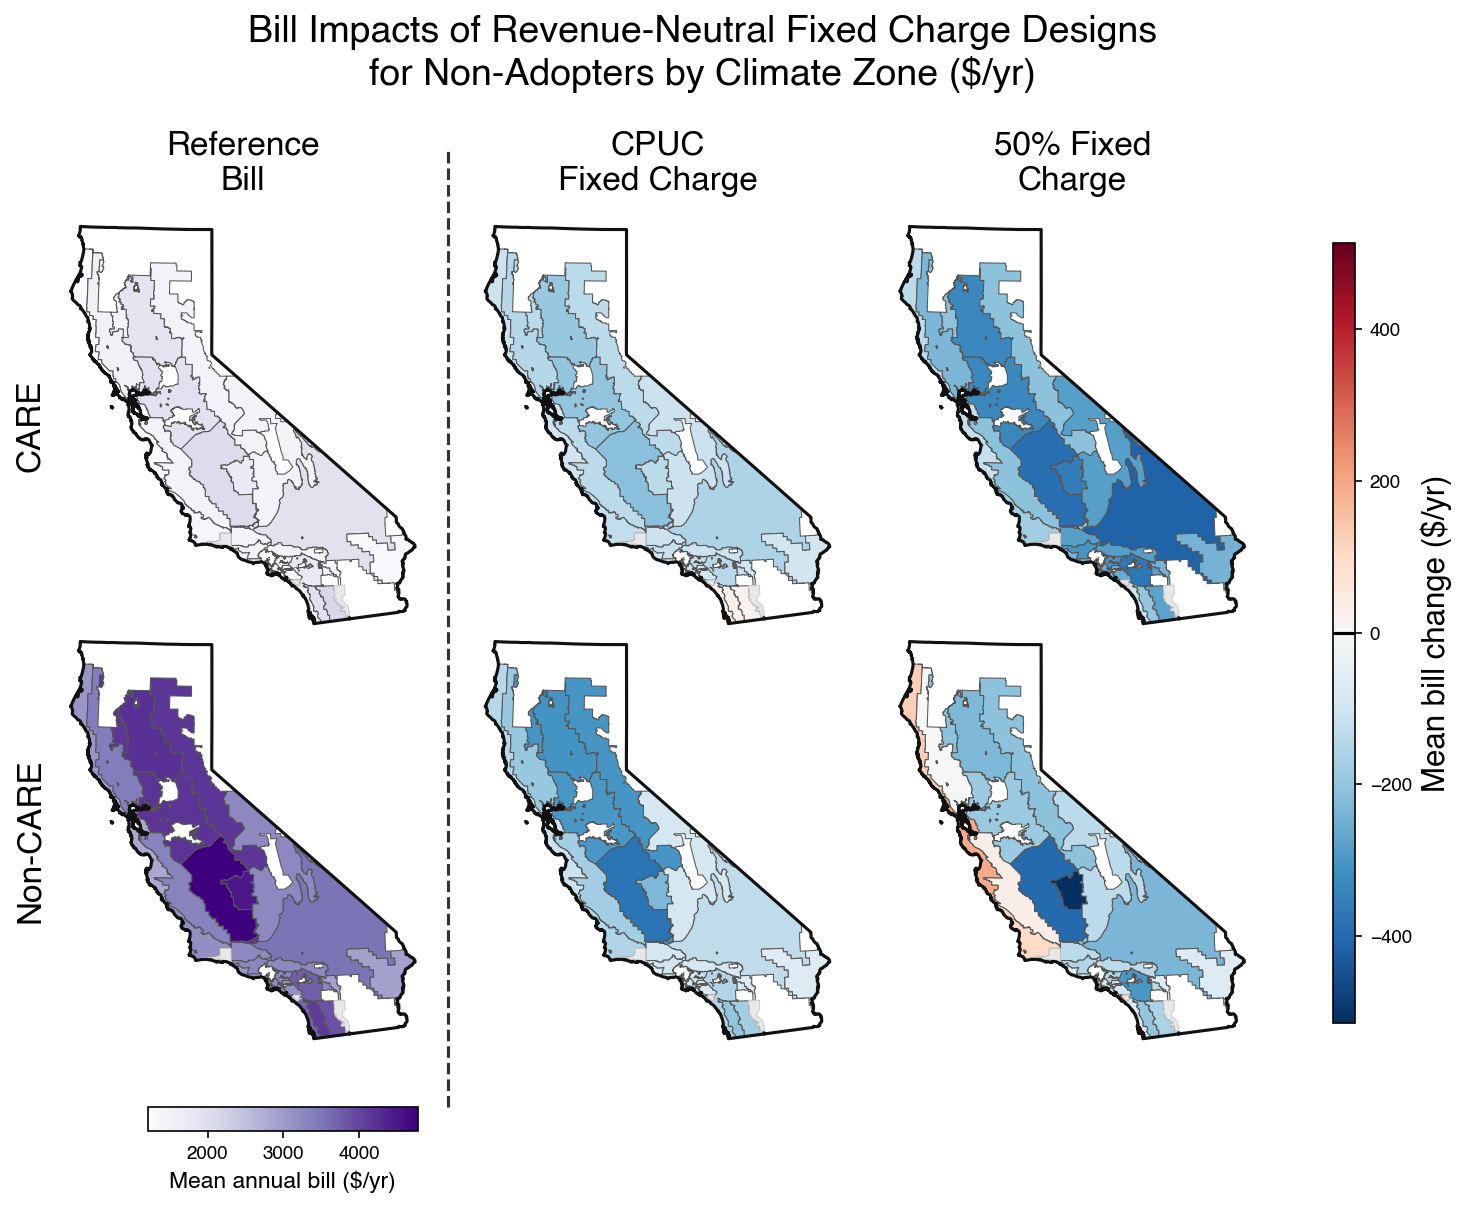

In [146]:
# ── Non-adopters: Reference bills + all 5 reforms, CARE vs Non-CARE ──
reform_all = [
    ('Current Fixed Chg',   'sqf',           False),
    ('50% Fixed Charge',    'F50_WF0_ROE0',  False),
   # ('All Three Combined',  'F50_WF1_ROE1.0', False),
]
display_labels = ['CPUC\nFixed Charge', '50% Fixed\nCharge']

# Compute stats for No DER only
all_stats = []
for iou_name, cfg in iou_configs.items():
    st = compute_cz_stats(cfg, '', iou_name)
    if not st.empty: all_stats.append(st)
stats = pd.concat(all_stats, ignore_index=True)
stats['cec_cz'] = stats['cec_cz'].astype(str)

ref_vmin = stats['ref_bill'].min()
ref_vmax = stats['ref_bill'].max()

all_reform_vals = []
for rlabel, _, _ in reform_all:
    if rlabel in stats.columns:
        all_reform_vals.extend(stats[rlabel].dropna().values)
all_reform_vals = np.array(all_reform_vals)
vmax_neg = np.abs(all_reform_vals.min())
vmax_pos = all_reform_vals.max() if all_reform_vals.max() > 0 else 100
# Symmetric around zero so increases get equal visual weight
vmax_sym = max(vmax_neg, vmax_pos)

def plot_cz_map_stark(ax, cz_iou, stats, col, cmap, norm, title, ca_outline, is_diff=True):
    merged = cz_iou.merge(stats[['cec_cz', 'iou', col]],
                           on=['cec_cz', 'iou'], how='left')
    merged.plot(ax=ax, column=col, cmap=cmap, norm=norm, edgecolor='#555',
                linewidth=0.5, legend=False, zorder=2,
                missing_kwds={'color': '#e8e8e8', 'edgecolor': '#ccc'})
    ca_outline.boundary.plot(ax=ax, color='none', edgecolor='#111',
                              linewidth=1.5, zorder=10)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=8)
    ax.axis('off')

# 2 × 4 grid with space for vertical colorbar on right
fig, axes = plt.subplots(2, 3, figsize=(10, 8),
                          gridspec_kw={'wspace': -0.1, 'hspace': -0.05})

for ci, cg in enumerate(['CARE', 'Non-CARE']):
    sub = stats[stats.care_group == cg]

    # Col 0: Reference bills — PURPLES
    ax = axes[ci, 0]
    norm = Normalize(vmin=ref_vmin, vmax=ref_vmax)
    plot_cz_map_stark(ax, cz_iou, sub, 'ref_bill', 'Purples', norm,
                      '', ca_outline, is_diff=False)

    # Cols 1-3: Reforms — SYMMETRIC BrBG (brown=increase, teal=decrease)
    for ri, (rlabel, rkey, apply_floor) in enumerate(reform_all):
        ax = axes[ci, ri + 1]
        if rlabel not in sub.columns or sub[rlabel].isna().all():
            ax.set_visible(False); continue
        norm = TwoSlopeNorm(vmin=-vmax_sym, vcenter=0, vmax=vmax_sym)
        plot_cz_map_stark(ax, cz_iou, sub, rlabel, 'RdBu_r', norm,
                          '', ca_outline, is_diff=True)

# Column titles
axes[0, 0].set_title('Reference\nBill', fontsize=16, fontweight='bold', pad=8)
for ri, dl in enumerate(display_labels):
    axes[0, ri + 1].set_title(dl, fontsize=16, fontweight='bold', pad=8)

# Row labels
for ci, cg in enumerate(['CARE', 'Non-CARE']):
    axes[ci, 0].text(-0.02, 0.5, cg, transform=axes[ci, 0].transAxes,
                      fontsize=16, fontweight='bold', rotation=90,
                      ha='right', va='center')

# Colorbar: Reference — horizontal below column 0
cax_ref = fig.add_axes([0.13, 0.06, 0.18, 0.02])
sm = plt.cm.ScalarMappable(cmap='Purples', norm=Normalize(vmin=ref_vmin, vmax=ref_vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_ref, orientation='horizontal')
cb.set_label('Mean annual bill ($/yr)', fontsize=11, fontweight='bold')
cax_ref.tick_params(labelsize=9)

# Colorbar: Reforms — VERTICAL on the right
cax_reform = fig.add_axes([0.92, 0.15, 0.015, 0.65])
norm_bar = TwoSlopeNorm(vmin=-vmax_sym, vcenter=0, vmax=vmax_sym)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_bar)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_reform, orientation='vertical')
cb.set_label('Mean bill change ($/yr)', fontsize=15, fontweight='bold')
cb.ax.axhline(0, color='k', linewidth=1.5)  # zero line on colorbar
cax_reform.tick_params(labelsize=9)
fig.suptitle('Bill Impacts of Revenue-Neutral Fixed Charge Designs\nfor Non-Adopters by Climate Zone ($/yr)',
             fontsize=18, fontweight='bold', y=0.99)
plt.subplots_adjust(left=0.04, right=0.90, top=0.83, bottom=0.12)
fig.add_artist(plt.Line2D([0.33, 0.33], [0.08, 0.88], transform=fig.transFigure,
                           color='#333', linewidth=1.5, linestyle='--', zorder=20))
draw_border(fig)
plt.savefig('map_nonadopters_fixedcharges.pdf', dpi=600, bbox_inches='tight')
plt.show()

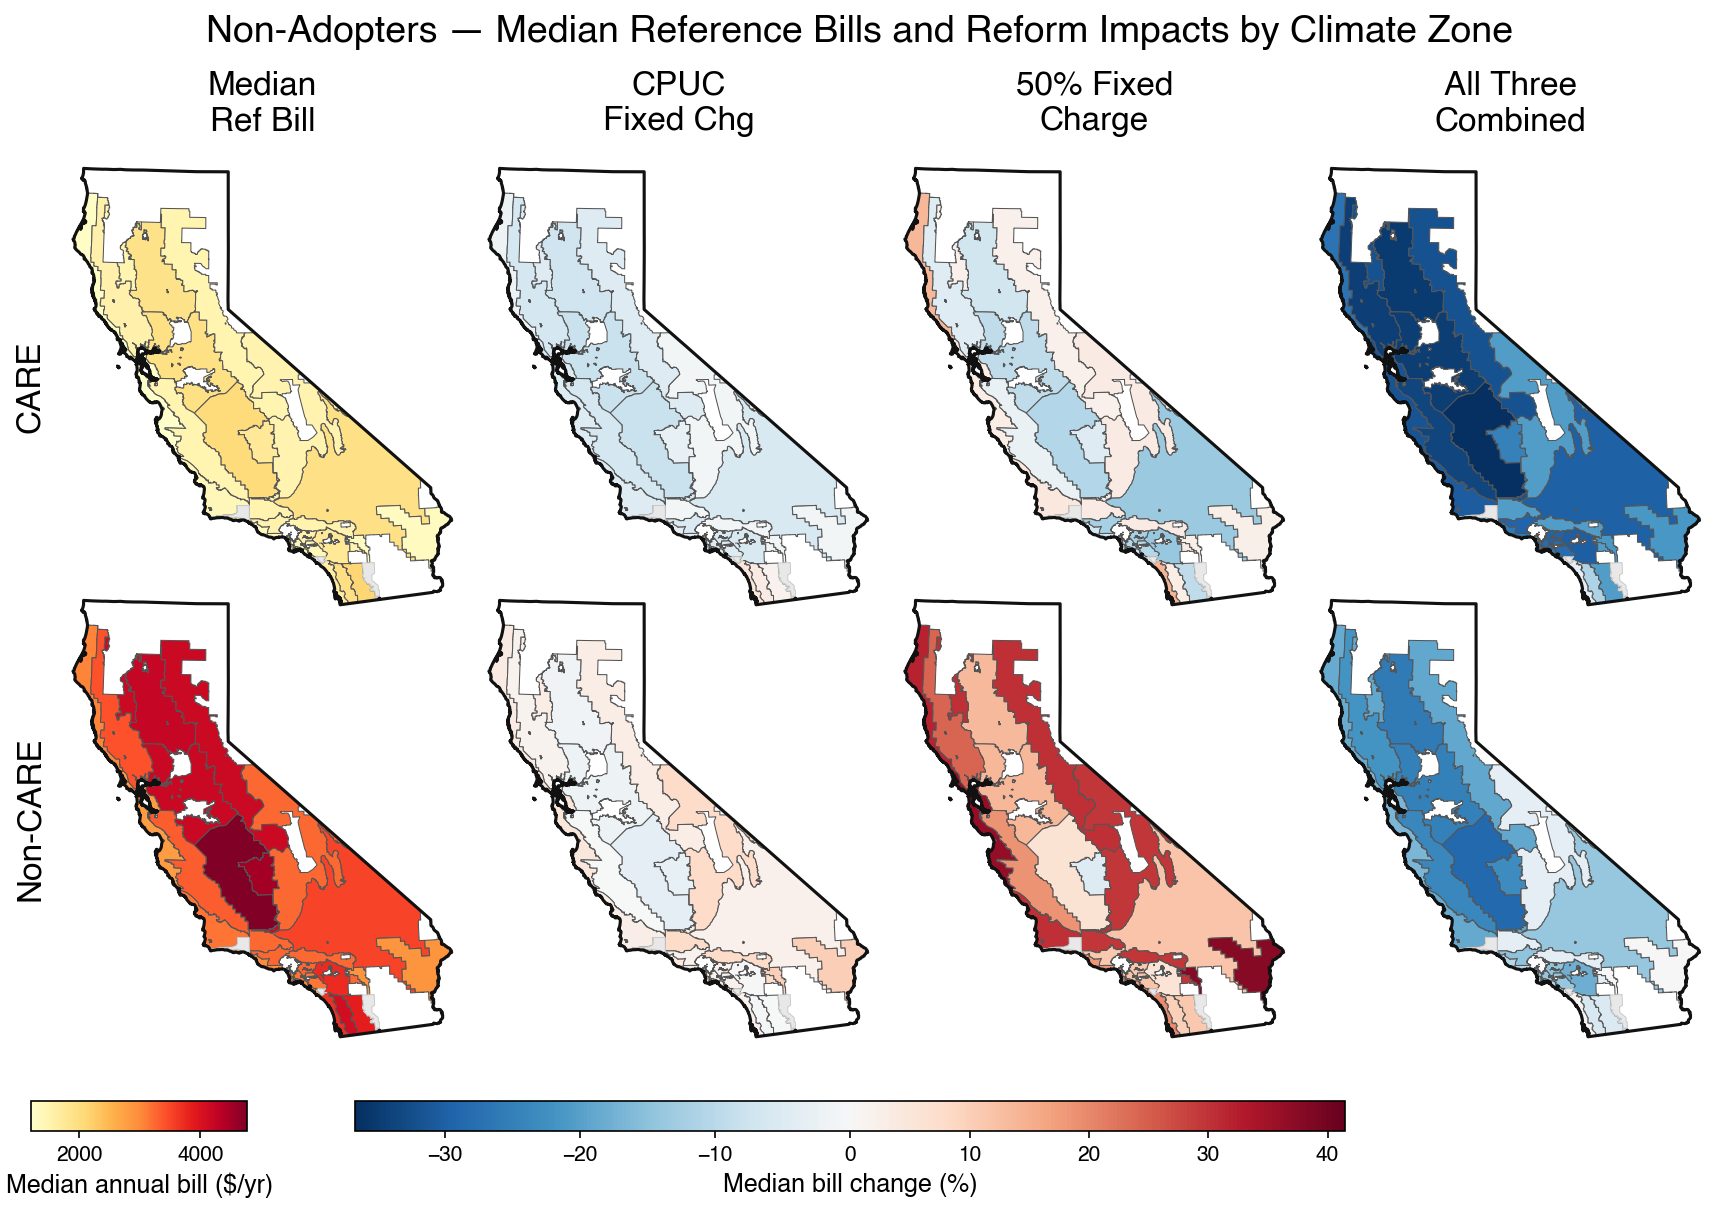

In [119]:
# ── Median % change version ──
def compute_cz_stats_median_pct(cfg, sfx, iou_name):
    df = cfg['df']; mb = cfg['mb']
    sq_col = f'{cfg["sq"]}{sfx}'
    sqf_col = f'{cfg["sqf"]}{sfx}'
    if sq_col not in df.columns: return pd.DataFrame()
    sub = df[df[sq_col].notna() & df['cec_cz'].notna()].copy()
    sq_f = sub[sq_col].clip(lower=mb)
    rows = []
    for cz_val in sub.cec_cz.unique():
        for cg in ['CARE', 'Non-CARE']:
            mask = (sub.cec_cz == cz_val) & (sub.care_group == cg)
            n = mask.sum()
            if n < 5: continue
            row = {'cec_cz': str(cz_val), 'care_group': cg, 'n': n, 'iou': iou_name,
                   'ref_bill': sq_f[mask].mean()}
            for rlabel, rkey, apply_floor in reform_all:
                bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill{sfx}'
                if bill_col not in sub.columns: row[rlabel] = np.nan; continue
                nb = sub.loc[mask, bill_col].copy()
                if apply_floor: nb = nb.clip(lower=mb)
                pct_chg = ((nb - sq_f[mask]) / sq_f[mask].abs() * 100).dropna()
                row[rlabel] = pct_chg.mean()
            rows.append(row)
    return pd.DataFrame(rows)

# ── Build stats ──
reform_all = [
    ('Current Fixed Chg',   'sqf',           False),
    ('50% Fixed Charge',    'F50_WF0_ROE0',  False),
    ('All Three Combined',  'F50_WF1_ROE1.0', False),
]
display_labels = ['CPUC\nFixed Chg', '50% Fixed\nCharge', 'All Three\nCombined']

all_stats = []
for iou_name, cfg in iou_configs.items():
    st = compute_cz_stats_median_pct(cfg, '', iou_name)
    if not st.empty: all_stats.append(st)
stats = pd.concat(all_stats, ignore_index=True)
stats['cec_cz'] = stats['cec_cz'].astype(str)

ref_vmin = stats['ref_bill'].min()
ref_vmax = stats['ref_bill'].max()

all_reform_vals = []
for rlabel, _, _ in reform_all:
    if rlabel in stats.columns:
        all_reform_vals.extend(stats[rlabel].dropna().values)
all_reform_vals = np.array(all_reform_vals)
vmax_neg = np.abs(all_reform_vals.min())
vmax_pos = all_reform_vals.max() if all_reform_vals.max() > 0 else vmax_neg * 0.3
pos_cap = max(vmax_pos * 1.1, 5)

# ── Plot ──
fig, axes = plt.subplots(2, 4, figsize=(12, 8),
                          gridspec_kw={'wspace': -0.1, 'hspace': -0.1})

for ci, cg in enumerate(['CARE', 'Non-CARE']):
    sub = stats[stats.care_group == cg]

    ax = axes[ci, 0]
    norm = Normalize(vmin=ref_vmin, vmax=ref_vmax)
    plot_cz_map_stark(ax, cz_iou, sub, 'ref_bill', 'YlOrRd', norm,
                      '', ca_outline, is_diff=False)

    for ri, (rlabel, rkey, apply_floor) in enumerate(reform_all):
        ax = axes[ci, ri + 1]
        if rlabel not in sub.columns or sub[rlabel].isna().all():
            ax.set_visible(False); continue
        norm = TwoSlopeNorm(vmin=-vmax_neg, vcenter=0, vmax=pos_cap)
        plot_cz_map_stark(ax, cz_iou, sub, rlabel, 'RdBu_r', norm,
                          '', ca_outline, is_diff=True)

axes[0, 0].set_title('Median\nRef Bill', fontsize=16, fontweight='bold', pad=8)
for ri, dl in enumerate(display_labels):
    axes[0, ri + 1].set_title(dl, fontsize=16, fontweight='bold', pad=8)

for ci, cg in enumerate(['CARE', 'Non-CARE']):
    axes[ci, 0].text(-0.02, 0.5, cg, transform=axes[ci, 0].transAxes,
                      fontsize=16, fontweight='bold', rotation=90,
                      ha='right', va='center')

cax_ref = fig.add_axes([0.04, 0.06, 0.12, 0.025])
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=ref_vmin, vmax=ref_vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_ref, orientation='horizontal')
cb.set_label('Median annual bill ($/yr)', fontsize=12, fontweight='bold')
cax_ref.tick_params(labelsize=10)

cax_reform = fig.add_axes([0.22, 0.06, 0.55, 0.025])
norm_bar = TwoSlopeNorm(vmin=-vmax_neg, vcenter=0, vmax=pos_cap)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_bar)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_reform, orientation='horizontal')
cb.set_label('Median bill change (%)', fontsize=12, fontweight='bold')
cax_reform.tick_params(labelsize=10)

fig.suptitle('Non-Adopters — Median Reference Bills and Reform Impacts by Climate Zone',
             fontsize=18, fontweight='bold', y=0.99)
plt.subplots_adjust(left=0.04, right=0.99, top=0.88, bottom=0.12)
draw_border(fig)
#plt.savefig('map_nonadopters_median_pct.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
# ── Non-adopters: Reference bills + all 5 reforms, CARE vs Non-CARE ──
reform_all = [
    ('Current Fixed Chg',   'sqf',           False),
    ('50% Fixed Charge',    'F50_WF0_ROE0',  False),
    ('Wildfire Removal',    'F0_WF1_ROE0',   True),
    ('ROE Reduction',       'F0_WF0_ROE1.0', True),
    ('All Three Combined',  'F50_WF1_ROE1.0', False),
]
display_labels = ['CPUC\nFixed Chg', '50% Fixed\nCharge', 'Wildfire\nRemoval',
                  'ROE\nReduction', 'All Three\nCombined']

# ── Compute stats with % change ──
def compute_cz_stats_pct(cfg, sfx, iou_name):
    df = cfg['df']; mb = cfg['mb']
    sq_col = f'{cfg["sq"]}{sfx}'
    sqf_col = f'{cfg["sqf"]}{sfx}'
    if sq_col not in df.columns: return pd.DataFrame()
    sub = df[df[sq_col].notna() & df['cec_cz'].notna()].copy()
    sq_f = sub[sq_col].clip(lower=mb)
    rows = []
    for cz_val in sub.cec_cz.unique():
        for cg in ['CARE', 'Non-CARE']:
            mask = (sub.cec_cz == cz_val) & (sub.care_group == cg)
            n = mask.sum()
            if n < 5: continue
            row = {'cec_cz': str(cz_val), 'care_group': cg, 'n': n, 'iou': iou_name,
                   'ref_bill': sq_f[mask].mean()}
            for rlabel, rkey, apply_floor in reform_all:
                bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill{sfx}'
                if bill_col not in sub.columns: row[rlabel] = np.nan; continue
                nb = sub.loc[mask, bill_col].copy()
                if apply_floor: nb = nb.clip(lower=mb)
                chg = (nb - sq_f[mask]).dropna()
                row[rlabel] = (chg / sq_f[mask].abs()).mean() * 100  # % change
            rows.append(row)
    return pd.DataFrame(rows)

all_stats = []
for iou_name, cfg in iou_configs.items():
    st = compute_cz_stats_pct(cfg, '', iou_name)
    if not st.empty: all_stats.append(st)
stats = pd.concat(all_stats, ignore_index=True)
stats['cec_cz'] = stats['cec_cz'].astype(str)

# Shared ranges
ref_vmin = stats['ref_bill'].min()
ref_vmax = stats['ref_bill'].max()

all_reform_vals = []
for rlabel, _, _ in reform_all:
    if rlabel in stats.columns:
        all_reform_vals.extend(stats[rlabel].dropna().values)
all_reform_vals = np.array(all_reform_vals)
vmax_neg = np.abs(all_reform_vals.min())
vmax_pos = all_reform_vals.max() if all_reform_vals.max() > 0 else vmax_neg * 0.3
vmax_reform = vmax_neg
pos_cap = max(vmax_pos * 1.3, vmax_reform * 0.3)

# 2 rows × 6 columns — tighter spacing
fig, axes = plt.subplots(2, 6, figsize=(24, 8),
                          gridspec_kw={'wspace': -0.1, 'hspace': -0.1})

for ci, cg in enumerate(['CARE', 'Non-CARE']):
    sub = stats[stats.care_group == cg]

    ax = axes[ci, 0]
    norm = Normalize(vmin=ref_vmin, vmax=ref_vmax)
    plot_cz_map(ax, cz_iou, sub, 'ref_bill', 'YlOrRd', norm,
                '', ca_outline, is_diff=False)

    for ri, (rlabel, rkey, apply_floor) in enumerate(reform_all):
        ax = axes[ci, ri + 1]
        if rlabel not in sub.columns or sub[rlabel].isna().all():
            ax.set_visible(False); continue
        norm = TwoSlopeNorm(vmin=-vmax_reform, vcenter=0, vmax=pos_cap)
        plot_cz_map(ax, cz_iou, sub, rlabel, 'RdBu_r', norm,
                    '', ca_outline, is_diff=True)

# Column titles
axes[0, 0].set_title('Reference\nBill', fontsize=14, fontweight='bold', pad=8)
for ri, dl in enumerate(display_labels):
    axes[0, ri + 1].set_title(dl, fontsize=13, fontweight='bold', pad=8)

# Row labels
for ci, cg in enumerate(['CARE', 'Non-CARE']):
    axes[ci, 0].text(-0.02, 0.5, cg, transform=axes[ci, 0].transAxes,
                      fontsize=16, fontweight='bold', rotation=90,
                      ha='right', va='center')

# Colorbar: Reference
cax_ref = fig.add_axes([0.04, 0.06, 0.12, 0.025])
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=Normalize(vmin=ref_vmin, vmax=ref_vmax))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_ref, orientation='horizontal')
cb.set_label('Annual bill ($/yr)', fontsize=12)
cax_ref.tick_params(labelsize=10)

# Colorbar: Reforms (% change)
cax_reform = fig.add_axes([0.22, 0.06, 0.55, 0.025])
norm_bar = TwoSlopeNorm(vmin=-vmax_reform, vcenter=0, vmax=pos_cap)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm_bar)
sm.set_array([])
cb = fig.colorbar(sm, cax=cax_reform, orientation='horizontal')
cb.set_label('Mean bill change (%)', fontsize=12)
cax_reform.tick_params(labelsize=10)

fig.suptitle('Non-Adopters — Reference Bills and Reform Impacts by Climate Zone',
             fontsize=18, fontweight='bold', y=0.99)
plt.subplots_adjust(left=0.04, right=0.99, top=0.88, bottom=0.12)
draw_border(fig)
#plt.savefig('map_nonadopters_all_reforms.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [132]:
# =============================================
# AGGREGATE EQUITY STATS — All IOUs combined
# =============================================
import pandas as pd
import numpy as np

rate_scenarios = [
    ('Reference TOU',       'sq',            False),
    ('CPUC Fixed Chg',      'sqf',           False),
    ('Baseline',      'F0_WF0_ROE0',           False),
        ('50% Fixed Charge',    'F50_WF0_ROE0',  False),
    ('ROE Reduction',       'F0_WF0_ROE1.0', False),
    ('Wildfire Removal',    'F0_WF1_ROE0',   False),
    ('All Three Combined',  'F50_WF1_ROE1.0', False),
]

results = []

for iou, ucfg in configs.items():
    df = dfs[iou].copy()
    mb = ucfg['min_bill']
    sq_col = ucfg['sq']
    sqf_col = ucfg['sqf']

    # Same households throughout
    df = df[df[sq_col].notna()].copy()
    #wt = df['scaling_factor']
    n_total = len(df)
    n_care = df.is_care.sum()
    n_nc = (~df.is_care).sum()

    # Identify adopters (have any DER bill column populated)
    s1 = f'{sq_col}_s1_ev'
    s2 = f'{sq_col}_s2_pv_stor'
    is_adopter = pd.Series(False, index=df.index)
    for sfx in ['_s1_ev', '_s2_pv_stor', ucfg.get('s3', '_s3_pv_stor_ev')]:
        col = f'{sq_col}{sfx}'
        if col in df.columns:
            is_adopter = is_adopter | df[col].notna()
    df['is_adopter'] = is_adopter

    for rlabel, rkey, apply_floor in rate_scenarios:
        if rkey == 'sq':
            bill_col = sq_col
        elif rkey == 'sqf':
            bill_col = sqf_col
        else:
            bill_col = f'{rkey}_bill'
        if bill_col not in df.columns: continue

        bills = df[bill_col].copy()
        if apply_floor:
            bills = bills.clip(lower=mb)

        df['_rev'] = bills

        # Total revenue
        rev_total = df['_rev'].sum() / 1e6
        rev_care = df.loc[df.is_care, '_rev'].sum() / 1e6
        rev_nc = df.loc[~df.is_care, '_rev'].sum() / 1e6
        rev_adopter = df.loc[df.is_adopter, '_rev'].sum() / 1e6
        rev_nonadopter = df.loc[~df.is_adopter, '_rev'].sum() / 1e6

        # Reference revenue for % comparison
        sq_bills = df[sq_col].clip(lower=mb)
        df['_sq_rev'] = sq_bills
        rev_sq = df['_sq_rev'].sum() / 1e6

        results.append({
            'IOU': iou,
            'Scenario': rlabel,
            'Total Revenue ($M)': rev_total,
            'vs Reference (%)': (rev_total - rev_sq) / rev_sq * 100,
            'CARE Share (%)': rev_care / rev_total * 100,
            'Non-CARE Share (%)': rev_nc / rev_total * 100,
            'CARE Avg Bill ($/yr)': rev_care * 1e6 / n_care,
            'Non-CARE Avg Bill ($/yr)': rev_nc * 1e6 / n_nc,
            'Adopter Rev ($M)': rev_adopter,
            'Non-Adopter Rev ($M)': rev_nonadopter,
            'Adopter Share (%)': rev_adopter / rev_total * 100,
            'N Adopters': df.is_adopter.sum(),
            'N Total': n_total,
        })

summary = pd.DataFrame(results)

# ── 1. Revenue vs Reference ──
print('='*80)
print('1. TOTAL REVENUE BY SCENARIO (same households)')
print('='*80)
cols1 = ['IOU', 'Scenario', 'Total Revenue ($M)', 'vs Reference (%)']
print(summary[cols1].to_string(index=False, float_format='%.1f'))

# ── 2. CARE vs Non-CARE burden ──
print('\n' + '='*80)
print('2. REVENUE BURDEN: CARE vs NON-CARE')
print('='*80)
cols2 = ['IOU', 'Scenario', 'CARE Share (%)', 'Non-CARE Share (%)',
         'CARE Avg Bill ($/yr)', 'Non-CARE Avg Bill ($/yr)']
print(summary[cols2].to_string(index=False, float_format='%.1f'))

# ── 3. Adopter vs Non-Adopter cost shift ──
print('\n' + '='*80)
print('3. COST SHIFT: ADOPTERS vs NON-ADOPTERS')
print('='*80)
cols3 = ['IOU', 'Scenario', 'Adopter Rev ($M)', 'Non-Adopter Rev ($M)',
         'Adopter Share (%)', 'N Adopters', 'N Total']
print(summary[cols3].to_string(index=False, float_format='%.1f'))

# ── Per-household adopter vs non-adopter avg bill ──
print('\n' + '='*80)
print('4. PER-HOUSEHOLD AVG BILL: ADOPTER vs NON-ADOPTER')
print('='*80)
for iou in configs:
    sub = summary[summary.IOU == iou]
    n_adopt = sub['N Adopters'].iloc[0]
    n_nonadopt = sub['N Total'].iloc[0] - n_adopt
    print(f'\n{iou} (Adopters: {n_adopt:,}, Non-Adopters: {n_nonadopt:,})')
    for _, row in sub.iterrows():
        avg_adopt = row['Adopter Rev ($M)'] * 1e6 / n_adopt if n_adopt > 0 else 0
        avg_nonadopt = row['Non-Adopter Rev ($M)'] * 1e6 / n_nonadopt if n_nonadopt > 0 else 0
        shift = avg_nonadopt - avg_adopt
        print(f'  {row["Scenario"]:22s}  Adopter: ${avg_adopt:,.0f}  Non-Adopter: ${avg_nonadopt:,.0f}  Gap: ${shift:+,.0f}')

1. TOTAL REVENUE BY SCENARIO (same households)
  IOU           Scenario  Total Revenue ($M)  vs Reference (%)
 PG&E      Reference TOU                68.3              -0.0
 PG&E     CPUC Fixed Chg                63.8              -6.6
 PG&E           Baseline                68.3              -0.0
 PG&E   50% Fixed Charge                67.8              -0.7
 PG&E      ROE Reduction                67.6              -1.1
 PG&E   Wildfire Removal                50.2             -26.6
 PG&E All Three Combined                49.2             -27.9
  SCE      Reference TOU                52.2              -0.0
  SCE     CPUC Fixed Chg                50.3              -3.7
  SCE           Baseline                52.2               0.0
  SCE   50% Fixed Charge                50.9              -2.5
  SCE      ROE Reduction                51.6              -1.2
  SCE   Wildfire Removal                43.5             -16.7
  SCE All Three Combined                42.1             -19.4
SDG&E   

In [ ]:
# =============================================
# EQUITY FIGURES — All IOUs
# =============================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

iou_names = list(configs.keys())
iou_colors = {'PG&E': '#2c3e50', 'SCE': '#7f8c8d', 'SDG&E': '#bdc3c7'}
iou_hatches = {'PG&E': '', 'SCE': '///', 'SDG&E': '...'}

rate_scenarios = [
    ('Reference TOU',       'sq',            True),
    ('CPUC Fixed Chg',      'sqf',           False),
   ('Baseline',      'F0_WF0_ROE0',           False),

    ('50% Fixed Charge',    'F50_WF0_ROE0',  False),

    ('ROE Reduction',       'F0_WF0_ROE1.0', True),
    ('Wildfire Removal',    'F0_WF1_ROE0',   True),
    ('All Three Combined',  'F50_WF1_ROE1.0', False),
]
rate_labels = [r[0] for r in rate_scenarios]
n_rates = len(rate_scenarios)

# ── Collect data ──
data = {}
for iou, ucfg in configs.items():
    df = dfs[iou].copy()
    mb = ucfg['min_bill']
    sq_col = ucfg['sq']
    sqf_col = ucfg['sqf']
    df = df[df[sq_col].notna()].copy()
    wt = df['scaling_factor']

    # Identify adopters
    is_adopter = pd.Series(False, index=df.index)
    for sfx in ['_s1_ev', '_s2_pv_stor', ucfg.get('s3', '_s3_pv_stor_ev')]:
        col = f'{sq_col}{sfx}'
        if col in df.columns:
            is_adopter = is_adopter | df[col].notna()
    df['is_adopter'] = is_adopter

    n_care = df.is_care.sum()
    n_nc = (~df.is_care).sum()
    n_adopt = df.is_adopter.sum()
    n_nonadopt = (~df.is_adopter).sum()

    iou_data = {'n_care': n_care, 'n_nc': n_nc,
                'n_adopt': n_adopt, 'n_nonadopt': n_nonadopt}

    for rlabel, rkey, apply_floor in rate_scenarios:
        if rkey == 'sq':
            bill_col = sq_col
        elif rkey == 'sqf':
            bill_col = sqf_col
        else:
            bill_col = f'{rkey}_bill'
        if bill_col not in df.columns: continue

        bills = df[bill_col].copy()
        if apply_floor:
            bills = bills.clip(lower=mb)
        df['_rev'] = bills * wt

        iou_data[f'{rlabel}_care_rev'] = df.loc[df.is_care, '_rev'].sum() / 1e6
        iou_data[f'{rlabel}_nc_rev'] = df.loc[~df.is_care, '_rev'].sum() / 1e6
        iou_data[f'{rlabel}_adopt_rev'] = df.loc[df.is_adopter, '_rev'].sum() / 1e6
        iou_data[f'{rlabel}_nonadopt_rev'] = df.loc[~df.is_adopter, '_rev'].sum() / 1e6

    data[iou] = iou_data

# =============================================
# FIGURE 1: Stacked revenue (CARE + Non-CARE) per IOU
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'wspace': 0.25})

for ai, iou in enumerate(iou_names):
    ax = axes[ai]
    d = data[iou]
    care_vals = [d.get(f'{rl}_care_rev', 0) for rl in rate_labels]
    nc_vals = [d.get(f'{rl}_nc_rev', 0) for rl in rate_labels]

    x = np.arange(n_rates)
    w = 0.5

    ax.bar(x, care_vals, w, color='#1565C0', label='CARE', alpha=0.85)
    ax.bar(x, nc_vals, w, bottom=care_vals, color='#E65100', label='Non-CARE', alpha=0.85)

    # Total labels on top
    for i, (c, n) in enumerate(zip(care_vals, nc_vals)):
        total = c + n
        ax.text(i, total + 0.5, f'${total:.0f}M', ha='center', fontsize=8, fontweight='bold')

    # CARE % inside bar
    for i, (c, n) in enumerate(zip(care_vals, nc_vals)):
        total = c + n
        if total > 0:
            pct = c / total * 100
            ax.text(i, c / 2, f'{pct:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(rate_labels, fontsize=9, rotation=35, ha='right')
    ax.set_ylabel('Revenue ($M/yr)', fontsize=11)
    ax.set_title(iou, fontsize=14, fontweight='bold')
    ax.legend(fontsize=9, loc = 'upper right')
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Revenue Composition by Rate Design: CARE vs Non-CARE',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('fig_revenue_care_noncare.pdf', dpi=600, bbox_inches='tight')
plt.show()

# =============================================
# FIGURE 2: Cost shift — per-HH avg bill, Adopter vs Non-Adopter
# =============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'wspace': 0.25})

for ai, iou in enumerate(iou_names):
    ax = axes[ai]
    d = data[iou]
    n_adopt = d['n_adopt']
    n_nonadopt = d['n_nonadopt']

    adopt_avg = [d.get(f'{rl}_adopt_rev', 0) * 1e6 / n_adopt if n_adopt > 0 else 0
                 for rl in rate_labels]
    nonadopt_avg = [d.get(f'{rl}_nonadopt_rev', 0) * 1e6 / n_nonadopt if n_nonadopt > 0 else 0
                    for rl in rate_labels]

    x = np.arange(n_rates)
    w = 0.35

    bars1 = ax.bar(x - w/2, nonadopt_avg, w, color='#e74c3c', label=f'Non-Adopter (n={n_nonadopt:,})',
                   alpha=0.85, edgecolor='#333', linewidth=0.3)
    bars2 = ax.bar(x + w/2, adopt_avg, w, color='#27ae60', label=f'Adopter (n={n_adopt:,})',
                   alpha=0.85, edgecolor='#333', linewidth=0.3)

    # Gap annotation
    for i, (na, a) in enumerate(zip(nonadopt_avg, adopt_avg)):
        gap = na - a
        ypos = max(na, a) + 30
        ax.text(i, ypos, f'Δ${gap:+,.0f}', ha='center', fontsize=7,
                fontweight='bold', color='#333')

    ax.set_xticks(x)
    ax.set_xticklabels(rate_labels, fontsize=9, rotation=35, ha='right')
    ax.set_ylabel('Avg Annual Bill ($/yr)', fontsize=11)
    ax.set_title(iou, fontsize=14, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Cost Shift: Average Bill for Adopters vs Non-Adopters by Rate Design',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
#plt.savefig('fig_cost_shift_adopter.pdf', dpi=600, bbox_inches='tight')
plt.show()

# =============================================
# FIGURE 3: CARE share shift across scenarios
# =============================================
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(n_rates)
w = 0.25

for ii, iou in enumerate(iou_names):
    d = data[iou]
    care_share = []
    for rl in rate_labels:
        c = d.get(f'{rl}_care_rev', 0)
        n = d.get(f'{rl}_nc_rev', 0)
        care_share.append(c / (c + n) * 100 if (c + n) > 0 else 0)

    offset = (ii - 1) * w
    bars = ax.bar(x + offset, care_share, w, color=iou_colors[iou],
                  hatch=iou_hatches[iou], alpha=0.85, edgecolor='#333',
                  linewidth=0.3, label=iou)

    # Value labels
    for i, v in enumerate(care_share):
        ax.text(x[i] + offset, v + 0.2, f'{v:.1f}%', ha='center',
                fontsize=7, fontweight='bold')

# Reference line (avg of reference TOU across IOUs)
ref_shares = []
for iou in iou_names:
    d = data[iou]
    c = d.get(f'{rate_labels[0]}_care_rev', 0)
    n = d.get(f'{rate_labels[0]}_nc_rev', 0)
    ref_shares.append(c / (c + n) * 100)
ax.axhline(np.mean(ref_shares), color='#333', ls='--', lw=1, alpha=0.5,
           label=f'Avg reference ({np.mean(ref_shares):.1f}%)')

ax.set_xticks(x)
ax.set_xticklabels(rate_labels, fontsize=10, rotation=25, ha='right')
ax.set_ylabel('CARE Share of Total Revenue (%)', fontsize=12)
ax.set_title('CARE Revenue Burden Share by Rate Design', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2)
ax.set_ylim(0, max([max(
    [data[iou].get(f'{rl}_care_rev', 0) / (data[iou].get(f'{rl}_care_rev', 0) + data[iou].get(f'{rl}_nc_rev', 1)) * 100
     for rl in rate_labels]) for iou in iou_names]) + 5)

plt.tight_layout()
#plt.savefig('fig_care_share.pdf', dpi=600, bbox_inches='tight')
plt.show()

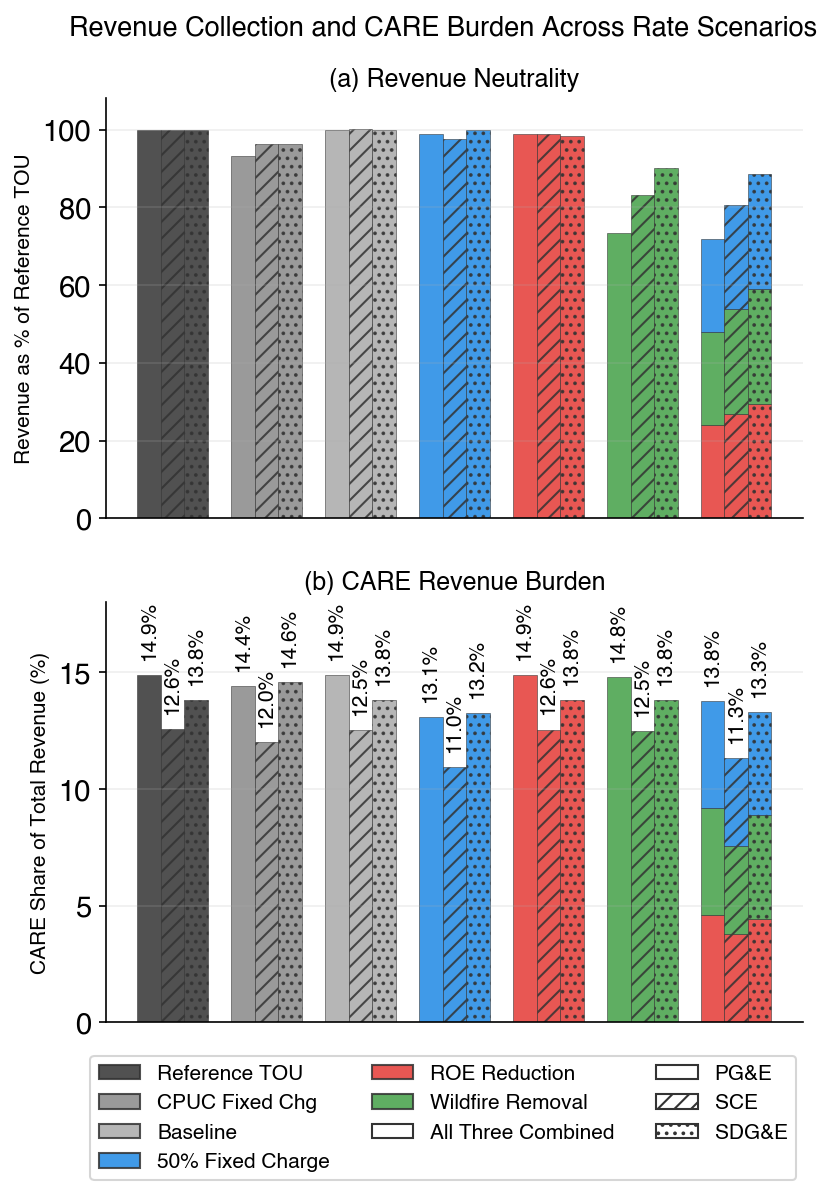

In [134]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={'wspace': 0.3})

iou_hatches = {'PG&E': '', 'SCE': '///', 'SDG&E': '...'}

rate_color_map = {
    'Reference TOU':      '#333333',
    'CPUC Fixed Chg':     '#888888',
   'Baseline':           '#AAAAAA',
    '50% Fixed Charge':   '#1E88E5',
    'ROE Reduction':      '#E53935',
    'Wildfire Removal':   '#43A047',
    'All Three Combined':  None,
}
combo_colors = ['#E53935', '#43A047', '#1E88E5']

# Use rate_labels from data collection (drives order)
n_rates = len(rate_labels)
x = np.arange(n_rates)
w = 0.25

# Short labels for x-axis
short_labels = {
    'Reference TOU': 'Reference\nTOU',
    'CPUC Fixed Chg': 'CPUC\nFixed Chg',
    'Baseline': 'Baseline',
    '50% Fixed Charge': '50% Fixed\nCharge',
    'ROE Reduction': 'ROE\nReduction',
    'Wildfire Removal': 'Wildfire\nRemoval',
    'All Three Combined': 'All Three\nCombined',
}

# ── Panel A: Revenue as % of Reference TOU ──
for ii, iou in enumerate(iou_names):
    d = data[iou]
    ref_rev = d.get(f'{rate_labels[0]}_care_rev', 0) + d.get(f'{rate_labels[0]}_nc_rev', 0)

    offset = (ii - 1) * w
    for ri, rl in enumerate(rate_labels):
        total = d.get(f'{rl}_care_rev', 0) + d.get(f'{rl}_nc_rev', 0)
        pct = total / ref_rev * 100 if ref_rev > 0 else 0
        col = rate_color_map.get(rl, '#333')

        if col is None:
            third = pct / 3
            for ci, cc in enumerate(combo_colors):
                ax1.bar(x[ri] + offset, third, w, bottom=ci * third,
                        color=cc, hatch=iou_hatches[iou],
                        alpha=0.85, edgecolor='#333', linewidth=0.3)
        else:
            ax1.bar(x[ri] + offset, pct, w, color=col,
                    hatch=iou_hatches[iou], alpha=0.85,
                    edgecolor='#333', linewidth=0.3)

        #ax1.text(x[ri] + offset, pct + 0.5, f'{pct:.1f}%', ha='center',
         #        fontsize=5.5, fontweight='bold')

#ax1.axhline(100, color='#333', ls='--', lw=1, alpha=0.3)
#ax1.set_xticks(x)
#ax1.set_xticklabels([short_labels[rl] for rl in rate_labels], fontsize=8, rotation=35, ha='right')
ax1.set_ylabel('Revenue as % of Reference TOU', fontsize=10)
ax1.set_title('(a) Revenue Neutrality', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.2)
ax1.set_ylim(0, 108)

# ── Panel B: CARE Share of Revenue ──
for ii, iou in enumerate(iou_names):
    d = data[iou]

    offset = (ii - 1) * w
    for ri, rl in enumerate(rate_labels):
        c = d.get(f'{rl}_care_rev', 0)
        n = d.get(f'{rl}_nc_rev', 0)
        total = c + n
        care_pct = c / total * 100 if total > 0 else 0
        col = rate_color_map.get(rl, '#333')

        if col is None:
            third = care_pct / 3
            for ci, cc in enumerate(combo_colors):
                ax2.bar(x[ri] + offset, third, w, bottom=ci * third,
                        color=cc, hatch=iou_hatches[iou],
                        alpha=0.85, edgecolor='#333', linewidth=0.3)
        else:
            ax2.bar(x[ri] + offset, care_pct, w, color=col,
                    hatch=iou_hatches[iou], alpha=0.85,
                    edgecolor='#333', linewidth=0.3)

        ax2.text(x[ri] + offset, care_pct + 0.8, f'{care_pct:.1f}%', ha='center', rotation = 90,
                 fontsize= 10, fontweight='bold')

#ax2.set_xticks(x)
#ax2.set_xticklabels([short_labels[rl] for rl in rate_labels], fontsize=8, rotation=35, ha='right')
ax2.set_ylabel('CARE Share of Total Revenue (%)', fontsize=10)
ax2.set_title('(b) CARE Revenue Burden', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.2)
ax2.set_ylim(0, 18)
ax1.tick_params(axis='x', length=0)
ax2.tick_params(axis='x', length=0)
ax1.set_xticks([])
ax2.set_xticks([])



# Legend
rate_handles = [mpatches.Patch(facecolor=rate_color_map[rl], edgecolor='#333',
                                label=rl, alpha=0.85)
                for rl in rate_labels if rate_color_map.get(rl) is not None]
combo_handle = mpatches.Patch(facecolor='white', edgecolor='#333',
                               label='All Three Combined')
iou_handles = [mpatches.Patch(facecolor='white', edgecolor='#333',
                               hatch=iou_hatches[iou], label=iou)
               for iou in iou_names]

fig.legend(handles=rate_handles + [combo_handle] + iou_handles,
           loc='lower center', ncol=3, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, -0.03))

fig.suptitle('Revenue Collection and CARE Burden Across Rate Scenarios',
             fontsize=13, fontweight='bold', y=0.95)
plt.tight_layout()
plt.savefig('fig_revenue_care_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


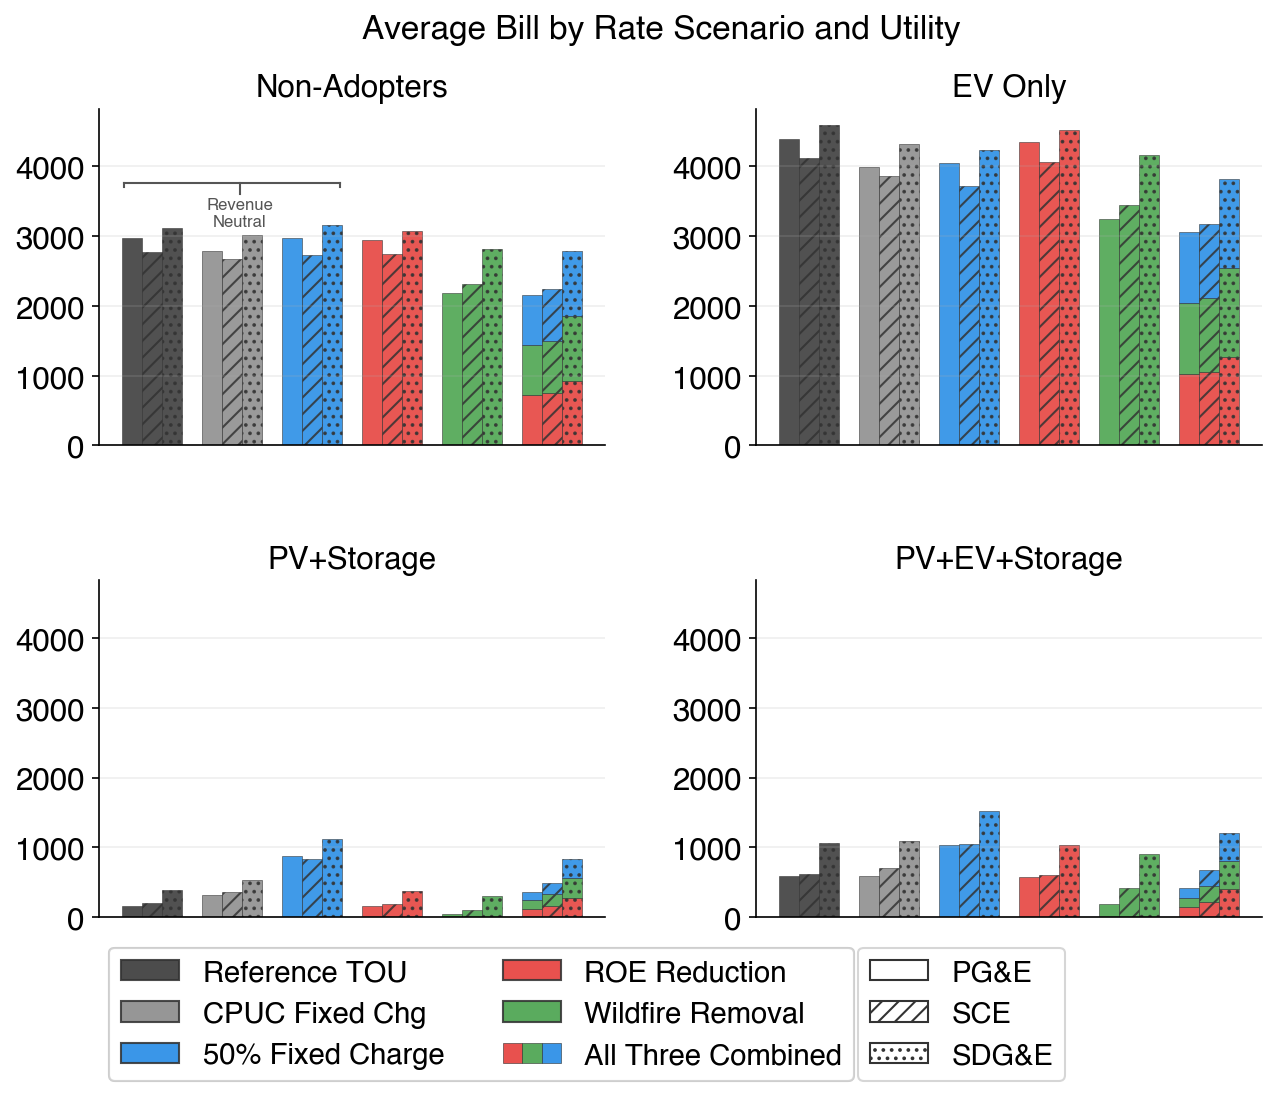

In [203]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(10, 7), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})

type_names = ['Non-Adopters', 'EV Only', 'PV+Storage', 'PV+EV+Storage']

rate_defs = [
    ('Reference\nTOU',        'sq',            '#333333'),
    ('CPUC Fixed Chg',        'sqf',           '#888888'),
    ('50% Fixed\nCharge',     'F50_WF0_ROE0',  '#1E88E5'),
    ('ROE\nReduction',        'F0_WF0_ROE1.0', '#E53935'),
    ('Wildfire\nRemoval',     'F0_WF1_ROE0',   '#43A047'),
    ('All Three\nCombined',   'F50_WF1_ROE1.0', None),
]

combo_colors = ['#E53935', '#43A047', '#1E88E5']
iou_hatches_dict = {'PG&E': '', 'SCE': '///', 'SDG&E': '...'}

for ti, tname in enumerate(type_names):
    ax = axes[ti // 2][ti % 2]

    x = np.arange(len(rate_defs))
    bw = 0.25

    for ii, iou in enumerate(iou_names):
        ucfg = configs[iou]
        df = dfs[iou].copy()
        sq_col = ucfg['sq']
        sqf_col = ucfg['sqf']
        df = df[df[sq_col].notna()].copy()

        has_ev = df.get(f'{sq_col}_s1_ev', pd.Series(dtype=float)).notna()
        has_pv = df.get(f'{sq_col}_s2_pv_stor', pd.Series(dtype=float)).notna()
        s3_col_name = f'{sq_col}{ucfg.get("s3_sfx", "_s3_pv_stor_ev")}'
        has_pvev = df.get(s3_col_name, pd.Series(dtype=float)).notna() if s3_col_name in df.columns else pd.Series(False, index=df.index)

        types_mask = {
            'Non-Adopters': ~(has_ev | has_pv | has_pvev),
            'EV Only': has_ev & ~has_pv & ~has_pvev,
            'PV+Storage': has_pv & ~has_pvev,
            'PV+EV+Storage': has_pvev,
        }

        tmask = types_mask[tname]

        def get_bill(rkey):
            sub = df[tmask]
            if len(sub) == 0:
                return 0
            if rkey == 'sq':
                base, bill_col = sq_col, sq_col
            elif rkey == 'sqf':
                base, bill_col = sqf_col, sqf_col
            else:
                base, bill_col = rkey, f'{rkey}_bill'

            post_col = None
            if tname == 'EV Only':
                post_col = f'{base}_bill_s1_ev' if rkey not in ['sq', 'sqf'] else f'{sq_col}_bill_s1_ev'
                if post_col not in sub.columns:
                    post_col = f'{base}_s1_ev'
            elif tname == 'PV+Storage':
                post_col = f'{base}_bill_s2_pv_stor' if rkey not in ['sq', 'sqf'] else f'{sq_col}_bill_s2_pv_stor'
                if post_col not in sub.columns:
                    post_col = f'{base}_s2_pv_stor'
            elif tname == 'PV+EV+Storage':
                s3_sfx = ucfg.get('s3_sfx', '_s3_pv_stor_ev')
                post_col = f'{base}_bill{s3_sfx}' if rkey not in ['sq', 'sqf'] else f'{sq_col}_bill{s3_sfx}'
                if post_col not in sub.columns:
                    post_col = f'{base}{s3_sfx}'

            if post_col and post_col in sub.columns and sub[post_col].notna().sum() > 0:
                return sub[post_col].dropna().mean()
            if bill_col in sub.columns:
                return sub[bill_col].dropna().mean()
            return 0

        vals = [get_bill(rkey) for _, rkey, _ in rate_defs]
        offset = (ii - 1) * bw

        for ri, (val, (_, _, col)) in enumerate(zip(vals, rate_defs)):
            if col is None:
                third = val / 3
                for ci, cc in enumerate(combo_colors):
                    ax.bar(x[ri] + offset, third, bw,
                           bottom=ci * third,
                           color=cc, hatch=iou_hatches_dict[iou],
                           alpha=0.85, edgecolor='#333', linewidth=0.3)
            else:
                ax.bar(x[ri] + offset, val, bw,
                       color=col, hatch=iou_hatches_dict[iou],
                       alpha=0.85, edgecolor='#333', linewidth=0.3)

    ax.set_xticks([])
    ax.tick_params(axis='x', length=0)
   # ax.set_ylabel('Avg Bill ($/yr)', fontsize=11)
    ax.set_title(tname, fontsize=15, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)
    ax.tick_params(axis='y', labelsize=15)

# Uniform y-axis
y_max = max(ax.get_ylim()[1] for ax in axes.flatten())
for ax in axes.flatten():
    ax.set_ylim(0, y_max)

ax = axes[0, 0]  # first subplot only
ymax_ax = 4000
x_left = - bw -0.1
x_right = 2 + bw +0.1
x_mid = 1.1
bracket_y = ymax_ax * 0.94
tip_y = ymax_ax * 0.90

ax.plot([x_left, x_right], [bracket_y, bracket_y],
        color='#555', lw=1.0, clip_on=False)
ax.plot([x_left, x_left], [bracket_y, bracket_y - ymax_ax * 0.015],
        color='#555', lw=1.0, clip_on=False)
ax.plot([x_right, x_right], [bracket_y, bracket_y - ymax_ax * 0.015],
        color='#555', lw=1.0, clip_on=False)
ax.plot([x_mid, x_mid], [bracket_y, tip_y],
        color='#555', lw=1.0, clip_on=False)
ax.text(x_mid, tip_y - ymax_ax * 0.01, 'Revenue\nNeutral',
        ha='center', va='top', fontsize=8, fontweight='bold',
        color='#555', style='italic')


# Legends
rate_handles = [mpatches.Patch(facecolor=rc, edgecolor='#333',
                                label=rl.replace('\n', ' '), alpha=0.85)
                for rl, _, rc in rate_defs if rc is not None]

combo_legend = tuple([mpatches.Patch(facecolor=c, alpha=0.85, ec='#333', lw=0.3)
                      for c in combo_colors])

iou_handles = [mpatches.Patch(facecolor='white', edgecolor='#333',
                               hatch=iou_hatches_dict[iou], label=iou)
               for iou in iou_names]

leg1 = fig.legend(handles=rate_handles + [combo_legend],
                  labels=[p.get_label() for p in rate_handles] + ['All Three Combined'],
                  handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
                  loc='lower center', ncol=2, fontsize=14,
                  frameon=True, bbox_to_anchor=(0.38, -0.06))

fig.legend(handles=iou_handles, loc='lower center', ncol=1,
           fontsize=14, frameon=True, bbox_to_anchor=(0.70, -0.06))

fig.suptitle('Average Bill by Rate Scenario and Utility',
             fontsize=16, fontweight='bold', y=0.97)
fig.add_artist(leg1)
plt.tight_layout()
plt.savefig('fig_4panel_bills.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# =============================================
# FIGURES 4–7: Grid Demand, Exports, Self-Sufficiency, Equity
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import TwoSlopeNorm

# =============================================
# 4. CHANGES IN OVERALL DEMAND FROM GRID
# =============================================
print('=== 4. Grid Demand Changes ===')

for iou, ucfg in configs.items():
    df = dfs[iou].copy()

    sfx_map = {
        'Base': '',
        'PV+Storage': '_s2_pv_stor',
        'EV Only': '_s1_ev',
        'PV+Stor+EV': get_sfx('PV+Stor+EV', ucfg),
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: Total weighted grid import by scenario
    ax = axes[0]
    labels, vals_care, vals_nc = [], [], []
    for tname, sfx in sfx_map.items():
        import_col = 'annual_kwh' if sfx == '' else f'grid_import_kwh{sfx}'
        if import_col not in df.columns: continue
        sub = df[df[import_col].notna()].copy()
        sub['_weighted'] = sub[import_col] * sub['scaling_factor']
        care_gwh = sub.loc[sub.is_care, '_weighted'].sum() / 1e6
        nc_gwh = sub.loc[~sub.is_care, '_weighted'].sum() / 1e6
        labels.append(tname)
        vals_care.append(care_gwh)
        vals_nc.append(nc_gwh)

    x = np.arange(len(labels))
    w = 0.35
    ax.bar(x - w/2, vals_care, w, color='#1565C0', label='CARE', alpha=0.85)
    ax.bar(x + w/2, vals_nc, w, color='#E65100', label='Non-CARE', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=25, ha='right')
    ax.set_ylabel('Total Grid Import (GWh)', fontsize=11)
    ax.set_title('Total Grid Demand by Scenario', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    # Panel 2: Per-household median grid import
    ax = axes[1]
    for ci, (cg, cg_bool) in enumerate([('CARE', True), ('Non-CARE', False)]):
        medians = []
        for tname, sfx in sfx_map.items():
            import_col = 'annual_kwh' if sfx == '' else f'grid_import_kwh{sfx}'
            if import_col not in df.columns:
                medians.append(0); continue
            sub = df[(df[import_col].notna()) & (df.is_care == cg_bool)]
            medians.append(sub[import_col].median())
        offset = -w/2 if ci == 0 else w/2
        color = '#1565C0' if ci == 0 else '#E65100'
        ax.bar(x + offset, medians, w, color=color, label=cg, alpha=0.85)

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=25, ha='right')
    ax.set_ylabel('Median Grid Import (kWh/yr)', fontsize=11)
    ax.set_title('Per-Household Grid Demand', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    fig.suptitle(f'{iou} — Grid Demand by Technology Scenario', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


# =============================================
# 5. EXPORTED ELECTRICITY AND VALUE OF EXPORTS
# =============================================
print('\n=== 5. Exports ===')

for iou, ucfg in configs.items():
    df = dfs[iou].copy()

    der_scenarios = {
        'PV+Storage': '_s2_pv_stor',
        'PV+Stor+EV': get_sfx('PV+Stor+EV', ucfg),
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    labels_ok = []
    export_kwh_care, export_kwh_nc = [], []
    export_val_care, export_val_nc = [], []
    export_per_hh_care, export_per_hh_nc = [], []

    for tname, sfx in der_scenarios.items():
        exp_col = f'grid_export_kwh{sfx}'
        val_col = f'export_value{sfx}'
        if exp_col not in df.columns: continue
        sub = df[df[exp_col].notna()].copy()
        if len(sub) < 10: continue
        labels_ok.append(tname)

        sub['_exp_wt'] = sub[exp_col] * sub['scaling_factor']
        sub['_val_wt'] = sub[val_col] * sub['scaling_factor']

        export_kwh_care.append(sub.loc[sub.is_care, '_exp_wt'].sum() / 1e6)
        export_kwh_nc.append(sub.loc[~sub.is_care, '_exp_wt'].sum() / 1e6)
        export_val_care.append(sub.loc[sub.is_care, '_val_wt'].sum() / 1e6)
        export_val_nc.append(sub.loc[~sub.is_care, '_val_wt'].sum() / 1e6)
        export_per_hh_care.append(sub.loc[sub.is_care, exp_col].median())
        export_per_hh_nc.append(sub.loc[~sub.is_care, exp_col].median())

    if not labels_ok:
        print(f'  {iou}: no export data'); continue

    x = np.arange(len(labels_ok))
    w = 0.35

    ax = axes[0]
    ax.bar(x - w/2, export_kwh_care, w, color='#1565C0', label='CARE', alpha=0.85)
    ax.bar(x + w/2, export_kwh_nc, w, color='#E65100', label='Non-CARE', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels_ok, fontsize=10)
    ax.set_ylabel('Total Exports (GWh)'); ax.set_title('Total Grid Exports', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    ax = axes[1]
    ax.bar(x - w/2, export_val_care, w, color='#1565C0', label='CARE', alpha=0.85)
    ax.bar(x + w/2, export_val_nc, w, color='#E65100', label='Non-CARE', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels_ok, fontsize=10)
    ax.set_ylabel('Total Export Value ($M)'); ax.set_title('Monetized Export Value', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    ax = axes[2]
    ax.bar(x - w/2, export_per_hh_care, w, color='#1565C0', label='CARE', alpha=0.85)
    ax.bar(x + w/2, export_per_hh_nc, w, color='#E65100', label='Non-CARE', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels_ok, fontsize=10)
    ax.set_ylabel('Median Exports (kWh/yr)'); ax.set_title('Per-Household Exports', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    fig.suptitle(f'{iou} — Grid Exports and Export Value', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


# =============================================
# 6. SELF-SUFFICIENCY / SELF-CONSUMPTION
# =============================================
print('\n=== 6. Self-Sufficiency ===')

for iou, ucfg in configs.items():
    df = dfs[iou].copy()

    der_scenarios = {
        'PV+Storage': '_s2_pv_stor',
        'PV+Stor+EV': get_sfx('PV+Stor+EV', ucfg),
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for pi, metric in enumerate(['self_sufficiency', 'self_consumption_kwh']):
        ax = axes[pi]
        labels_ok = []
        for tname, sfx in der_scenarios.items():
            col = f'{metric}{sfx}'
            if col not in df.columns: continue
            sub = df[df[col].notna()]
            if len(sub) < 10: continue
            labels_ok.append(tname)

            care_vals = sub.loc[sub.is_care, col].values
            nc_vals = sub.loc[~sub.is_care, col].values

            pos = len(labels_ok)
            ax.boxplot([care_vals], positions=[pos - 0.2], widths=0.3,
                       patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor='#1565C0', alpha=0.7),
                       medianprops=dict(color='white', linewidth=2))
            ax.boxplot([nc_vals], positions=[pos + 0.2], widths=0.3,
                       patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor='#E65100', alpha=0.7),
                       medianprops=dict(color='white', linewidth=2))

        if metric == 'self_sufficiency':
            ax.set_ylabel('Self-Sufficiency Ratio')
            ax.set_title('Self-Sufficiency\n(fraction of demand met by own PV)', fontweight='bold')
            ax.set_ylim(0, 1.05)
        else:
            ax.set_ylabel('Self-Consumption (kWh/yr)')
            ax.set_title('Self-Consumption\n(own generation consumed on-site)', fontweight='bold')

        ax.set_xticks(range(1, len(labels_ok) + 1))
        ax.set_xticklabels(labels_ok, fontsize=10)
        ax.grid(axis='y', alpha=0.2)
        ax.plot([], [], 's', color='#1565C0', markersize=10, alpha=0.7, label='CARE')
        ax.plot([], [], 's', color='#E65100', markersize=10, alpha=0.7, label='Non-CARE')
        ax.legend(fontsize=10)

    fig.suptitle(f'{iou} — Self-Generation Metrics by DER Scenario', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


# =============================================
# 6b. Self-sufficiency vs rate shock scatter
# =============================================
print('\n=== 6b. Self-Sufficiency vs Rate Shock ===')

for iou, ucfg in configs.items():
    df = dfs[iou].copy()
    mb = ucfg['min_bill']
    sfx = '_s2_pv_stor'
    ss_col = f'self_sufficiency{sfx}'
    sq_col = f'{ucfg["sq"]}{sfx}'
    fc_col = f'F50_WF0_ROE0_bill{sfx}'

    if ss_col not in df.columns or sq_col not in df.columns: continue

    sub = df[df[ss_col].notna() & df[sq_col].notna()].copy()
    sq_floored = sub[sq_col].clip(lower=mb)
    sub['bill_chg_pct'] = (sub[fc_col] - sq_floored) / sq_floored * 100

    fig, ax = plt.subplots(figsize=(8, 6))
    for cg, color, marker in [('CARE', '#1565C0', 'o'), ('Non-CARE', '#E65100', '^')]:
        mask = sub.care_group == cg
        ax.scatter(sub.loc[mask, ss_col], sub.loc[mask, 'bill_chg_pct'],
                   c=color, alpha=0.3, s=15, label=cg, marker=marker, edgecolors='none')

    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Self-Sufficiency Ratio', fontsize=12)
    ax.set_ylabel('Bill Change under 50% Fixed Charge (%)', fontsize=12)
    ax.set_title(f'{iou} — PV+Storage: Self-Sufficiency vs Rate Shock', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()


# =============================================
# 7. EQUITY: CARE vs Non-CARE REVENUE
# =============================================
print('\n=== 7. Equity — Revenue by CARE Status ===')

rate_scenarios_eq = [
    ('Status Quo\nTOU',     'sq',             False),
    ('Current\nFixed Chg',  'sqf',            False),
    ('Wildfire\nRemoval',   'F0_WF1_ROE0',    True),
    ('50% Fixed\nCharge',   'F50_WF0_ROE0',   False),
    ('All Three\nCombined', 'F50_WF1_ROE1.0', False),
]

for iou, ucfg in configs.items():
    df = dfs[iou].copy()
    mb = ucfg['min_bill']
    sq_col = ucfg['sq']
    sqf_col = ucfg['sqf']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

    labels, rev_care, rev_nc, share_care = [], [], [], []

    for rlabel, rkey, apply_floor in rate_scenarios_eq:
        if rkey == 'sq':
            bill_col = sq_col
        elif rkey == 'sqf':
            bill_col = sqf_col
        else:
            bill_col = f'{rkey}_bill'
        if bill_col not in df.columns: continue

        bills = df[bill_col].copy()
        if rkey == 'sq' or apply_floor:
            bills = bills.clip(lower=mb)

        df['_rev'] = bills * df['scaling_factor']
        care_rev = df.loc[df.is_care, '_rev'].sum() / 1e6
        nc_rev = df.loc[~df.is_care, '_rev'].sum() / 1e6

        labels.append(rlabel)
        rev_care.append(care_rev)
        rev_nc.append(nc_rev)
        share_care.append(care_rev / (care_rev + nc_rev) * 100)

    x = np.arange(len(labels))
    w = 0.35

    # Panel 1: Absolute revenue
    ax = axes[0]
    ax.bar(x - w/2, rev_care, w, color='#1565C0', label='CARE', alpha=0.85)
    ax.bar(x + w/2, rev_nc, w, color='#E65100', label='Non-CARE', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=25, ha='right')
    ax.set_ylabel('Total Revenue ($M/yr)'); ax.set_title('Revenue by CARE Status', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    # Panel 2: CARE share
    ax = axes[1]
    ax.bar(x, share_care, 0.5, color='#1565C0', alpha=0.85)
    ax.axhline(share_care[0], color='#333', ls='--', lw=1, alpha=0.5,
               label=f'SQ baseline ({share_care[0]:.1f}%)')
    for i, v in enumerate(share_care):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=25, ha='right')
    ax.set_ylabel('CARE Share of Revenue (%)'); ax.set_title('CARE Revenue Share', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

    # Panel 3: Per-household average bill
    ax = axes[2]
    n_care = df.is_care.sum()
    n_nc = (~df.is_care).sum()
    avg_care = [r * 1e6 / n_care for r in rev_care]
    avg_nc = [r * 1e6 / n_nc for r in rev_nc]
    ax.bar(x - w/2, avg_care, w, color='#1565C0', label=f'CARE (n={n_care:,})', alpha=0.85)
    ax.bar(x + w/2, avg_nc, w, color='#E65100', label=f'Non-CARE (n={n_nc:,})', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=25, ha='right')
    ax.set_ylabel('Avg Bill ($/yr)'); ax.set_title('Per-Household Avg Bill', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

    fig.suptitle(f'{iou} — Revenue Equity Analysis (Base Households)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


# =============================================
# 7b. EQUITY HEATMAP
# =============================================
fig, axes = plt.subplots(1, len(configs), figsize=(6 * len(configs), 4))
if len(configs) == 1: axes = [axes]

for ax, (iou, ucfg) in zip(axes, configs.items()):
    df = dfs[iou].copy()
    mb = ucfg['min_bill']
    sq_col = ucfg['sq']
    sqf_col = ucfg['sqf']

    # Baseline revenue
    sq_bills = df[sq_col].clip(lower=mb)
    df['_sq_rev'] = sq_bills * df['scaling_factor']
    base_care = df.loc[df.is_care, '_sq_rev'].sum()
    base_nc = df.loc[~df.is_care, '_sq_rev'].sum()

    reform_labels = ['Current\nFixed Chg', 'Wildfire\nRemoval', '50% Fixed\nCharge', 'All Three\nCombined']
    reform_keys = ['sqf', 'F0_WF1_ROE0', 'F50_WF0_ROE0', 'F50_WF1_ROE1.0']
    reform_floors = [False, True, False, False]

    matrix = np.full((len(reform_labels), 2), np.nan)

    for ri, (rkey, do_floor) in enumerate(zip(reform_keys, reform_floors)):
        bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill'
        if bill_col not in df.columns: continue
        bills = df[bill_col].copy()
        if do_floor: bills = bills.clip(lower=mb)

        df['_rev'] = bills * df['scaling_factor']
        care_rev = df.loc[df.is_care, '_rev'].sum()
        nc_rev = df.loc[~df.is_care, '_rev'].sum()
        matrix[ri, 0] = (care_rev - base_care) / base_care * 100
        matrix[ri, 1] = (nc_rev - base_nc) / base_nc * 100

    vmax = max(np.nanmax(np.abs(matrix)), 1)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(matrix, cmap='RdBu_r', norm=norm, aspect='auto')

    for ri in range(len(reform_labels)):
        for ci in range(2):
            if not np.isnan(matrix[ri, ci]):
                ax.text(ci, ri, f'{matrix[ri, ci]:+.1f}%', ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if abs(matrix[ri, ci]) > vmax*0.5 else 'black')

    ax.set_xticks([0, 1]); ax.set_xticklabels(['CARE', 'Non-CARE'], fontsize=12, fontweight='bold')
    ax.set_yticks(range(len(reform_labels)))
    ax.set_yticklabels(reform_labels, fontsize=10)
    ax.set_title(iou, fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Revenue Change vs SQ (%)', shrink=0.8)

fig.suptitle('Revenue Change by CARE Status and Rate Design (%)\n(Weighted, base households)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

In [ ]:
# =============================================
# 7. EQUITY + REVENUE NEUTRALITY (corrected)
# =============================================
# All comparisons within the SAME household set (base scenario)
# across different rate designs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm

rate_scenarios_eq = [
    ('Status Quo TOU',     'sq',             True),   # volumetric → apply floor
    ('Current Fixed Chg',  'sqf',            False),
    ('Baseline',           'F0_WF0_ROE0',    True),
    ('ROE Reduction',      'F0_WF0_ROE1.0',  True),
    ('Wildfire Removal',   'F0_WF1_ROE0',    True),
    ('50% Fixed Charge',   'F50_WF0_ROE0',   False),
    ('All Three Combined', 'F50_WF1_ROE1.0', False),
]

for iou, ucfg in configs.items():
    df = dfs[iou].copy()
    mb = ucfg['min_bill']
    sq_col = ucfg['sq']
    sqf_col = ucfg['sqf']

    # Use ONLY households with valid status quo bill (same set throughout)
    mask_valid = df[sq_col].notna()
    df = df[mask_valid].copy()
    n_total = len(df)
    n_care = df.is_care.sum()
    n_nc = (~df.is_care).sum()

    labels, rev_total, rev_care, rev_nc = [], [], [], []

    for rlabel, rkey, apply_floor in rate_scenarios_eq:
        if rkey == 'sq':
            bill_col = sq_col
        elif rkey == 'sqf':
            bill_col = sqf_col
        else:
            bill_col = f'{rkey}_bill'
        if bill_col not in df.columns: continue

        bills = df[bill_col].copy()
        if apply_floor:
            bills = bills.clip(lower=mb)

        df['_rev'] = bills * df['scaling_factor']
        total = df['_rev'].sum() / 1e6
        care = df.loc[df.is_care, '_rev'].sum() / 1e6
        nc = df.loc[~df.is_care, '_rev'].sum() / 1e6

        labels.append(rlabel)
        rev_total.append(total)
        rev_care.append(care)
        rev_nc.append(nc)

    x = np.arange(len(labels))
    w = 0.3
    share_care = [c / (c + n) * 100 for c, n in zip(rev_care, rev_nc)]

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # ── Panel 1: Revenue neutrality check ──
    ax = axes[0, 0]
    sq_rev = rev_total[0]
    pct_diff = [(r - sq_rev) / sq_rev * 100 for r in rev_total]
    colors_rn = ['#43A047' if abs(p) < 2 else '#E53935' for p in pct_diff]
    bars = ax.bar(x, pct_diff, 0.5, color=colors_rn, alpha=0.85, edgecolor='#333', linewidth=0.3)
    ax.axhline(0, color='k', lw=1, alpha=0.5)
    ax.axhspan(-2, 2, color='green', alpha=0.05, label='±2% neutral zone')
    for i, (v, tot) in enumerate(zip(pct_diff, rev_total)):
        ax.text(i, v + (0.3 if v >= 0 else -0.3), f'{v:+.2f}%\n(${tot:,.0f}M)',
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=25, ha='right')
    ax.set_ylabel('% Difference from Status Quo Revenue')
    ax.set_title('Revenue Neutrality Check', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

    # ── Panel 2: Stacked revenue (CARE + Non-CARE = total) ──
    ax = axes[0, 1]
    ax.bar(x, rev_care, 0.5, color='#1565C0', label='CARE', alpha=0.85)
    ax.bar(x, rev_nc, 0.5, bottom=rev_care, color='#E65100', label='Non-CARE', alpha=0.85)
    # Annotate totals
    for i, (c, n) in enumerate(zip(rev_care, rev_nc)):
        ax.text(i, c + n + 20, f'${c+n:,.0f}M', ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=25, ha='right')
    ax.set_ylabel('Total Revenue ($M/yr)')
    ax.set_title('Revenue Composition (same households)', fontsize=13, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.2)

    # ── Panel 3: CARE share of revenue ──
    ax = axes[1, 0]
    ax.bar(x, share_care, 0.5, color='#1565C0', alpha=0.85)
    ax.axhline(share_care[0], color='#333', ls='--', lw=1.5, alpha=0.6,
               label=f'SQ baseline ({share_care[0]:.1f}%)')
    for i, v in enumerate(share_care):
        delta = v - share_care[0]
        ax.text(i, v + 0.2, f'{v:.1f}%\n({delta:+.1f}pp)', ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=25, ha='right')
    ax.set_ylabel('CARE Share of Total Revenue (%)')
    ax.set_title('CARE Revenue Burden Share', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
    # Tighten y range around the data
    ax.set_ylim(min(share_care) - 3, max(share_care) + 3)

    # ── Panel 4: Per-household average bill ──
    ax = axes[1, 1]
    avg_care = [r * 1e6 / n_care for r in rev_care]
    avg_nc = [r * 1e6 / n_nc for r in rev_nc]
    ax.bar(x - w/2, avg_care, w, color='#1565C0', label=f'CARE (n={n_care:,})', alpha=0.85)
    ax.bar(x + w/2, avg_nc, w, color='#E65100', label=f'Non-CARE (n={n_nc:,})', alpha=0.85)
    # Add ratio
    for i, (c, n) in enumerate(zip(avg_care, avg_nc)):
        ratio = n / c if c > 0 else 0
        ax.text(i, max(c, n) + 30, f'{ratio:.1f}x', ha='center', fontsize=8, color='#555')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8, rotation=25, ha='right')
    ax.set_ylabel('Avg Bill ($/yr/household)')
    ax.set_title('Per-Household Average Bill', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)

    fig.suptitle(f'{iou} — Revenue Equity Analysis\n'
                 f'(Same {n_total:,} base households across all rate designs)',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


# =============================================
# 7b. EQUITY HEATMAP: Revenue shift within same households
# =============================================
reform_labels = ['Current\nFixed Chg', 'Baseline', 'ROE\nReduction',
                 'Wildfire\nRemoval', '50% Fixed\nCharge', 'All Three\nCombined']
reform_keys   = ['sqf', 'F0_WF0_ROE0', 'F0_WF0_ROE1.0',
                 'F0_WF1_ROE0', 'F50_WF0_ROE0', 'F50_WF1_ROE1.0']
reform_floors = [False, True, True, True, False, False]

fig, axes = plt.subplots(1, len(configs), figsize=(6 * len(configs), 5))
if len(configs) == 1: axes = [axes]

for ax, (iou, ucfg) in zip(axes, configs.items()):
    df = dfs[iou].copy()
    mb = ucfg['min_bill']
    sq_col = ucfg['sq']
    sqf_col = ucfg['sqf']

    # Same households
    df = df[df[sq_col].notna()].copy()

    sq_bills = df[sq_col].clip(lower=mb)
    df['_sq_rev'] = sq_bills * df['scaling_factor']
    base_care = df.loc[df.is_care, '_sq_rev'].sum()
    base_nc = df.loc[~df.is_care, '_sq_rev'].sum()
    base_total = base_care + base_nc

    # rows = reforms, cols = CARE / Non-CARE / Total
    matrix = np.full((len(reform_labels), 3), np.nan)

    for ri, (rkey, do_floor) in enumerate(zip(reform_keys, reform_floors)):
        bill_col = sqf_col if rkey == 'sqf' else f'{rkey}_bill'
        if bill_col not in df.columns: continue
        bills = df[bill_col].copy()
        if do_floor: bills = bills.clip(lower=mb)

        df['_rev'] = bills * df['scaling_factor']
        care_rev = df.loc[df.is_care, '_rev'].sum()
        nc_rev = df.loc[~df.is_care, '_rev'].sum()
        total_rev = care_rev + nc_rev

        matrix[ri, 0] = (care_rev - base_care) / base_care * 100
        matrix[ri, 1] = (nc_rev - base_nc) / base_nc * 100
        matrix[ri, 2] = (total_rev - base_total) / base_total * 100

    vmax = max(np.nanmax(np.abs(matrix[:, :2])), 1)  # scale on CARE/NC, not total
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(matrix, cmap='RdBu_r', norm=norm, aspect='auto')

    for ri in range(len(reform_labels)):
        for ci in range(3):
            if not np.isnan(matrix[ri, ci]):
                ax.text(ci, ri, f'{matrix[ri, ci]:+.1f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white' if abs(matrix[ri, ci]) > vmax*0.5 else 'black')

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['CARE', 'Non-CARE', 'Total'], fontsize=11, fontweight='bold')
    ax.set_yticks(range(len(reform_labels)))
    ax.set_yticklabels(reform_labels, fontsize=10)
    ax.set_title(iou, fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Revenue Change vs SQ (%)', shrink=0.8)

fig.suptitle('Revenue Change by CARE Status and Rate Design (%)\n'
             '(Same base households, weighted — Total column shows revenue neutrality)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

## 5d. Appendix: Mean +/- SD % Change

In [ ]:
# ── Appendix: Mean +/- SD bill change (%) ──
stats = stats_pct

fig, axes = plt.subplots(n_tech, 2, figsize=(16, 3.5 * n_tech))

for ti, tname in enumerate(tech_names):
    # y-limits from data
    row_vals = []
    for cg in ['CARE', 'Non-CARE']:
        for iou in iou_names:
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key in stats:
                    m, s = stats[key][1], stats[key][2]
                    row_vals.extend([m - s, m + s])
    if row_vals:
        ymin, ymax = min(row_vals), max(row_vals)
        pad = max((ymax - ymin) * 0.2, 3)
        ylims = (ymin - pad, ymax + pad)
    else:
        ylims = None

    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ti, ci]
        x_base = np.arange(n_rates).astype(float)
        x_base[-1] += 0.35

        for ii, iou in enumerate(iou_names):
            offset = (ii - 1) * bar_w
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key not in stats: continue
                med, mean_v, sd_v, _ = stats[key]
                val = mean_v
                xpos = x_base[ri] + offset

                if ri < n_rates - 1:
                    kw = dict(color=rate_defs[ri][2], alpha=0.85,
                              edgecolor='#333333', linewidth=0.3,
                              hatch=iou_hatches[ii])
                    ax.bar(xpos, val, bar_w * 0.9, yerr=sd_v,
                           capsize=2, error_kw={'linewidth': 0.6, 'alpha': 0.4}, **kw)
                else:
                    for si, sc in enumerate(combo_colors):
                        sx = xpos - bar_w*0.9/2 + stripe_w*si + stripe_w/2
                        ax.bar(sx, val, stripe_w, color=sc, alpha=0.85,
                               edgecolor=sc, linewidth=0.2, hatch=iou_hatches[ii])
                    ax.errorbar(xpos, val, yerr=sd_v, fmt='none',
                                capsize=2, color='k', alpha=0.4, linewidth=0.6)

        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(axis='y', alpha=0.2)
        if ylims: ax.set_ylim(ylims)
        if ci == 0: ax.set_ylabel('Mean bill change (%)')
        else: ax.tick_params(labelleft=False)
        if ti == 0: ax.set_title(cg, fontsize=14, fontweight='bold')
        if ci == 0:
            ax.text(-0.22, 0.5, tname, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', rotation=90, ha='center', va='center')
        ns = [f'{iou}={stats[(tname, cg, iou, 0)][3]:,}' for iou in iou_names if (tname, cg, iou, 0) in stats]
        ax.text(0.97, 0.93, '  '.join(ns), transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='gray')
        if ti == n_tech - 1:
            ax.set_xticks(x_base)
            ax.set_xticklabels([rd[0] for rd in rate_defs], fontsize=9, rotation=25, ha='right')
        else:
            ax.set_xticks(x_base); ax.set_xticklabels([])

# Legends
rate_patches = [mpatches.Patch(facecolor=rd[2] if rd[2] else '#7B1FA2', label=rd[0] + (' (+ min bill)' if rd[3] else ''),
                               alpha=0.85, ec='#333', lw=0.3) for rd in rate_defs[:-1]]
iou_patches = [
    mpatches.Patch(facecolor='white', hatch='', label='PG&E (solid)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='///', label='SCE (hatched)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='...', label='SDG&E (dotted)', ec='#333', lw=0.5),
]
leg1 = fig.legend(handles=rate_patches, loc='lower center', ncol=len(rate_patches),
                  fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))
fig.legend(handles=iou_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))
fig.add_artist(leg1)
fig.suptitle('Appendix: Mean +/- SD Annual Bill Change vs Status Quo TOU (%)\n'
             'by Technology Profile and Utility',
             fontsize=15, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.15, wspace=0.05)
plt.show()


## 5c. Appendix: Mean +/- SD Dollar Change

In [ ]:
# ── Appendix: Mean +/- SD bill change (dollars/yr) ──
stats = stats_dollar

fig, axes = plt.subplots(n_tech, 2, figsize=(16, 3.5 * n_tech))

for ti, tname in enumerate(tech_names):
    # y-limits from data
    row_vals = []
    for cg in ['CARE', 'Non-CARE']:
        for iou in iou_names:
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key in stats:
                    m, s = stats[key][1], stats[key][2]
                    row_vals.extend([m - s, m + s])
    if row_vals:
        ymin, ymax = min(row_vals), max(row_vals)
        pad = max((ymax - ymin) * 0.2, 20)
        ylims = (ymin - pad, ymax + pad)
    else:
        ylims = None

    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ti, ci]
        x_base = np.arange(n_rates).astype(float)
        x_base[-1] += 0.35

        for ii, iou in enumerate(iou_names):
            offset = (ii - 1) * bar_w
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key not in stats: continue
                med, mean_v, sd_v, _ = stats[key]
                val = mean_v
                xpos = x_base[ri] + offset

                if ri < n_rates - 1:
                    kw = dict(color=rate_defs[ri][2], alpha=0.85,
                              edgecolor='#333333', linewidth=0.3,
                              hatch=iou_hatches[ii])
                    ax.bar(xpos, val, bar_w * 0.9, yerr=sd_v,
                           capsize=2, error_kw={'linewidth': 0.6, 'alpha': 0.4}, **kw)
                else:
                    for si, sc in enumerate(combo_colors):
                        sx = xpos - bar_w*0.9/2 + stripe_w*si + stripe_w/2
                        ax.bar(sx, val, stripe_w, color=sc, alpha=0.85,
                               edgecolor=sc, linewidth=0.2, hatch=iou_hatches[ii])
                    ax.errorbar(xpos, val, yerr=sd_v, fmt='none',
                                capsize=2, color='k', alpha=0.4, linewidth=0.6)

        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(axis='y', alpha=0.2)
        if ylims: ax.set_ylim(ylims)
        if ci == 0: ax.set_ylabel('Mean bill change (dollars/yr)')
        else: ax.tick_params(labelleft=False)
        if ti == 0: ax.set_title(cg, fontsize=14, fontweight='bold')
        if ci == 0:
            ax.text(-0.22, 0.5, tname, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', rotation=90, ha='center', va='center')
        ns = [f'{iou}={stats[(tname, cg, iou, 0)][3]:,}' for iou in iou_names if (tname, cg, iou, 0) in stats]
        ax.text(0.97, 0.93, '  '.join(ns), transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='gray')
        if ti == n_tech - 1:
            ax.set_xticks(x_base)
            ax.set_xticklabels([rd[0] for rd in rate_defs], fontsize=9, rotation=25, ha='right')
        else:
            ax.set_xticks(x_base); ax.set_xticklabels([])

# Legends
rate_patches = [mpatches.Patch(facecolor=rd[2] if rd[2] else '#7B1FA2', label=rd[0] + (' (+ min bill)' if rd[3] else ''),
                               alpha=0.85, ec='#333', lw=0.3) for rd in rate_defs[:-1]]
iou_patches = [
    mpatches.Patch(facecolor='white', hatch='', label='PG&E (solid)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='///', label='SCE (hatched)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='...', label='SDG&E (dotted)', ec='#333', lw=0.5),
]
leg1 = fig.legend(handles=rate_patches, loc='lower center', ncol=len(rate_patches),
                  fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))
fig.legend(handles=iou_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))
fig.add_artist(leg1)
fig.suptitle('Appendix: Mean +/- SD Annual Bill Change vs Status Quo TOU (dollars/yr)\n'
             'by Technology Profile and Utility',
             fontsize=15, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.15, wspace=0.05)
plt.show()


## 7. Revenue Neutrality Check

Compare total revenue collected under different rate designs.
Should be approximately revenue-neutral by construction.

In [ ]:
# Revenue = sum of all household bills (weighted by scaling_factor if present)
# Compare: status quo, baseline, current fixed charge, 50% fixed charge

rev_scenarios = {
    'Status Quo TOU': lambda cfg: cfg['sq'],
    'Baseline (F0 WF0 ROE0)': lambda cfg: 'F0_WF0_ROE0_bill',
    'Current Fixed Charge': lambda cfg: cfg['sqf'],
    '50% Fixed Charge': lambda cfg: 'F50_WF0_ROE0_bill',
}

rev_results = []

for iou, ucfg in configs.items():
    df = dfs[iou]
    min_bill = ucfg['min_bill']
    wt = df['scaling_factor'] if 'scaling_factor' in df.columns else 1.0

    for scen_name, col_fn in rev_scenarios.items():
        col = col_fn(ucfg)
        if col not in df.columns:
            continue
        bills = df[col].copy()

        # Apply min bill floor to volumetric scenarios (SQ and baseline)
        if scen_name in ['Status Quo TOU', 'Baseline (F0 WF0 ROE0)']:
            bills = bills.clip(lower=min_bill)

        revenue = (bills * wt).sum()
        rev_results.append({
            'Utility': iou,
            'Scenario': scen_name,
            'Total Revenue (M dollars)': revenue / 1e6,
            'N households': bills.notna().sum(),
        })

rev_df = pd.DataFrame(rev_results)

# Pivot for comparison
rev_pivot = rev_df.pivot(index='Utility', columns='Scenario', values='Total Revenue (M dollars)')
rev_pivot = rev_pivot[['Status Quo TOU', 'Baseline (F0 WF0 ROE0)',
                       'Current Fixed Charge', '50% Fixed Charge']]

print('\nTotal Revenue by Scenario (M dollars, base scenario only):')
print(rev_pivot.round(1).to_string())

# % difference from status quo
print('\n% Difference from Status Quo:')
for col in rev_pivot.columns[1:]:
    rev_pivot[f'{col} (% diff)'] = ((rev_pivot[col] - rev_pivot['Status Quo TOU'])
                                     / rev_pivot['Status Quo TOU'] * 100)
pct_cols = [c for c in rev_pivot.columns if '% diff' in c]
print(rev_pivot[pct_cols].round(2).to_string())

# Bar chart of revenue by scenario
fig, ax = plt.subplots(figsize=(12, 5))
scenarios = ['Status Quo TOU', 'Baseline (F0 WF0 ROE0)', 'Current Fixed Charge', '50% Fixed Charge']
colors_rev = ['#555555', '#AAAAAA', '#888888', '#1E88E5']
x = np.arange(len(scenarios))
w = 0.25

for i, iou in enumerate(iou_names):
    vals = []
    for s in scenarios:
        row = rev_df[(rev_df.Utility == iou) & (rev_df.Scenario == s)]
        vals.append(row['Total Revenue (M dollars)'].values[0] if len(row) > 0 else 0)
    ax.bar(x + (i - 1) * w, vals, w, label=iou, alpha=0.85, edgecolor='#333', linewidth=0.3)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Total Revenue (M dollars/yr)')
ax.set_title('Revenue by Rate Design Scenario (Base Households)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()



In [ ]:
# ── Appendix: Mean +/- SD bill change (dollars/yr) ──
stats = stats_dollar

fig, axes = plt.subplots(n_tech, 2, figsize=(16, 3.5 * n_tech))

for ti, tname in enumerate(tech_names):
    # y-limits from data
    row_vals = []
    for cg in ['CARE', 'Non-CARE']:
        for iou in iou_names:
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key in stats:
                    m, s = stats[key][1], stats[key][2]
                    row_vals.extend([m - s, m + s])
    if row_vals:
        ymin, ymax = min(row_vals), max(row_vals)
        pad = max((ymax - ymin) * 0.2, 20)
        ylims = (ymin - pad, ymax + pad)
    else:
        ylims = None

    for ci, cg in enumerate(['CARE', 'Non-CARE']):
        ax = axes[ti, ci]
        x_base = np.arange(n_rates).astype(float)
        x_base[-1] += 0.35

        for ii, iou in enumerate(iou_names):
            offset = (ii - 1) * bar_w
            for ri in range(n_rates):
                key = (tname, cg, iou, ri)
                if key not in stats: continue
                med, mean_v, sd_v, _ = stats[key]
                val = mean_v
                xpos = x_base[ri] + offset

                if ri < n_rates - 1:
                    kw = dict(color=rate_defs[ri][2], alpha=0.85,
                              edgecolor='#333333', linewidth=0.3,
                              hatch=iou_hatches[ii])
                    ax.bar(xpos, val, bar_w * 0.9, yerr=sd_v,
                           capsize=2, error_kw={'linewidth': 0.6, 'alpha': 0.4}, **kw)
                else:
                    for si, sc in enumerate(combo_colors):
                        sx = xpos - bar_w*0.9/2 + stripe_w*si + stripe_w/2
                        ax.bar(sx, val, stripe_w, color=sc, alpha=0.85,
                               edgecolor=sc, linewidth=0.2, hatch=iou_hatches[ii])
                    ax.errorbar(xpos, val, yerr=sd_v, fmt='none',
                                capsize=2, color='k', alpha=0.4, linewidth=0.6)

        ax.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax.grid(axis='y', alpha=0.2)
        if ylims: ax.set_ylim(ylims)
        if ci == 0: ax.set_ylabel('Mean bill change (dollars/yr)')
        else: ax.tick_params(labelleft=False)
        if ti == 0: ax.set_title(cg, fontsize=14, fontweight='bold')
        if ci == 0:
            ax.text(-0.22, 0.5, tname, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', rotation=90, ha='center', va='center')
        ns = [f'{iou}={stats[(tname, cg, iou, 0)][3]:,}' for iou in iou_names if (tname, cg, iou, 0) in stats]
        ax.text(0.97, 0.93, '  '.join(ns), transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color='gray')
        if ti == n_tech - 1:
            ax.set_xticks(x_base)
            ax.set_xticklabels([rd[0] for rd in rate_defs], fontsize=9, rotation=25, ha='right')
        else:
            ax.set_xticks(x_base); ax.set_xticklabels([])

# Legends
rate_patches = [mpatches.Patch(facecolor=rd[2] if rd[2] else '#7B1FA2', label=rd[0] + (' (+ min bill)' if rd[3] else ''),
                               alpha=0.85, ec='#333', lw=0.3) for rd in rate_defs[:-1]]
iou_patches = [
    mpatches.Patch(facecolor='white', hatch='', label='PG&E (solid)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='///', label='SCE (hatched)', ec='#333', lw=0.5),
    mpatches.Patch(facecolor='white', hatch='...', label='SDG&E (dotted)', ec='#333', lw=0.5),
]
leg1 = fig.legend(handles=rate_patches, loc='lower center', ncol=len(rate_patches),
                  fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))
fig.legend(handles=iou_patches, loc='lower center', ncol=3,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))
fig.add_artist(leg1)
fig.suptitle('Appendix: Mean +/- SD Annual Bill Change vs Status Quo TOU (dollars/yr)\n'
             'by Technology Profile and Utility',
             fontsize=15, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.15, wspace=0.05)
plt.show()
